In [1]:
import numpy as np
import healpy as hp

import matplotlib
from matplotlib import pyplot as plt

from scipy import stats
import matplotlib.gridspec as gridspec
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
import seaborn as sns
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
import pyccl as ccl
from matplotlib.lines import Line2D
from matplotlib import cm
from scipy.optimize import minimize
from astropy.cosmology import Planck18
from dynesty import NestedSampler
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc
from astropy.coordinates import SkyCoord
from scipy import linalg
from scipy.special import gamma
from scipy import special

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Model using erfc HOD
## Define parameters

In [3]:
G_hi = 20.5

In [4]:
nthreads = 18

In [5]:
z_bins = np.array([0.0, 1.0, 2.0, 3.0, 4.6])
z_array = range(len(z_bins)-1)
mask = 0.5

In [6]:
cosmo_planck18 = ccl.Cosmology(Omega_c=0.265, Omega_b=Planck18.Ob0, h=Planck18.h, Neff = Planck18.Neff, T_CMB = Planck18.Tcmb0.value, m_nu = Planck18.m_nu, sigma8=0.8, n_s=0.95)

In [7]:
Delta = 200
delta_c = 1.686

In [8]:
hmf = ccl.halos.MassFuncTinker10()

In [9]:
NSIDE = 64

In [10]:
M_max = 15

## Define functions

In [11]:
def a_median(tab_datahi_mask_zbin0, key_zbin0 = ''):
    return 1/(1+np.median(tab_datahi_mask_zbin0['redshift_quaia'+key_zbin0]))

In [12]:
def b_qso(xi_qq, xi_mm, f):
    
    return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3

In [13]:
def nu(M, delta_c = delta_c, a = 1, cosmo = cosmo_planck18):
    
    sigma = cosmo.sigmaM(M, a = a)
   
    return delta_c/sigma

In [14]:
def n_g_theory(bins, n_total, a = 1, cosmo = cosmo_planck18, hmf = hmf, recenter = True):

    if recenter == True:
        bins = quaia.recenter(bins)
    nm = hmf(cosmo, bins, a)/cosmo['h']**3
    n_g = nm/(bins*np.log(10))*n_total
    n_g[np.isnan(n_g)]=0
    
    return n_g, nm

def bias(bins, n_m, a = 1, cosmo = cosmo_planck18, mod = False, recenter = True):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo, recenter = recenter)
    if recenter == True:
        print('recentering')
        bins = quaia.recenter(bins)
    n_g = np.trapz(n_g, bins)
    dn_dm = nm/(bins*np.log(10))

    b1_E_tinker = b1_E_func(nu(bins, a = a, cosmo = cosmo), mod = mod)

    n_m[~np.isfinite(n_m)]=0 
    integrand = dn_dm*n_m
    integrand[np.isnan(integrand)]=0
    
    return bias_function(n_g, integrand, b1_E_tinker, bins, recenter = recenter), n_g

In [15]:
def b1_E_func(nu, Delta = Delta, delta_c = delta_c, mod = False):

    delta_c = 1.686
    
    if mod == False:
        y = np.log10(Delta)
        A =  1.0+0.24*y*np.exp(-(4/y)**4)
        a = 0.44*y-0.88
        B = 0.183
        b =  1.5
        C = 0.019+0.107*y+0.19*np.exp(-(4/y)**4)
        c = 2.4
        
    else:
        A =  1.0
        a = 0.0906
        B = -4.5002
        b =  2.1419
        C = 4.9148
        c = 2.1419
        
    return 1-A*nu**a/(nu**a+delta_c**a)+B*nu**b+C*nu**c # Jose et al
    
def bias_function(n_g, integrand, b, bins, recenter = True):
    
    if recenter == True:
        print('recentering')
        bins = quaia.recenter(bins)
        
    return 1/n_g*np.trapz(integrand*b, bins)

In [16]:
def cf_2h(bins, n_m, a, cosmo, cf_matter, recenter = True):
    
    b_q, n_g = bias(bins, n_m, a, cosmo, recenter = recenter)
    return b_q**2*cf_matter, b_q

In [17]:
def M(bins, n_m, a = 1, cosmo = cosmo_planck18, mod = False, recenter = True, hmf = hmf):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo, recenter = recenter, hmf = hmf)
    if recenter == True:
        n_g = np.trapz(n_g, quaia.recenter(bins))
        dm = np.diff(bins) 
        dn_dm = nm/(quaia.recenter(bins)*np.log(10))
    else:
        n_g = np.trapz(n_g, bins)
        dn_dm = nm/(bins*np.log(10))

    n_m[~np.isfinite(n_m)]=0 
    integrand = dn_dm*n_m
    integrand[np.isnan(integrand)]=0
    
    if recenter == True:
        return bias_function(n_g, integrand, quaia.recenter(bins), bins, recenter = recenter), n_g
    else:
        return bias_function(n_g, integrand, bins, bins, recenter = recenter), n_g

In [18]:
def HOD(bins, M_min, fduty):

    n_m=np.zeros(np.shape(quaia.recenter(bins)))
    n_m[quaia.recenter(bins)>=M_min]=fduty

    return n_m

In [19]:
def n_DM(cosmo, a, M_min, hmf = hmf, M_max = M_max, N = 79): #16.8
    
    bins = np.logspace(M_min, M_max, N)
    nm = hmf(cosmo, bins, a)/cosmo['h']**3 #/u.Mpc**3 # convert to h/Mpc**3
    dn_dm = nm/(bins*np.log(10))
    
    return np.trapz(dn_dm, bins)

# Visualize the luminosity threshold cuts and redshift bins

In [20]:
L_bins = np.array([-32.0, -27.0, -26.0, -25.0, -20.0])[:0:-1]
L_bins

array([-20., -25., -26., -27.])

In [21]:
cmap_red = plt.get_cmap('Reds')(np.linspace(0.333, 0.999, len(L_bins)))
cmap_orange = plt.get_cmap('Oranges')(np.linspace(0.333, 0.999, len(L_bins)))
cmap_green = plt.get_cmap('Greens')(np.linspace(0.333, 0.999, len(L_bins)))
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(z_array)))
colors = ['Red', 'Orange', 'Green', 'Blue']

<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\l'
<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_25099/3622465541.py:27: SyntaxWarning: invalid escape sequence '\l'
  ax3.hist(tab_datahi_mask_zbin0['M_i'], color = 'white', edgecolor = colors[i], orientation = 'horizontal', bins = np.linspace(-32, -20, 30), alpha = 0.5, label = '$M_i\leq{}$'.format(L_bins[i]))
/tmp/ipykernel_25099/3622465541.py:35: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('$N_\mathrm{QSO}$')
/tmp/ipykernel_25099/3622465541.py:41: SyntaxWarning: invalid escape sequence '\m'
  ax3.set_xlabel('$N_\mathrm{QSO}$')
/tmp/ipykernel_25099/3622465541.py:48: SyntaxWarning: invalid escape seq

0.6894778799840835
Pixels masked by MC but not already by selfunc: 1911
G20.5_zmin0.0zmax1.0_Lmax-20.0: 0.31              224099 vs 324336
0.6998052036780241
Pixels masked by MC but not already by selfunc: 3700
G20.5_zmin1.0zmax2.0_Lmax-20.0: 0.28              464321 vs 648196
0.7010382664550974
Pixels masked by MC but not already by selfunc: 3094
G20.5_zmin2.0zmax3.0_Lmax-20.0: 0.25              214535 vs 286508
0.7686898940836221
Pixels masked by MC but not already by selfunc: 352
G20.5_zmin3.0zmax4.6_Lmax-20.0: 0.22              28576 vs 36458
0.5740493621004301
Pixels masked by MC but not already by selfunc: 472
G20.5_zmin0.0zmax1.0_Lmax-25.0: 0.39              33897 vs 55261
0.7764060682819681
Pixels masked by MC but not already by selfunc: 2269
G20.5_zmin1.0zmax2.0_Lmax-25.0: 0.32              340084 vs 502242
0.7010382664550974
Pixels masked by MC but not already by selfunc: 3094
G20.5_zmin2.0zmax3.0_Lmax-25.0: 0.25              214535 vs 286508
0.7686898940836221
Pixels masked 

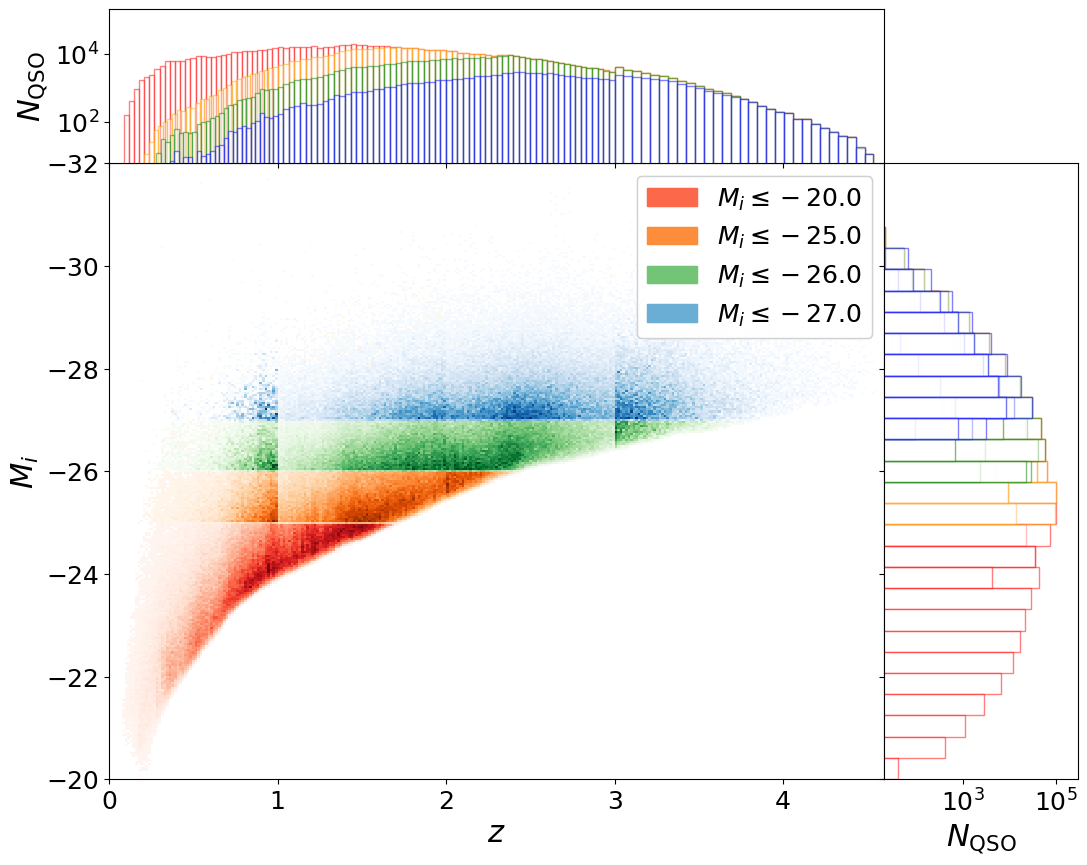

In [22]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)
fac_rand = 25

ax1 = fig.add_subplot(gs[2])
ax2 = fig.add_subplot(gs[0])
ax3 = fig.add_subplot(gs[3])

N = {L: [] for L in L_bins}

for i in range(len(L_bins)):
        
    for j in z_array:
        
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _, _, _ = quaia.make_bins(G_hi, [j, i], True, ['z', 'L'], 
                                                                                             bins = [z_bins, L_bins], tab_gcat_type = 'data', 
                                                                                              method = ['minmax', 'max'], fac_rand = fac_rand, 
                                                                                              mask = mask*100, percentile = True, n_bins = [None, None])
        quaia.absolute(tab_datahi_mask_zbin0, G_hi)
        h1, xedges, yedges, image = ax1.hist2d(tab_datahi_mask_zbin0['redshift_quaia'], tab_datahi_mask_zbin0['M_i'],
                                               cmap = plt.get_cmap('{}s'.format(colors[i])), bins = [np.linspace(0, 4.6, 300), np.linspace(-32, -20, 300)],
                                               cmin = 1)
        xlim = ax1.get_xlim()

        ax2.hist(tab_datahi_mask_zbin0['redshift_quaia'], color = 'white', edgecolor = colors[i], bins = 30, alpha = 0.5)
        ax3.hist(tab_datahi_mask_zbin0['M_i'], color = 'white', edgecolor = colors[i], orientation = 'horizontal', bins = np.linspace(-32, -20, 30), alpha = 0.5, label = '$M_i\leq{}$'.format(L_bins[i]))
        
        N[L_bins[i]].append(len(tab_datahi_mask_zbin0))
    
ax1.set_ylabel('$M_i$')
ax1.set_xlabel('$z$')
ax1.set_ylim(-20, -32)

ax2.set_ylabel('$N_\mathrm{QSO}$')
ax2.set_yscale('log')
ax2.set_xlim(xlim)
ax2.set_ylim(6,2e5)
ax2.set_xticklabels([])

ax3.set_xlabel('$N_\mathrm{QSO}$')
ax3.set_xscale('log')
ax3.set_yticklabels([])
ax3.set_ylim(-20, -32)
ax3.set_xlim(2e1,3e5)

custom_lines = [mpatches.Patch(color=plt.get_cmap('{}s'.format(colors[i]))(np.array(0.5))) for i in range(len(L_bins))]
second_legend = ax1.legend(custom_lines, ['$M_i\leq{}$'.format(L) for L in L_bins])
fig.add_artist(second_legend)

plt.show()

In [23]:
tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _, _, _ = quaia.make_bins(G_hi, 0, True, 'z', 
                                                                                             bins = [0,4.6], tab_gcat_type = 'data', fac_rand = fac_rand, 
                                                                                              mask = mask*100, percentile = True, n_bins = None)

Leaving tab_gcat_catalog unbinned
0.7218404375029477
Pixels masked by MC but not already by selfunc: 9651
G20.5: 0.28              931348 vs 1295502


In [24]:
quaia.absolute(tab_datahi_mask_zbin0, G_hi)

array([13373.67101789, 12661.44392965,  2318.42771168, ...,
       13102.99125304,  7229.02591058, 12840.07529872])

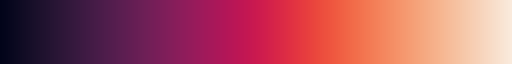

In [25]:
cmap = sns.color_palette("rocket", as_cmap=True)
cmap

In [26]:
L_array = np.array([-32, -27, -26, -25, -20])[::-1]

<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_25099/1375390511.py:29: SyntaxWarning: invalid escape sequence '\m'
  ax2_hi.set_ylabel('N$_\mathrm{QSO}$')
/tmp/ipykernel_25099/1375390511.py:37: SyntaxWarning: invalid escape sequence '\m'
  ax3_hi.set_xlabel('N$_\mathrm{QSO}$')


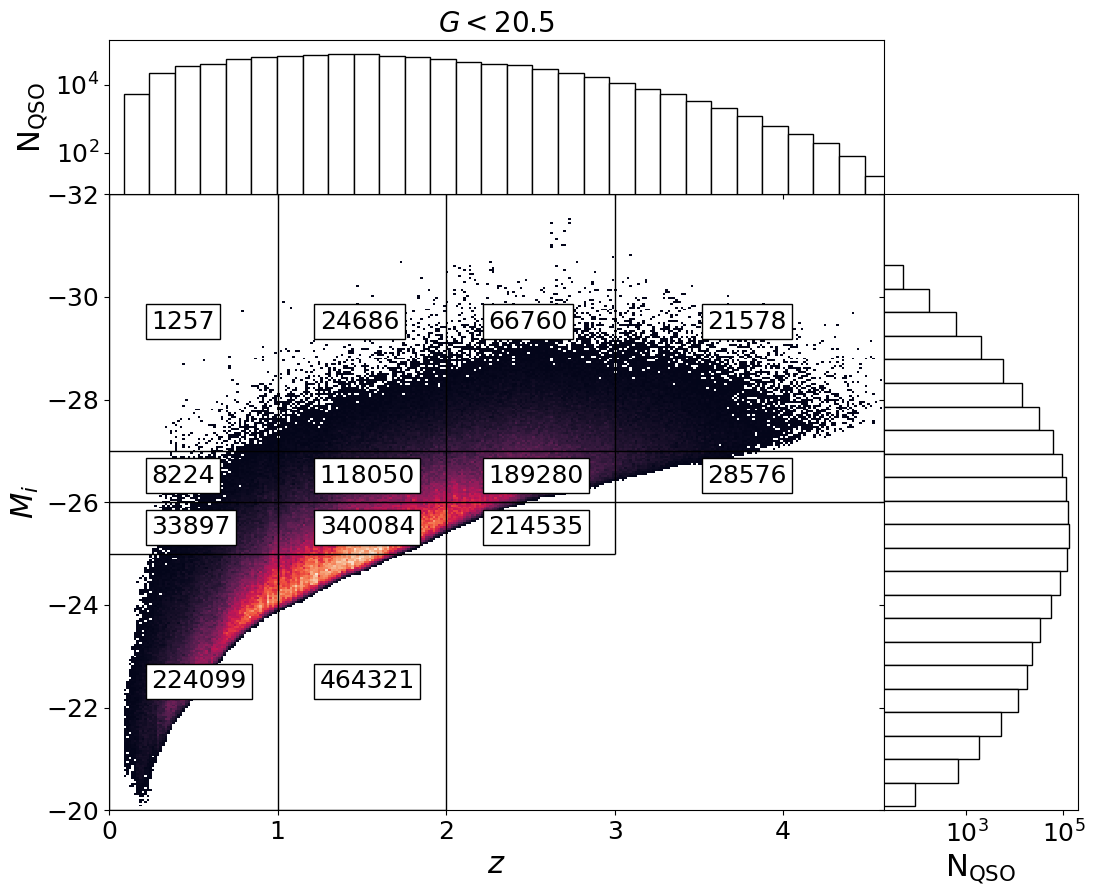

In [27]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)

ax1_hi = fig.add_subplot(gs[2])

h1, xedges, yedges, image = ax1_hi.hist2d(tab_datahi_mask_zbin0['redshift_quaia'], tab_datahi_mask_zbin0['M_i'], cmap = cmap, bins = 300, 
                                       cmin = 1)

for L_bin, xmax in zip(L_array, [z_bins[2], z_bins[3], z_bins[4], z_bins[4], z_bins[4]]):
    ax1_hi.hlines(L_bin, color = 'black', xmin = z_bins[0], xmax = xmax, linewidth = 1)
for z_bin, ymax in zip(z_bins, [L_bins[0], L_bins[0], L_bins[0], L_bins[1], L_bins[2]]):
    ax1_hi.vlines(z_bin, color = 'black', ymin = -32, ymax = ymax, linewidth = 1)
    
for i in z_array:
    for j in range(len(L_bins)):
        if ((j<3) and (N[L_bins[j]][i]>N[L_bins[j+1]][i])) or (j ==3):
            ax1_hi.text(quaia.recenter(z_bins)[i]-0.25, quaia.recenter(L_array)[j]+0.125, N[L_bins[j]][i], fontsize = 18, color = 'black', bbox=dict(facecolor='white'))
            
ax1_hi.set_ylabel('$M_i$')
xlim = ax1.get_xlim()
ax1_hi.set_xlabel('$z$')
ax1_hi.set_ylim(-20, -32)
ax1_hi.set_xlim(xlim[0], z_bins[-1])

ax2_hi = fig.add_subplot(gs[0])
ax2_hi.hist(tab_datahi_mask_zbin0['redshift_quaia'], color = 'white', edgecolor = 'black', bins = 30)
ax2_hi.set_title('$G<{}$'.format(G_hi))
ax2_hi.set_ylabel('N$_\mathrm{QSO}$')
ax2_hi.set_yscale('log')
ax2_hi.set_xlim(xlim[0], z_bins[-1])
ax2_hi.set_ylim(6,2e5)
ax2_hi.set_xticklabels([])

ax3_hi = fig.add_subplot(gs[3])
ax3_hi.hist(tab_datahi_mask_zbin0['M_i'], color = 'white', edgecolor = 'black', orientation = 'horizontal', bins = 25)
ax3_hi.set_xlabel('N$_\mathrm{QSO}$')
ax3_hi.set_xscale('log')
ax3_hi.set_yticklabels([])
ax3_hi.set_ylim(-20, -32)
ax3_hi.set_xlim(2e1,2e5)

plt.show()

# Implement halo model
## Plot HOD: $\langle N\left(M\right)\rangle=\frac{f_{\text {duty }}}{2} \operatorname{erfc}\left[\frac{\ln (M_\mathrm{min} / M)}{\sqrt{2} \log{10} \Sigma}\right]$
### At fixed $f_{duty}$ and $M_{min}$

In [28]:
n_bins = 79 #159

In [29]:
bins = np.logspace(9, M_max, n_bins)

In [30]:
M_min_array_old = [12.86, 12.74, 12.79, 12.82]
M_min_array = [11.94, 11.98, 11.97, 12.07]

In [31]:
fduty_old = [0.018, 0.022, 0.056, 0.071]
fduty = [0.002, 0.002, 0.003, 0.002]

def HOD_scatter(fduty, M_min, M, sigma):
    
    return fduty/2*special.erfc(np.log(10**M_min/M)/(np.sqrt(2)*np.log(10)*sigma))

In [32]:
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(z_array)))

<>:15: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\o'
<>:31: SyntaxWarning: invalid escape sequence '\S'
<>:15: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\o'
<>:31: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipykernel_25099/2586165201.py:15: SyntaxWarning: invalid escape sequence '\l'
  ax1.plot(bins_i, n_m, linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1), color = cmap_blue[i])
/tmp/ipykernel_25099/2586165201.py:24: SyntaxWarning: invalid escape sequence '\o'
  ax1.set_xlabel('$M (M_\odot)$')
/tmp/ipykernel_25099/2586165201.py:31: SyntaxWarning: invalid escape sequence '\S'
  ax1.set_title('$\Sigma={}$ dex'.format(sigma_array[j]))
/tmp/ipykernel_25099/480457471.py:6: RuntimeWarning: divide by zero encountered in divide
  return fduty/2*special.erfc(np.log(10**M_min/M)/(np.sqrt(2)*np.log(10)*sigma))
/tmp/ipykernel_25099/480457471.py:6: RuntimeWarning: invalid value enco

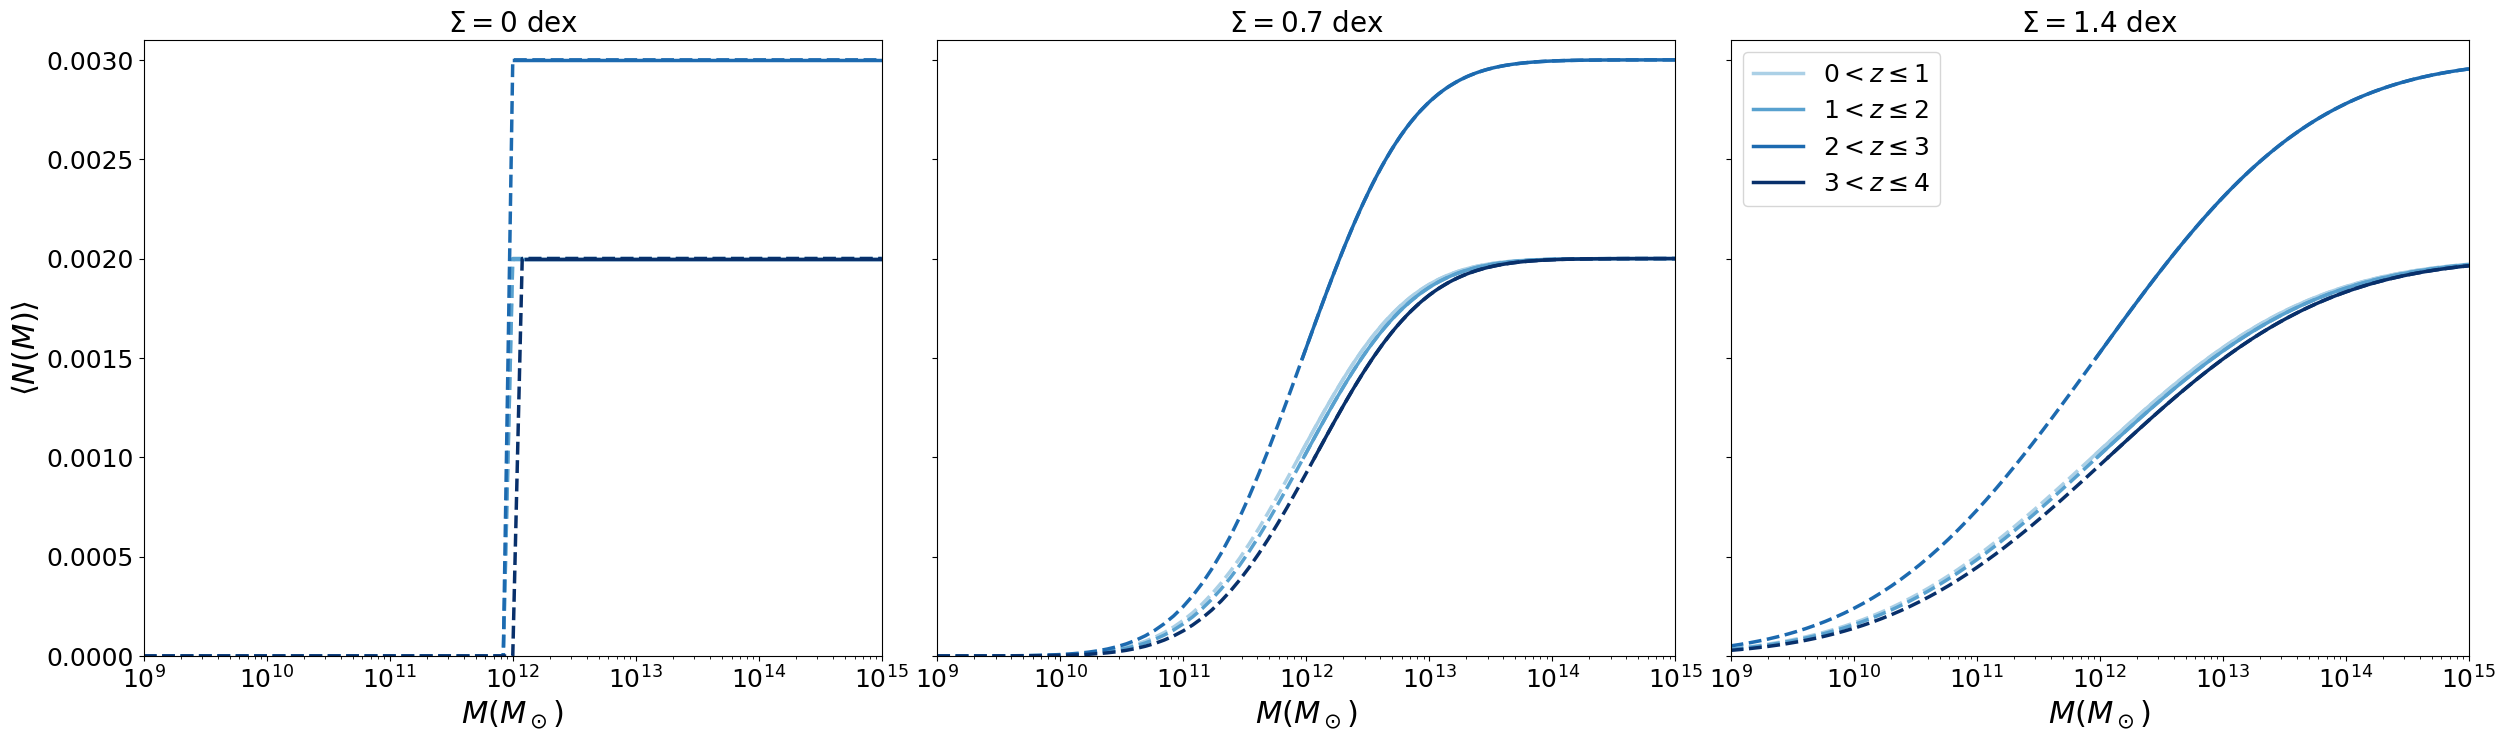

In [33]:
fig = plt.figure(figsize = (30, 8))
gs = gridspec.GridSpec(1, 3, wspace = 0.075)
sigma_array = [0, 0.7, 1.4]
n_m_array, bins_M_min = [], []

for j in range(len(sigma_array)):
    
    ax1 = fig.add_subplot(gs[j])
        
    for i in z_array:
        
        bins_i = np.logspace(M_min_array[i], M_max, n_bins)

        n_m = HOD_scatter(fduty[i], M_min_array[i], bins_i, sigma_array[j])
        ax1.plot(bins_i, n_m, linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1), color = cmap_blue[i])
        ax1.plot(bins, HOD_scatter(fduty[i], M_min_array[i], bins, sigma_array[j]), linewidth = 2.5, linestyle ='--', color = cmap_blue[i])

        if j == 0:
            
            n_m_array.append(n_m)
            bins_M_min.append(bins_i)
    
    ax1.set_xscale('log')
    ax1.set_xlabel('$M (M_\odot)$')
    
    if j== 0:
        ax1.set_ylabel(r'$\langle N(M) \rangle$')
    else:
        ax1.set_yticklabels([])
    
    ax1.set_title('$\Sigma={}$ dex'.format(sigma_array[j]))
    ax1.set_xlim(1e9,10**M_max)
    ax1.set_ylim(0, 0.0031)
    
    print()
    
ax1.legend()
plt.show()

## Step-function HOD: $\langle N(M) \rangle = \begin{cases}f_{duty} & M\geq M_{min} \\ 0 & M<M_{min}\end{cases}$

In [41]:
fduty = [0.002, 0.002, 0.003, 0.002]
n_m_array = []
for i in z_array:        
    n_m=np.zeros(np.shape(quaia.recenter(bins)))
    n_m[quaia.recenter(bins)>=10**M_min_array[i]]=fduty[i]
    n_m_array.append(n_m)

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_25099/3618045427.py:3: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(quaia.recenter(bins), n_m_array[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1))
/tmp/ipykernel_25099/3618045427.py:6: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$M (M_\odot)$')


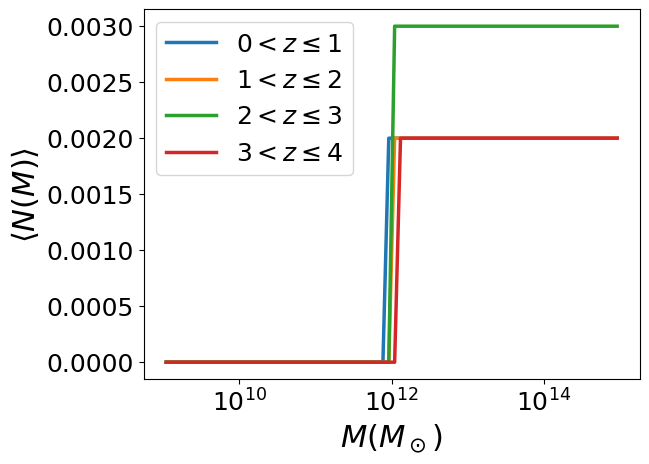

In [42]:
for i in z_array:
        
    plt.plot(quaia.recenter(bins), n_m_array[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1))

plt.xscale('log')
plt.xlabel('$M (M_\odot)$')
plt.ylabel(r'$\langle N(M) \rangle$')
plt.legend()
plt.show()

# Calculate derived parameters
## Plot b(z)

In [34]:
def b_eboss(z):
    
    return 0.278*((1+z)**2-6.565) + 2.393

def b_quaia(b_0, a, cosmo = cosmo_planck18): #quaia):
    
    return b_0/ccl.growth_factor(cosmo, a)

In [35]:
b_cf20 = np.load('../results/b_cf20_planck18.npy')
b_wp20 = np.load('../results/b_wp20_planck18.npy')

## Calculate number density as $n_q \approx \int_0^{\infty} d M \frac{d n}{d M}\langle N(M)\rangle$

In [36]:
tab_datahi_mask_zbins, selfunc_hi_bins = {L: [] for L in L_bins}, {L: [] for L in L_bins}

for i in range(len(L_bins)):
            
    for j in z_array:
        
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, selfunc_hi_bin0, _, _ = quaia.make_bins(G_hi, [j, i], True, ['z', 'L'], 
                                                                                         bins = [z_bins, L_bins], tab_gcat_type = 'data', 
                                                                                          method = ['minmax', 'max'], fac_rand = fac_rand, 
                                                                                          mask = mask*100, percentile = True, n_bins = [None, None])
        tab_datahi_mask_zbins[L_bins[i]].append(tab_datahi_mask_zbin0['redshift_quaia'])
        selfunc_hi_bins[L_bins[i]].append(selfunc_hi_bin0)

0.6894778799840835
Pixels masked by MC but not already by selfunc: 1911
G20.5_zmin0.0zmax1.0_Lmax-20.0: 0.31              224099 vs 324336
0.6998052036780241
Pixels masked by MC but not already by selfunc: 3700
G20.5_zmin1.0zmax2.0_Lmax-20.0: 0.28              464321 vs 648196
0.7010382664550974
Pixels masked by MC but not already by selfunc: 3094
G20.5_zmin2.0zmax3.0_Lmax-20.0: 0.25              214535 vs 286508
0.7686898940836221
Pixels masked by MC but not already by selfunc: 352
G20.5_zmin3.0zmax4.6_Lmax-20.0: 0.22              28576 vs 36458
0.5740493621004301
Pixels masked by MC but not already by selfunc: 472
G20.5_zmin0.0zmax1.0_Lmax-25.0: 0.39              33897 vs 55261
0.7764060682819681
Pixels masked by MC but not already by selfunc: 2269
G20.5_zmin1.0zmax2.0_Lmax-25.0: 0.32              340084 vs 502242
0.7010382664550974
Pixels masked by MC but not already by selfunc: 3094
G20.5_zmin2.0zmax3.0_Lmax-25.0: 0.25              214535 vs 286508
0.7686898940836221
Pixels masked 

## Calculate $b_{\mathrm{qq}}(s,z)=\sqrt{\frac{\xi^{(s)}_{\mathrm{qq}}(s)}{\xi^{(r)}_\mathrm{mm}(r)}-\frac{4 \Omega_{\mathrm{m}}^{1.2}(z)}{45}}-\frac{\Omega_{\mathrm{m}}^{0.6}(z)}{3}$
### Use a 50th percentile mask

In [43]:
bins_M_min_array = [np.logspace(np.log10(bins[j]), M_max, 79) for j in range(len(bins))]

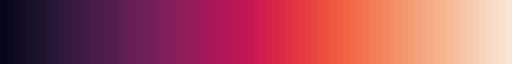

In [44]:
cmap = sns.color_palette("rocket", n_colors = len(bins))
palette = matplotlib.colors.ListedColormap(cmap)
palette

In [45]:
LMC = SkyCoord(['05 23 34.6 -69 45 22'], unit=(u.hourangle, u.deg)) #https://simbad.u-strasbg.fr/simbad/sim-id?Ident=Large+Magellanic+Cloud
LMC_radius = 9*u.deg

SMC = SkyCoord(['00 52 38.0 -72 48 01'], unit=(u.hourangle, u.deg)) # https://simbad.u-strasbg.fr/simbad/sim-id?Ident=small+Magellanic+Cloud
SMC_radius = 5*u.deg

In [46]:
NPIX = hp.nside2npix(NSIDE)

In [47]:
theta, phi = hp.pix2ang(NSIDE, range(NPIX), lonlat=True)
c = SkyCoord(ra=theta*u.degree, dec=phi*u.degree)
LMC_idx, _, _, _ = SkyCoord.search_around_sky(LMC, c, LMC_radius)
SMC_idx, _, _, _ = SkyCoord.search_around_sky(SMC, c, SMC_radius)
MC_idx = np.append(LMC_idx,SMC_idx)
MC_mask = np.full_like(range(NPIX), True, dtype = bool)
MC_mask[MC_idx] = False

In [48]:
n_q, n_q_err, V_eff, N_q = {L: [] for L in L_bins}, {L: [] for L in L_bins}, {L: [] for L in L_bins}, {L: [] for L in L_bins}

for i in range(len(L_bins)):
            
    for j in z_array:   

        N = len(tab_datahi_mask_zbins[L_bins[i]][j])
        cp = np.percentile(selfunc_hi_bins[L_bins[i]][j][MC_mask], mask*100)
        selfunc_mask = selfunc_hi_bins[L_bins[i]][j]>=cp
        f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bins[L_bins[i]][j][selfunc_mask & MC_mask]*hp.nside2pixarea(NSIDE))
        print(f_sky) # f_sky)
        V = f_sky*(Planck18.comoving_volume(z_bins[j+1])-Planck18.comoving_volume(z_bins[j]))*Planck18.h**3/u.h**3
        N_q[L_bins[i]].append(N)
        n_q[L_bins[i]].append(N/V.value)
        n_q_err[L_bins[i]].append(np.sqrt(N)/V.value) # Poisson error
        V_eff[L_bins[i]].append(V)

0.38155534002874686
0.39902663869548327
0.425675678284438
0.43715916212910605
0.30783729668267806
0.4016732094561275
0.425675678284438
0.43715916212910605
0.3069965681098881
0.2992550895295538
0.4479753910659304
0.43715916212910605
0.2866646622570881
0.25973106916164884
0.4057358011299892
0.4852780945924453


In [49]:
fduty_err_hi = 0.002, 0.001, 0.008, 0.077
fduty_err_lo = 0.002, 0.001, 0.007, 0.034

In [50]:
def n_q_theory_err(n_dm, fduty_err, M_min, a, M_min_err, hmf = hmf, cosmo = cosmo_planck18): #quaia):
    
    nm = hmf(cosmo, bins, a)/cosmo['h']**3 # convert to h/Mpc**3
    dn_dm = nm/(bins*np.log(10))
    
    return np.sqrt(n_dm**2*fduty_err**2+(fduty_err*hmf(cosmo, 10**M_min, a))**2*M_min_err**2)

## Limit scales to $30\geq s \geq 80h^{-1}$ Mpc

In [51]:
# Create the bins array
rmin = 30 #-delta_min*offset # 0.1 # start higher # 1.4 # 30
rmax = 80 #+delta_max*offset # 200
nbins = 10 #20 + int(delta_min+delta_max) #90 #20
rbins_chi2 = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'linear'
rbins_chi2, quaia.recenter(rbins_chi2), np.diff(quaia.recenter(rbins_chi2))

(array([30., 35., 40., 45., 50., 55., 60., 65., 70., 75., 80.]),
 array([32.5, 37.5, 42.5, 47.5, 52.5, 57.5, 62.5, 67.5, 72.5, 77.5]),
 array([5., 5., 5., 5., 5., 5., 5., 5., 5.]))

In [52]:
pimax = 80 # 40 # 5000.0 # 40.0\

In [53]:
dpi = 0.01
pibins = np.arange(0, pimax+1, dpi)

In [54]:
wp_chi2, wp_matter_chi2, rpavg_chi2 = {L: [] for L in L_bins}, {L: [] for L in L_bins}, {L: [] for L in L_bins}
b_wp_chi2 = {L: [] for L in L_bins}
a_zbin, b_wp_q = {L: [] for L in L_bins}, {L: [] for L in L_bins}
rpmask = {L: [] for L in L_bins}
H0 = Planck18.H0 # cosmo_planck18['H0'] * u.km/u.s/u.Mpc
    
for i in range(len(L_bins)):
            
    for j in z_array:
        
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _, _, selfunc_hi_bin0, = quaia.make_bins(G_hi, [j, i], True, ['z', 'L'], 
                                                                                         bins = [z_bins, L_bins], tab_gcat_type = 'data', 
                                                                                          method = ['minmax', 'max'], fac_rand = fac_rand, 
                                                                                          mask = mask*100, percentile = True, n_bins = [None, None])
    
        # quasar correlation function
        wp_zbin_i, rpavg_zbin_i = quaia.wp_rp(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
                                                                      rbins = rbins_chi2, nbins = nbins, pimax = pimax, Om0 = Planck18.Om0, h = Planck18.h)
        wp_chi2[L_bins[i]].append(wp_zbin_i)
        rpavg_chi2[L_bins[i]].append(rpavg_zbin_i)
    
        # scale factor
        a = a_median(tab_datahi_mask_zbin0)
        a_zbin[L_bins[i]].append(a)
    
        # matter correlation function   
        s = np.sqrt(np.sum(np.meshgrid(np.array(rpavg_zbin_i)**2, quaia.recenter(pibins)**2), axis = 0))
        s_Mpc = (s*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))
            
        xirppi_zbin_i = ccl.correlations.correlation_3d(cosmo_planck18, r=np.ravel(s_Mpc), a=a_median(tab_datahi_mask_zbin0))
        wp_matter_zbin_i = 2*np.trapz(np.reshape(xirppi_zbin_i, np.shape(s_Mpc)), quaia.recenter(pibins), axis = 0)
        wp_matter_chi2[L_bins[i]].append(wp_matter_zbin_i)        
    
        # effective bias 
        b = np.sqrt(wp_zbin_i/wp_matter_zbin_i)
        b_wp_chi2[L_bins[i]].append(b)
    
        # qso bias
        b_wp_q[L_bins[i]].append(b_qso(wp_zbin_i, wp_matter_zbin_i, ccl.growth_rate(cosmo_planck18, a)))
        
        rpmask[L_bins[i]].append((np.array(rpavg_zbin_i) >= 30) & (np.array(rpavg_zbin_i) <= 80))

0.6894778799840835
Pixels masked by MC but not already by selfunc: 1911
G20.5_zmin0.0zmax1.0_Lmax-20.0: 0.31              224099 vs 324336


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


0.6998052036780241
Pixels masked by MC but not already by selfunc: 3700
G20.5_zmin1.0zmax2.0_Lmax-20.0: 0.28              464321 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_25099/2770415617.py:35: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(wp_zbin_i/wp_matter_zbin_i)
/tmp/ipykernel_25099/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


0.7010382664550974
Pixels masked by MC but not already by selfunc: 3094
G20.5_zmin2.0zmax3.0_Lmax-20.0: 0.25              214535 vs 286508


...

/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


0.7825058063308259
Pixels masked by MC but not already by selfunc: 1036
G20.5_zmin2.0zmax3.0_Lmax-27.0: 0.35              66760 vs 103123


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


0.9260170066053528
Pixels masked by MC but not already by selfunc: 278
G20.5_zmin3.0zmax4.6_Lmax-27.0: 0.26              21578 vs 28981


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_25099/2770415617.py:35: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(wp_zbin_i/wp_matter_zbin_i)
/tmp/ipykernel_25099/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


## Compute the maximum number of jackknife regions

In [55]:
N_j = 50

In [56]:
fudge = 2.8
for i in range(len(L_bins)):
            
    for j in z_array: 

        # # calculating N_jk first
        # s_min = Planck18.comoving_transverse_distance(1/a_zbin[L_bins[i]][j]-1)*2*np.pi*Planck18.h/u.h
        # N_jk_max = np.floor(s_min/(2.8*rmax*s_min.unit))
        # theta_min = np.ceil(360/N_jk_max)
        
        # calculating theta first
        # s_min = Planck18.comoving_distance(1/a_zbin[j]-1)*Planck18.h/u.h
        # theta_min = np.ceil(np.rad2deg(rmax*s_min.unit/s_min*u.rad))
        # N_jk_max = np.floor(360*u.deg/theta_min)

        r_LOS = Planck18.comoving_distance(1/a_zbin[L_bins[i]][j]-1)*Planck18.h/u.h
        theta_min = 2*np.arcsin(fudge*rmax*r_LOS.unit/2/r_LOS)
        N_jk_max = np.floor(2*np.pi*theta_min.unit/theta_min)
        
        print('N_j_max:', N_jk_max)
        print('N_q:', int(N_q[L_bins[i]][j]*(N_j-1)/N_j))
        print('theta_min:', np.ceil(theta_min))
        print()
    
print('hartlap:', (N_j-nbins-2)/(N_j-1))
print('dodelson:', 1+nbins/N_j)

N_j_max: 50.0
N_q: 219617
theta_min: 1.0 rad

N_j_max: 84.0
N_q: 455034
theta_min: 1.0 rad

N_j_max: 110.0
N_q: 210244
theta_min: 1.0 rad

N_j_max: 127.0
N_q: 28004
theta_min: 1.0 rad

N_j_max: 57.0
N_q: 33219
theta_min: 1.0 rad

N_j_max: 88.0
N_q: 333282
theta_min: 1.0 rad

N_j_max: 110.0
N_q: 210244
theta_min: 1.0 rad

N_j_max: 127.0
N_q: 28004
theta_min: 1.0 rad

N_j_max: 58.0
N_q: 8059
theta_min: 1.0 rad

N_j_max: 90.0
N_q: 115689
theta_min: 1.0 rad

N_j_max: 111.0
N_q: 185494
theta_min: 1.0 rad

N_j_max: 127.0
N_q: 28004
theta_min: 1.0 rad

N_j_max: 58.0
N_q: 1231
theta_min: 1.0 rad

N_j_max: 92.0
N_q: 24192
theta_min: 1.0 rad

N_j_max: 113.0
N_q: 65424
theta_min: 1.0 rad

N_j_max: 128.0
N_q: 21146
theta_min: 1.0 rad

hartlap: 0.7755102040816326
dodelson: 1.2


## Pick cosmology

In [57]:
cosmo = 'Planck'

In [58]:
N = 50 #20 #65 #50 #30 #15 #80

In [59]:
offset = 0.3

In [60]:
rpmin = np.min([rpavg_chi2[L] for L in L_bins])
rpmax = np.max([rpavg_chi2[L] for L in L_bins])

In [61]:
rbins_offset = np.linspace(rmin-0.05, rmax+0.95, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'linear'
quaia.recenter(rbins_offset), quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1]+offset*3

(array([32.5, 37.6, 42.7, 47.8, 52.9, 58. , 63.1, 68.2, 73.3, 78.4]),
 32.5,
 78.4)

<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_25099/3289806877.py:17: SyntaxWarning: invalid escape sequence '\l'
  ax1.errorbar(np.array(rpavg_chi2[L_bins[j]][i])+offset*j, wp_chi2[L_bins[j]][i], marker = 'o', label = '$M_i\leq{}$'.format(L_bins[j]), markeredgewidth = 2.5, capsize = 2.5,
/tmp/ipykernel_25099/3289806877.py:25: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]))


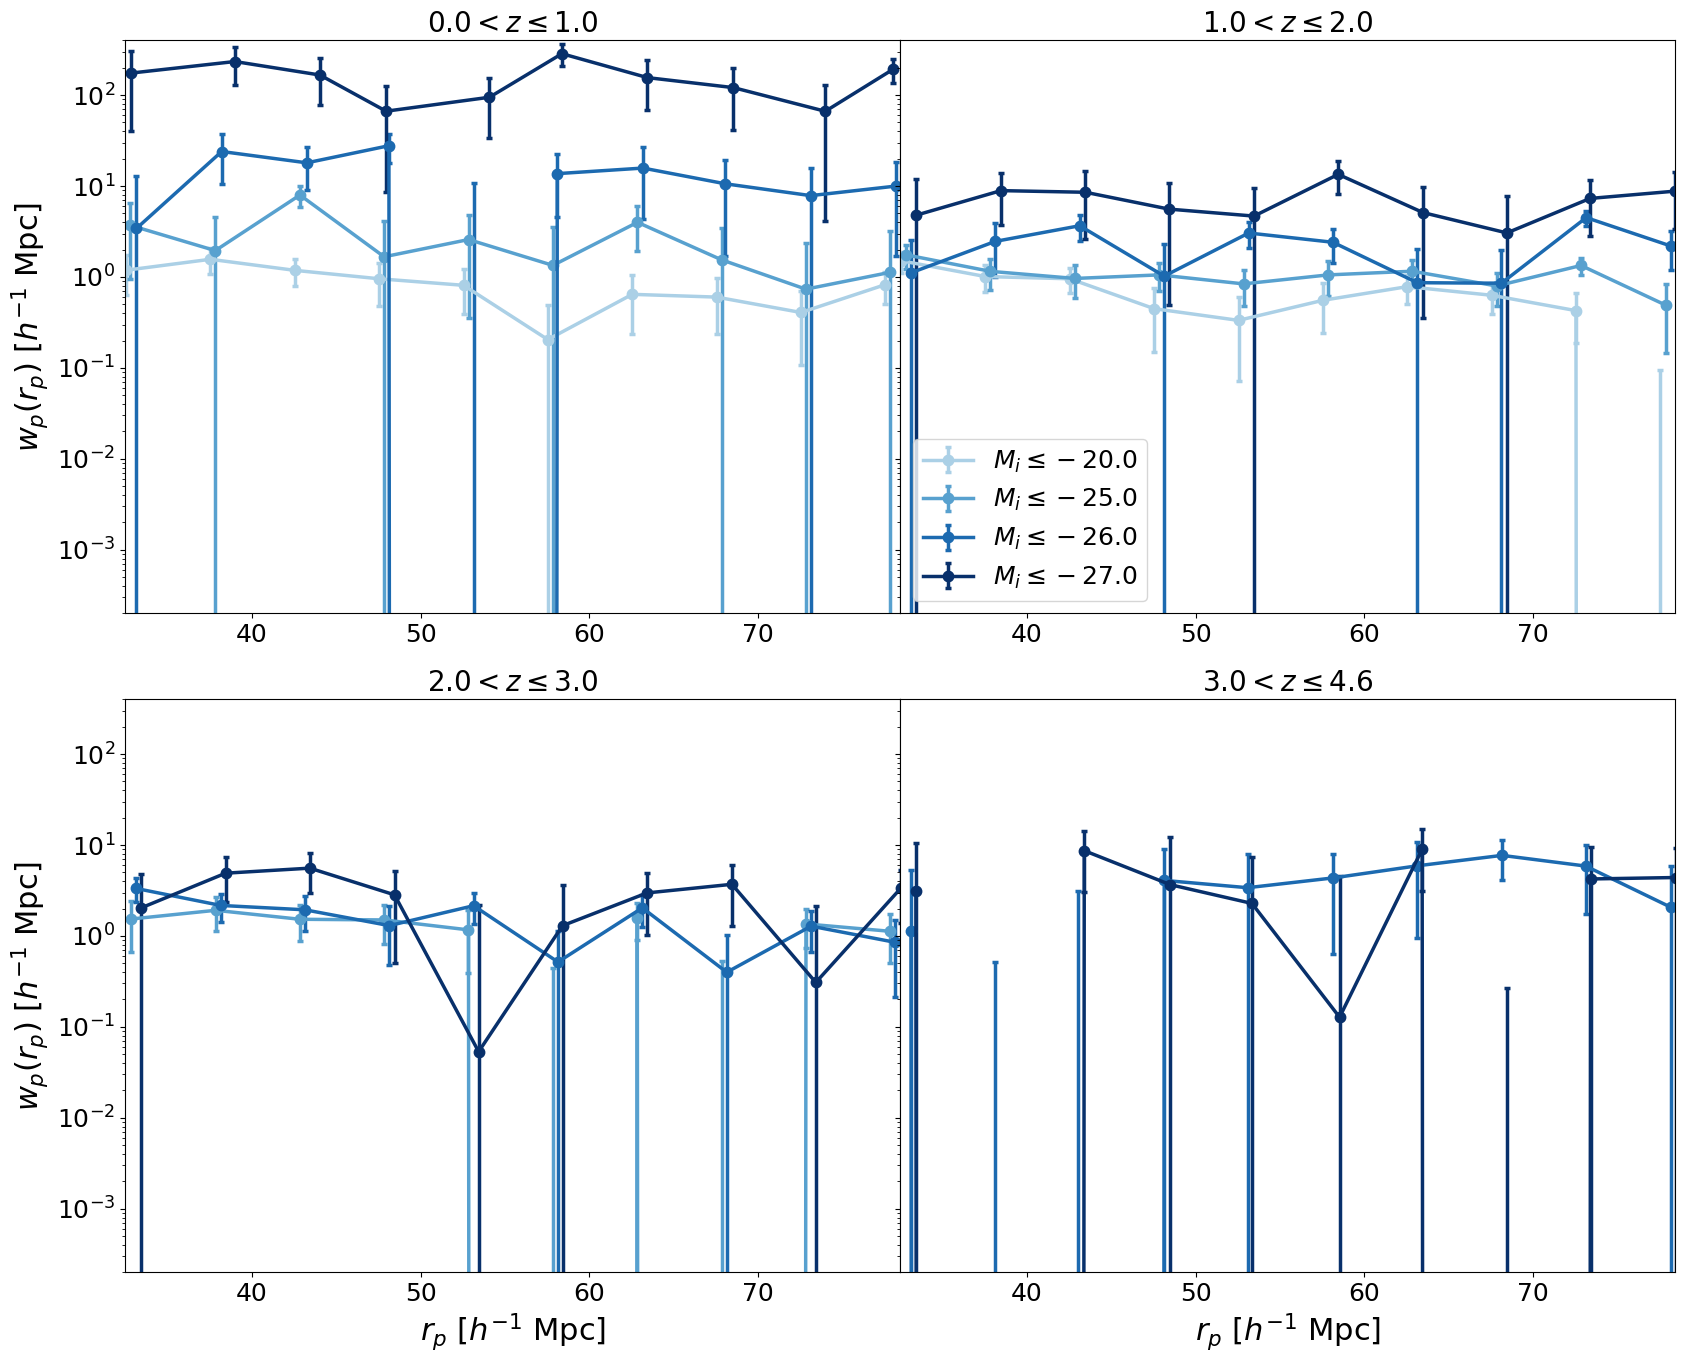

In [62]:
# plot!
r = quaia.recenter(rbins_offset) #_chi2)
ylim = 2e-4, 4e2

fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.15)

for i in range(len(z_array)):

    ax1 = fig.add_subplot(gs[i])

    for j in range(len(L_bins)):

        if ((j<3) and (N_q[L_bins[j]][i]>N_q[L_bins[j+1]][i])) or (j==3):

            sigma = np.sqrt(np.diag(np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[i], z_bins[i+1], L_bins[j], N, cosmo))))
            ax1.errorbar(np.array(rpavg_chi2[L_bins[j]][i])+offset*j, wp_chi2[L_bins[j]][i], marker = 'o', label = '$M_i\leq{}$'.format(L_bins[j]), markeredgewidth = 2.5, capsize = 2.5,
                     linewidth = 2.5, color = cmap_blue[j], yerr = sigma) #np.sqrt(np.diag(C[zbin])))
    if i>1:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(r[0], r[-1])
    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]))
    if i%2!=0:
        ax1.set_yticklabels([])
    else:
        ax1.set_ylabel(r"$w_p(r_p)$ $[h^{-1}$ Mpc]")
    ax1.set_ylim(ylim)

    if i ==1:
        ax1.legend()
plt.show()

<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_25099/1075593654.py:13: SyntaxWarning: invalid escape sequence '\l'
  ax1.errorbar(np.array(rpavg_chi2[L_bins[j]][i])+offset*i, wp_chi2[L_bins[j]][i], marker = 'o', label = '${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]), markeredgewidth = 2.5, capsize = 2.5,
/tmp/ipykernel_25099/1075593654.py:25: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$M_i\leq{}$'.format(L_bins[j]))


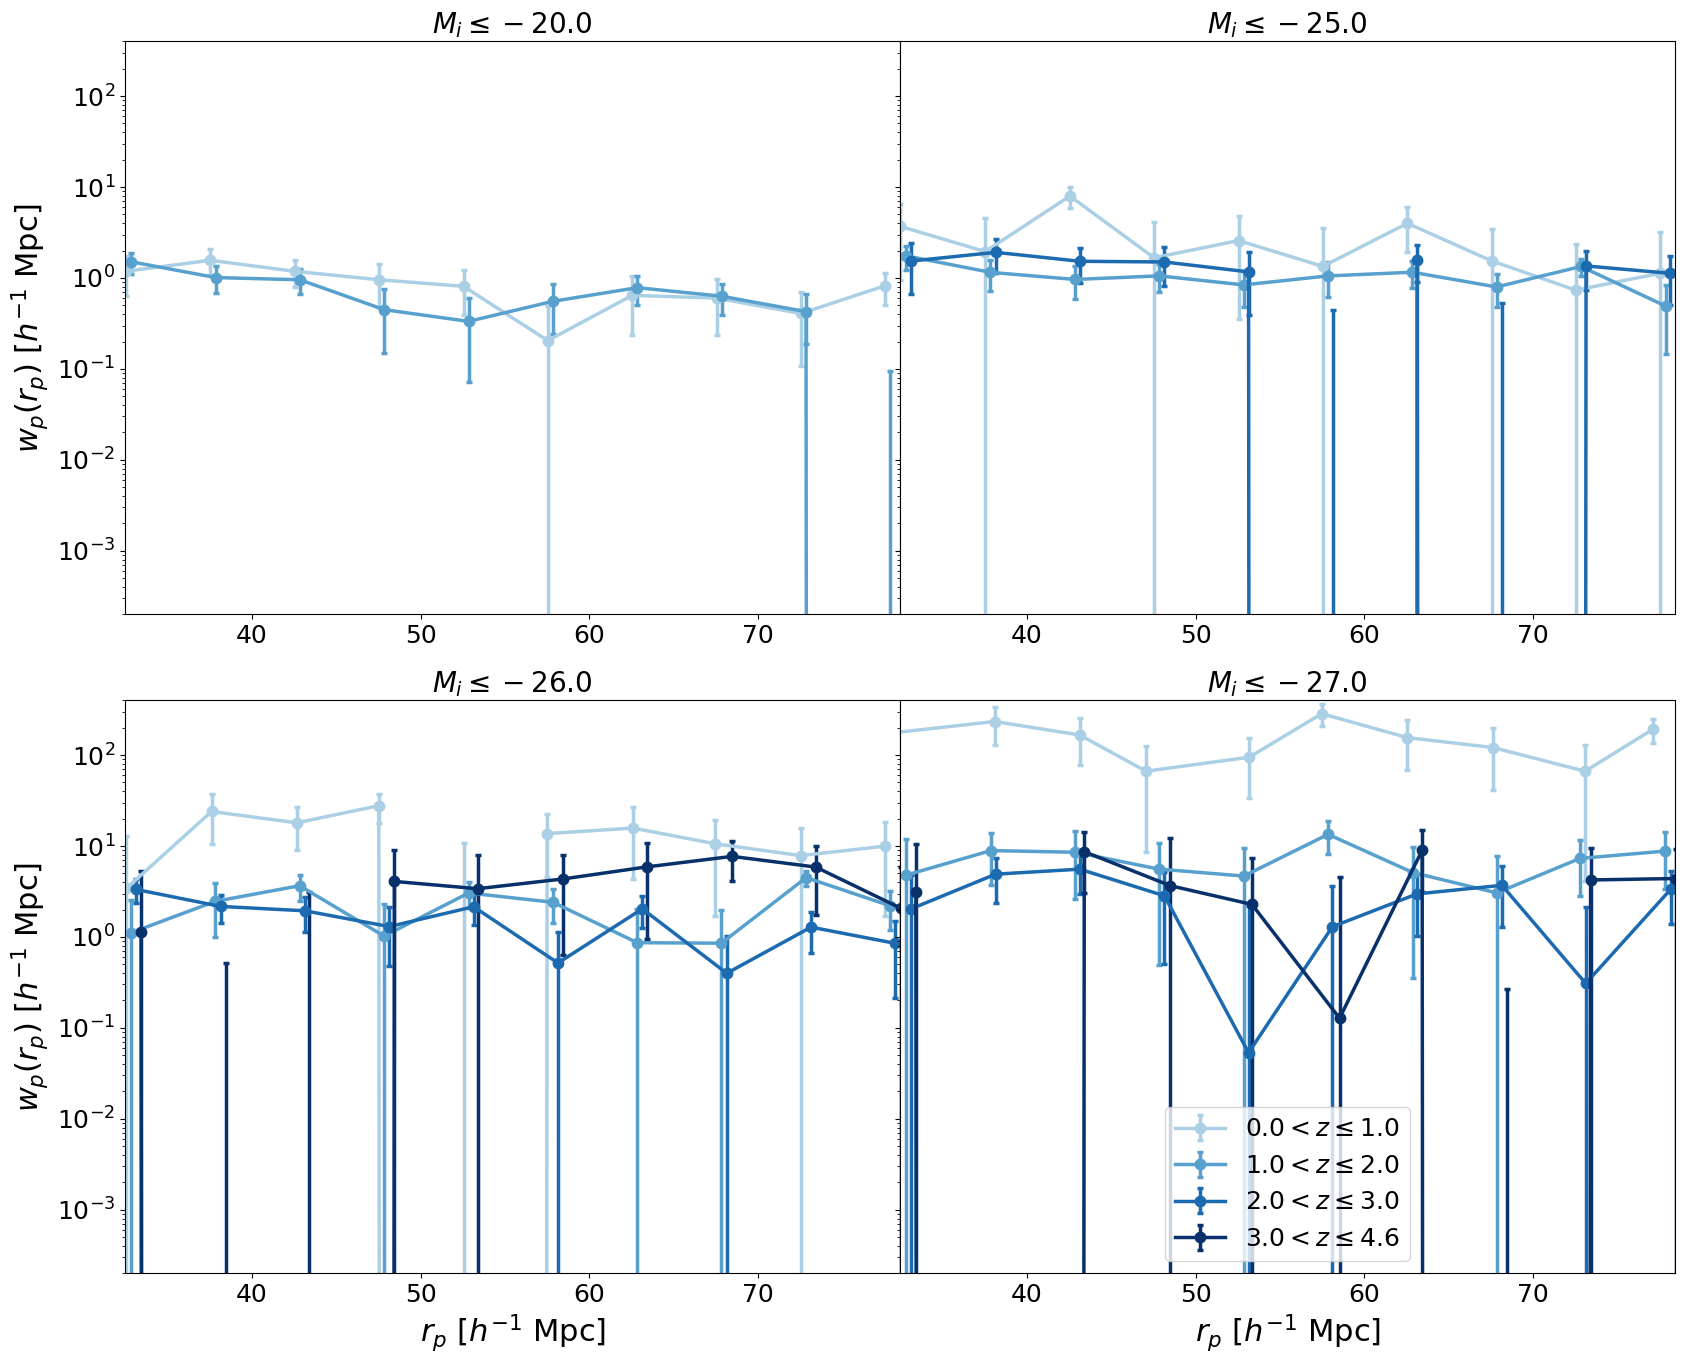

In [63]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.15)

for j in range(len(L_bins)):

    ax1 = fig.add_subplot(gs[j])

    for i in range(len(z_array)):

        if ((j<3) and (N_q[L_bins[j]][i]>N_q[L_bins[j+1]][i])) or (j==3):

            sigma = np.sqrt(np.diag(np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[i], z_bins[i+1], L_bins[j], N, cosmo))))
            ax1.errorbar(np.array(rpavg_chi2[L_bins[j]][i])+offset*i, wp_chi2[L_bins[j]][i], marker = 'o', label = '${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]), markeredgewidth = 2.5, capsize = 2.5,
                     linewidth = 2.5, color = cmap_blue[i], yerr = sigma) #np.sqrt(np.diag(C[zbin])))
        if j>1:
            ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(r[0], r[-1])
        if j%2!=0:
            ax1.set_yticklabels([])
        else:
            ax1.set_ylabel(r"$w_p(r_p)$ $[h^{-1}$ Mpc]")
        ax1.set_title('$M_i\leq{}$'.format(L_bins[j]))
        ax1.set_ylim(ylim)

ax1.legend()
plt.show()

<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_25099/1800520145.py:16: SyntaxWarning: invalid escape sequence '\l'
  ax1.errorbar(rpavg_chi2[L_bins[j]][i], wp_chi2[L_bins[j]][i], marker = 'o', label = '${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]), markeredgewidth = 2.5, capsize = 2.5,
/tmp/ipykernel_25099/1800520145.py:20: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$M_i\leq{}$'.format(L_bins[j]))


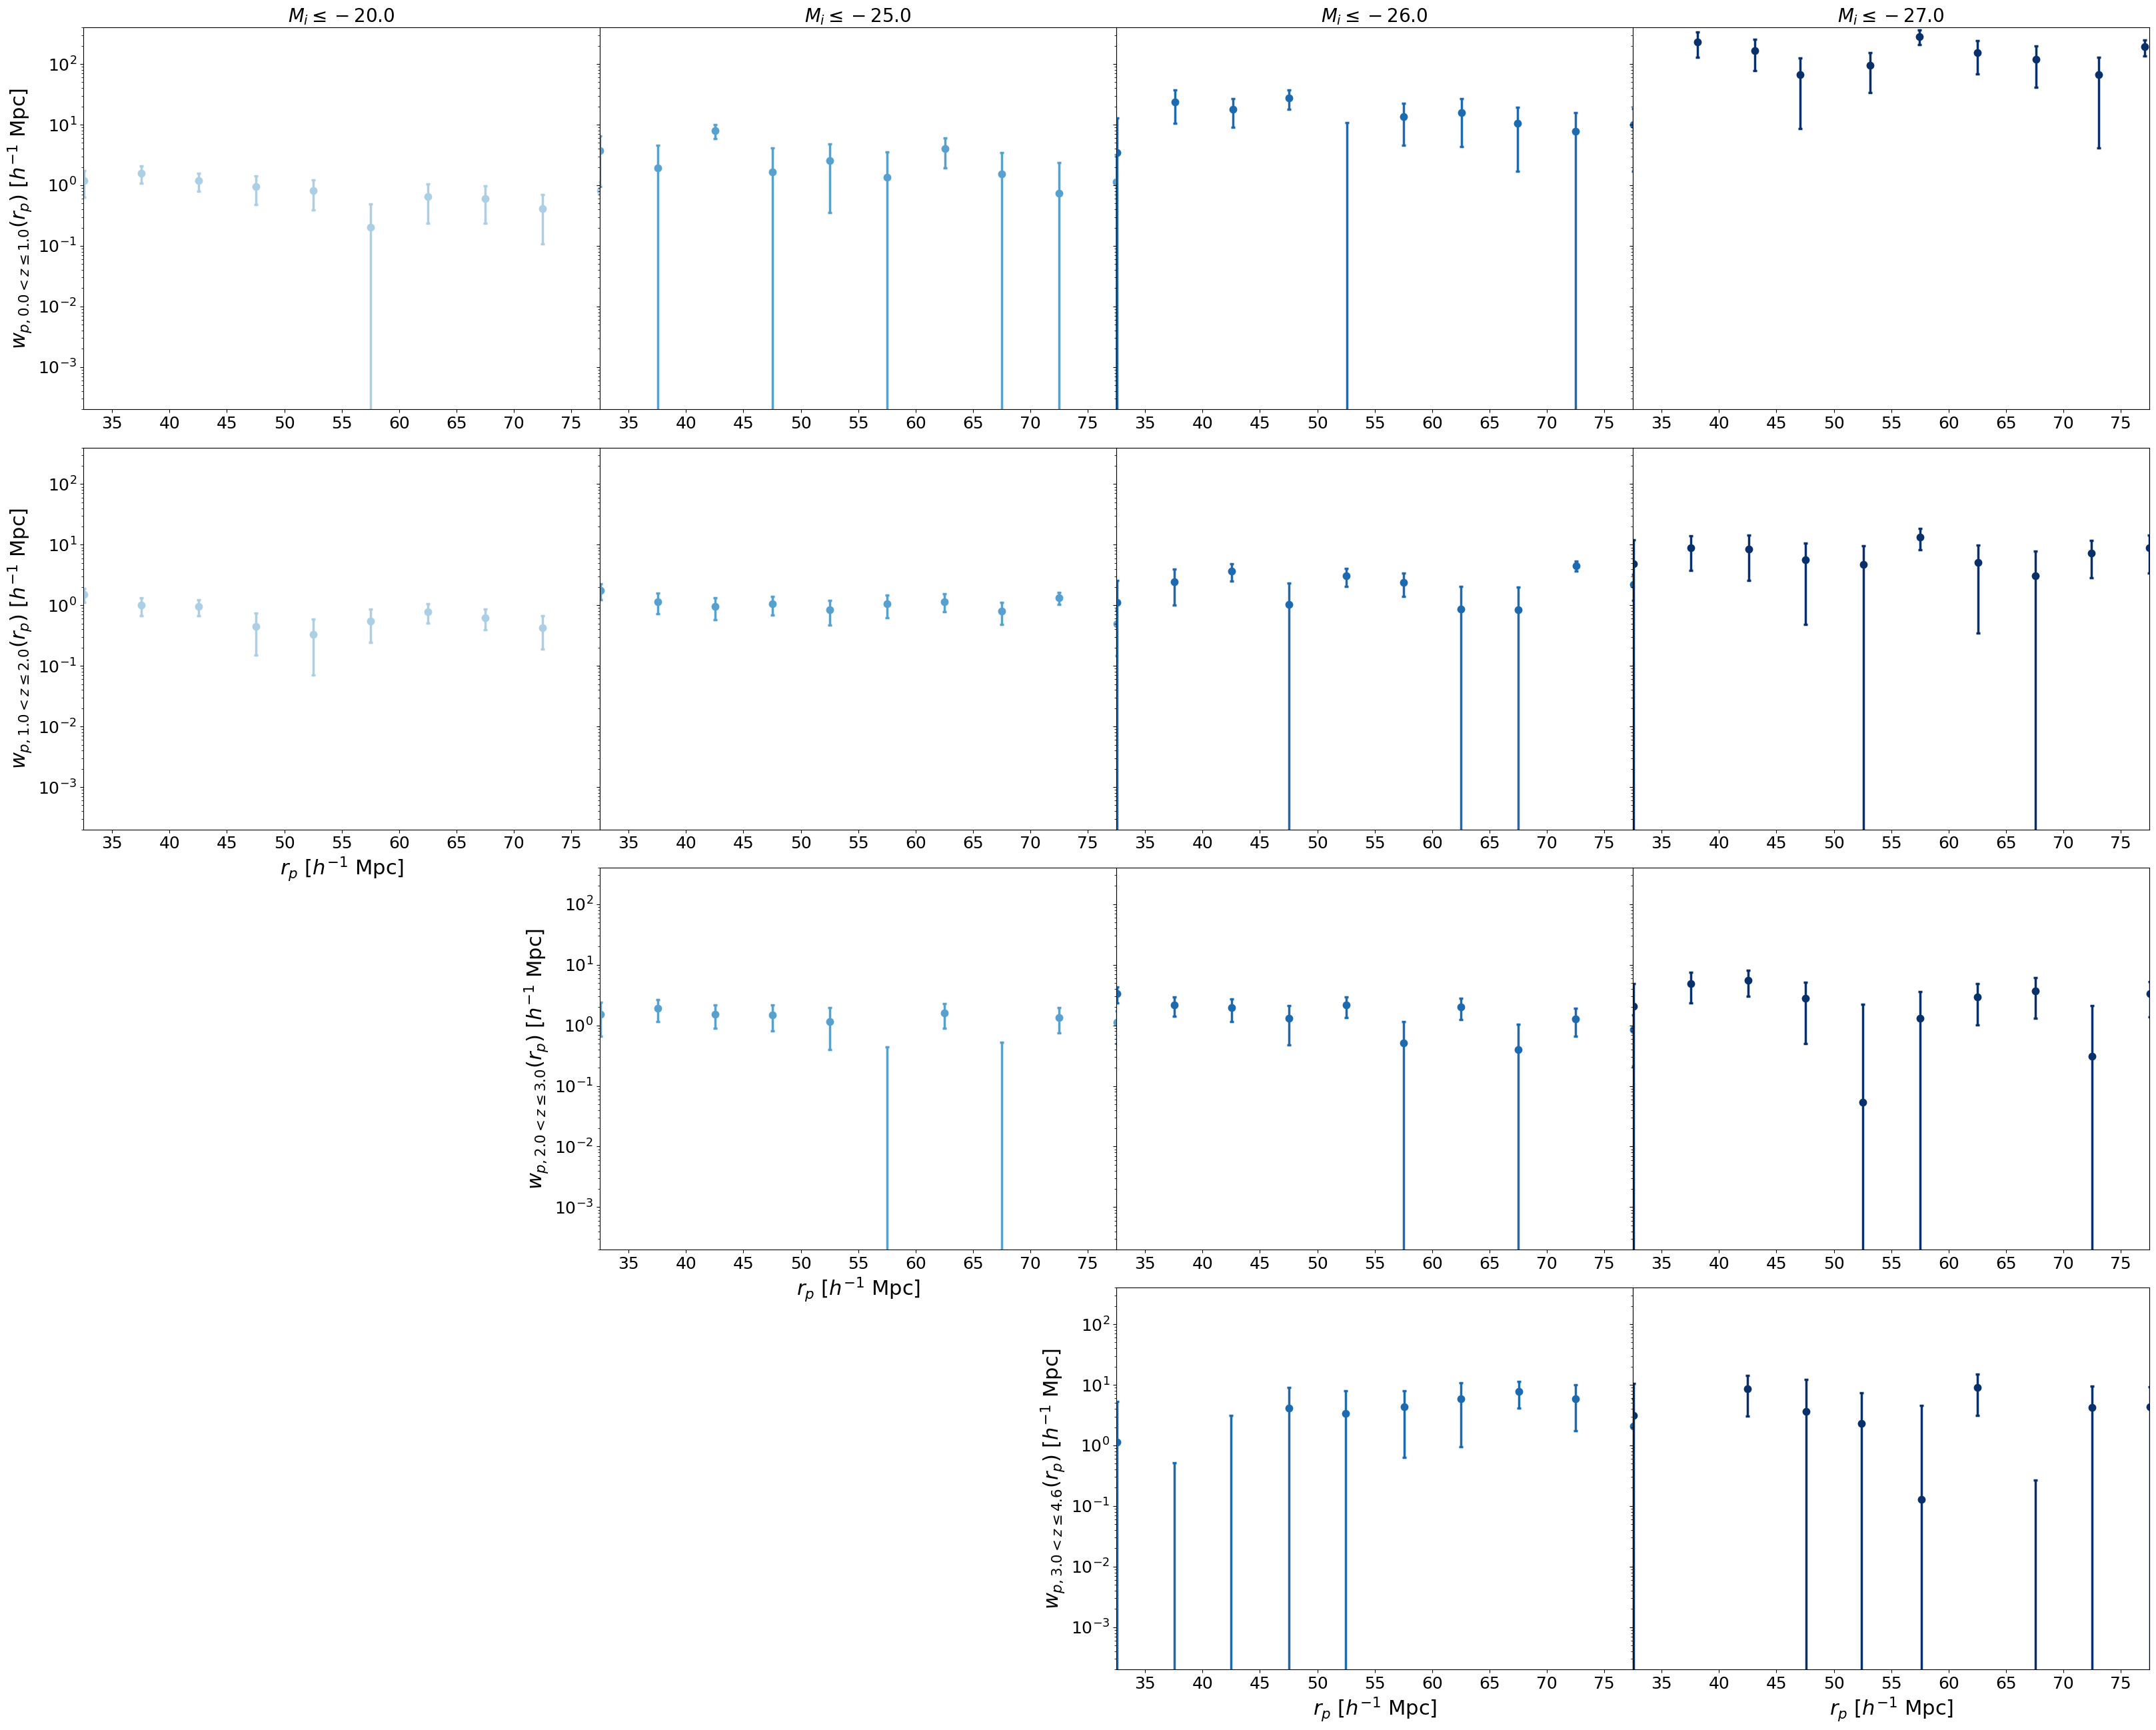

In [64]:
# plot!
r = quaia.recenter(rbins_chi2) #_chi2)

fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0.1)

for i in range(len(z_array)):
    
    for j in range(len(L_bins)):
    
        if ((j<3) and (N_q[L_bins[j]][i]>N_q[L_bins[j+1]][i])) or (j==3):

            ax1 = fig.add_subplot(gs[i*4+j])

            sigma = np.sqrt(np.diag(np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[i], z_bins[i+1], L_bins[j], N, cosmo))))
            ax1.errorbar(rpavg_chi2[L_bins[j]][i], wp_chi2[L_bins[j]][i], marker = 'o', label = '${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]), markeredgewidth = 2.5, capsize = 2.5,
                     linewidth = 2.5, color = cmap_blue[j], yerr = sigma, linestyle = 'None')

            if i ==0:
                ax1.set_title('$M_i\leq{}$'.format(L_bins[j]))
            if scale == 'log':
                ax1.set_xscale('log')
            ax1.set_yscale('log')
            ax1.set_xlim(r[0], r[-1])
            ax1.set_ylim(ylim)
            if i > 2 or ((i>0) and (j <2) and (i!=j)):
                ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
            if j==0 or ((i>1) and (j <3) and (i!=j)):
                ax1.set_ylabel(r"$w_{{p,{:.1f}<z \leq{:.1f}}}(r_p)$ $[h^{{-1}}$ Mpc]".format(z_bins[i], z_bins[i+1]))
            else:
                ax1.set_yticklabels([])


plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_25099/3995958243.py:14: SyntaxWarning: invalid escape sequence '\l'
  ax1.errorbar(rpavg_chi2[L_bins[j]][i], wp_chi2[L_bins[j]][i], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(z_bins[i], z_bins[i+1]), markeredgewidth = 2.5, capsize = 2.5,
/tmp/ipykernel_25099/3995958243.py:18: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]))


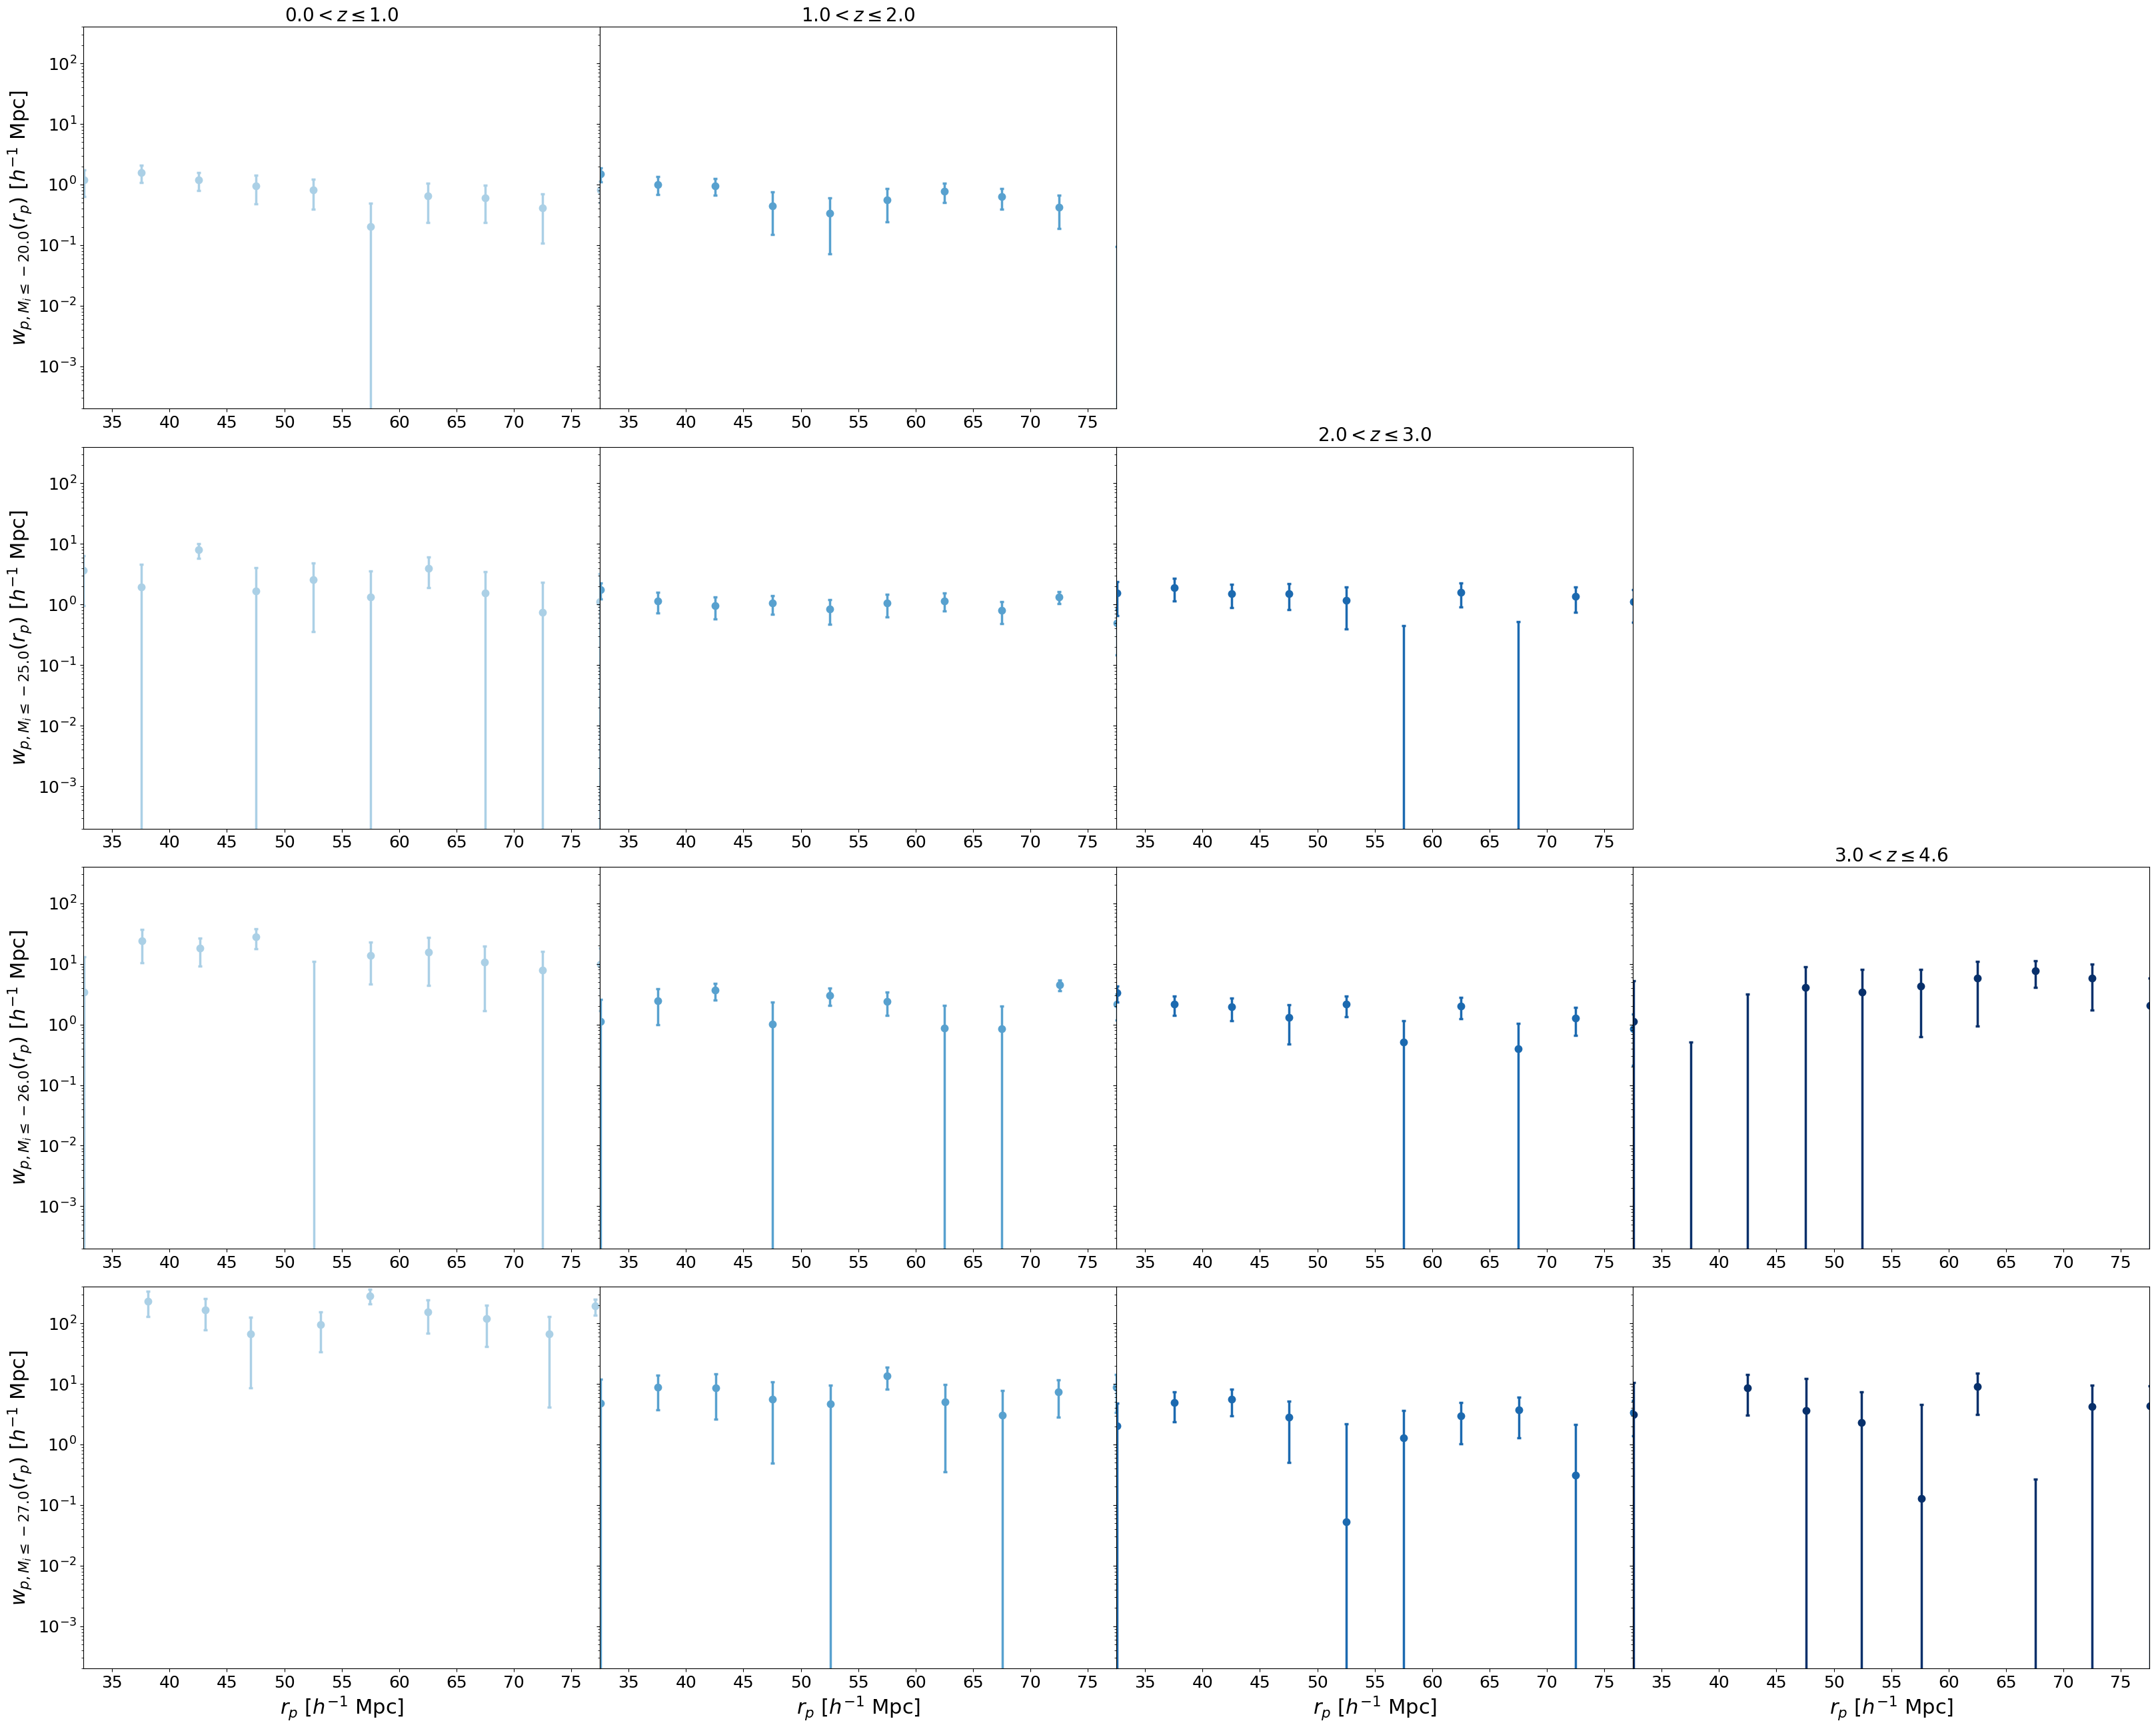

In [65]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0.1)

for j in range(len(L_bins)):

    for i in range(len(z_array)):

        if ((j<3) and (N_q[L_bins[j]][i]>N_q[L_bins[j+1]][i])) or (j==3):

            ax1 = fig.add_subplot(gs[j*4+i])
    
            sigma = np.sqrt(np.diag(np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[i], z_bins[i+1], L_bins[j], N, cosmo))))
            ax1.errorbar(rpavg_chi2[L_bins[j]][i], wp_chi2[L_bins[j]][i], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(z_bins[i], z_bins[i+1]), markeredgewidth = 2.5, capsize = 2.5,
                     linewidth = 2.5, color = cmap_blue[i], yerr = sigma, linestyle = 'None')
    
            if j ==0 or ((j<3) and (i>1) and (i!=j)):
                ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]))
            if scale == 'log':
                ax1.set_xscale('log')
            ax1.set_yscale('log')
            ax1.set_xlim(r[0], r[-1])
            ax1.set_ylim(ylim)
            if j > 2:
                ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
            if i==0:
                ax1.set_ylabel(r"$w_{{p,M_i\leq{}}}(r_p)$ $[h^{{-1}}$ Mpc]".format(L_bins[j]))
            else:
                ax1.set_yticklabels([])

plt.show()

# Perform nested sampling with dynesty

In [66]:
# Define the dimensionality of our problem.
ndim = 3

In [67]:
def wp_2h(bins, n_m, a, cosmo, wp_matter_zbin_i, rpbins = rbins_chi2, pibins = pibins, recenter = True, rpmask = True):

    if not isinstance(wp_matter_zbin_i, np.ndarray):
        
        print('computing wp_matter')
        
        # matter correlation function    
        if isinstance(rpmask, bool):
            rpmask = [rpmask]*len(quaia.recenter(rpbins))
            
        s = np.sqrt(np.sum(np.meshgrid(quaia.recenter(rpbins)[rpmask]**2, quaia.recenter(pibins)**2), axis = 0))
        s_Mpc = (s*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(cosmo['h']* 100 * u.km/u.s/u.Mpc))

        xirppi_zbin_i = ccl.correlations.correlation_3d(cosmo, r=np.ravel(s_Mpc), a=a)
        wp_matter_zbin_i = 2*np.trapz(np.reshape(xirppi_zbin_i, np.shape(s_Mpc)), quaia.recenter(pibins), axis = 0)

    return cf_2h(bins, n_m, a, cosmo, wp_matter_zbin_i, recenter = recenter)

In [68]:
nlive = 3000
dlogz = 0.001

In [68]:
# Define our 3-D correlated multivariate normal log-likelihood.
C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[i], z_bins[i+1], L_bins[j], N, cosmo))
ix_grid = np.ix_(rpmask[L_bins[j]][i], rpmask[L_bins[j]][i])
hartlap = (N-nbins-2)/(N-1)
print(hartlap)

# check if cov is hermitian and positive definite
if linalg.ishermitian(C) and np.all(np.linalg.eigvals(C) > 0):
    C_factor = linalg.cho_factor(C[ix_grid])
    log_det_C = 2 * np.sum(np.log(np.diag(C_factor[0])))
    solve = lambda rhs: linalg.cho_solve(C_factor, rhs)
else:
    print('using LU decomposition')
    C_factor = linalg.lu_factor(C[ix_grid])
    log_det_C = np.sum(np.log(np.abs(np.diag(C_factor[0])))) # does abs value make sense
    solve = lambda rhs: linalg.lu_solve(C_factor, rhs)
    
def loglike(x, a, wp_matter, log_det_C, wp, n_q, nbins, solve, rpbins = rbins_chi2, pibins = pibins, cosmo = cosmo_planck18, error = 0.05, M_max = M_max, N = N):
    
    # fduty, M_min = x
    
    # bins_m = np.logspace(M_min, M_max, 79)
    # n_m=np.ones(np.shape(bins_m))*10**fduty

    fduty, M_min, sigma = x
    n_m=HOD_scatter(10**fduty, M_min, bins, sigma)
        
    n_q_theory = M(bins, n_m, a = a, cosmo = cosmo, recenter = False)[1]
    # penalty = np.abs(n_q_theory-n_q)/n_q
    # if penalty > error:
    #     return -np.inf
    penalty = 0.5*((n_q_theory-n_q)/(error*n_q))**2
        
    wp_2h_zbin, _ = wp_2h(bins, n_m, a, cosmo, wp_matter, rpbins = rpbins, pibins = pibins, recenter = False)
    delta = wp-wp_2h_zbin
    
    c_p = gamma(N/2)/((np.pi*(N-1))**(nbins/2)*gamma((N-nbins)/2))
    lnorm = np.log(c_p)-0.5*log_det_C  
    
    return -N*0.5 * np.log(1+(delta.T @ solve(delta))/(N-1)) + lnorm - penalty

0.7755102040816326


In [69]:
def ptform(u):
    """Transforms the uniform random variables `u ~ Unif[0., 1.)`
    to the parameters of interest."""

    x = np.array(u)  # copy u 

    # Uniform from -6 to 0
    x[0] = 6* u[0] - 6 # scale and shift to [-6., 0.)

    # Uniform from 9 to 15
    x[1] = 6 * u[1] + 9  # scale and shift to [9., 15.)
    
    # Uniform from 0 to 1.4
    x[2] = 1.4 * u[2]  # scale to [0., 1.4.)

    return x

In [71]:
# initialize our nested sampler
sampler = NestedSampler(loglike, ptform, ndim, logl_args=[a_zbin[L_bins[j]][i], wp_matter_chi2[L_bins[j]][i][rpmask[L_bins[j]][i]], log_det_C, wp_chi2[L_bins[j]][i][rpmask[L_bins[j]][i]], n_q[L_bins[j]][i], nbins, solve], nlive = nlive)

In [72]:
# run the sampler with checkpointing
sampler.run_nested(dlogz = dlogz)
results = sampler.results

26248it [02:42, 49.27it/s, bound: 35 | nc: 2 | ncall: 212107 | eff(%): 12.375 | loglstar:   -inf < -35.868 <    inf | logz: -41.313 +/-  0.026 | dlogz:  0.037 >  0.001]         /home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
26618it [02:51, 130.52it/s, bound: 38 | nc: 4 | ncall: 221255 | eff(%): 12.030 | loglstar:   -inf < -35.867 <    inf | logz: -41.309 +/-  0.026 | dlogz:  0.032 >  0.001] /home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined f

In [73]:
# Print out a summary of the results.
results.summary()

Summary
nlive: 3000
niter: 37014
ncall: 359898
eff(%): 11.118
logz: -41.277 +/-  0.040


<>:3: SyntaxWarning: invalid escape sequence '\g'
<>:3: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_8535/755162210.py:3: SyntaxWarning: invalid escape sequence '\g'
  fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[j], z_bins[i], z_bins[i+1]), fontsize = 20, y = 0.9)


Text(0.5, 0.9, '$M_i\\geq-27.0, 3.0<z \\leq4.6$')

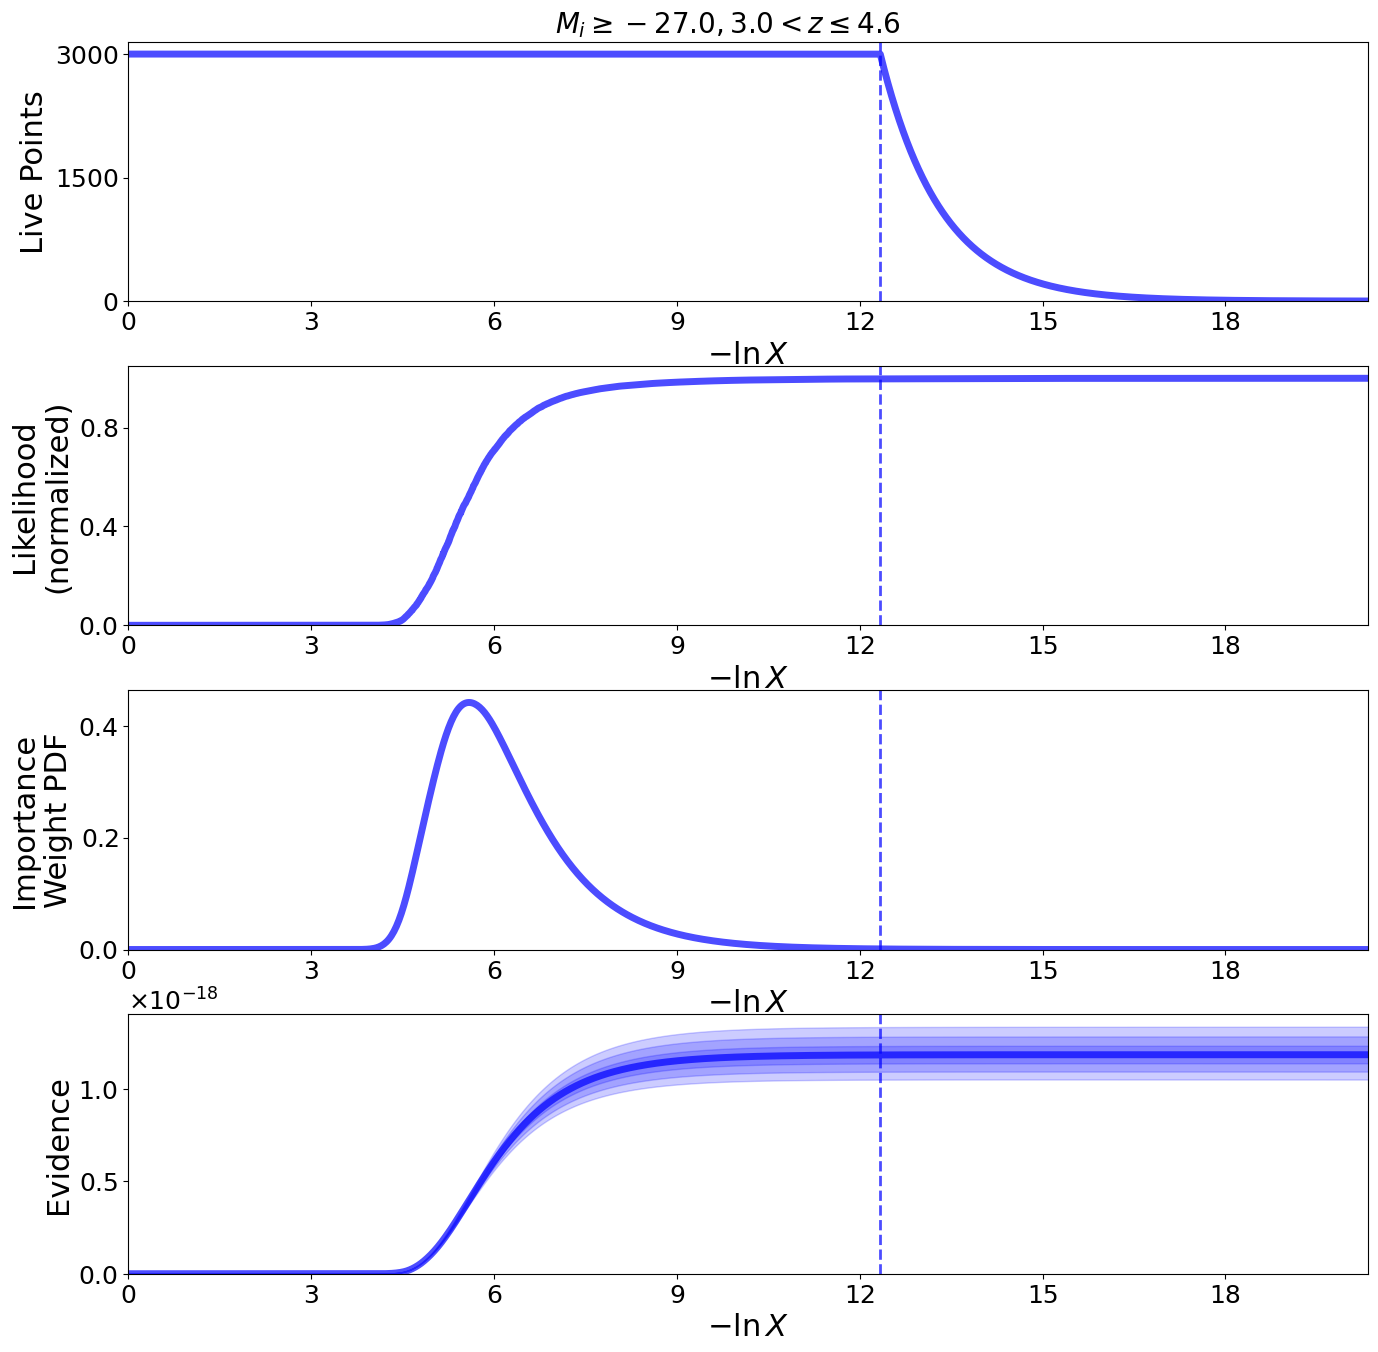

In [74]:
fig, axes = dyplot.runplot(results)  # summary (run) plot
fig.subplots_adjust(hspace=0.25)
fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[j], z_bins[i], z_bins[i+1]), fontsize = 20, y = 0.9)

<>:6: SyntaxWarning: invalid escape sequence '\g'
<>:6: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_8535/2433149354.py:6: SyntaxWarning: invalid escape sequence '\g'
  fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[j], z_bins[i], z_bins[i+1]), fontsize = 20, y = 1)


Text(0.5, 1, '$M_i\\geq-27.0, 3.0<z \\leq4.6$')

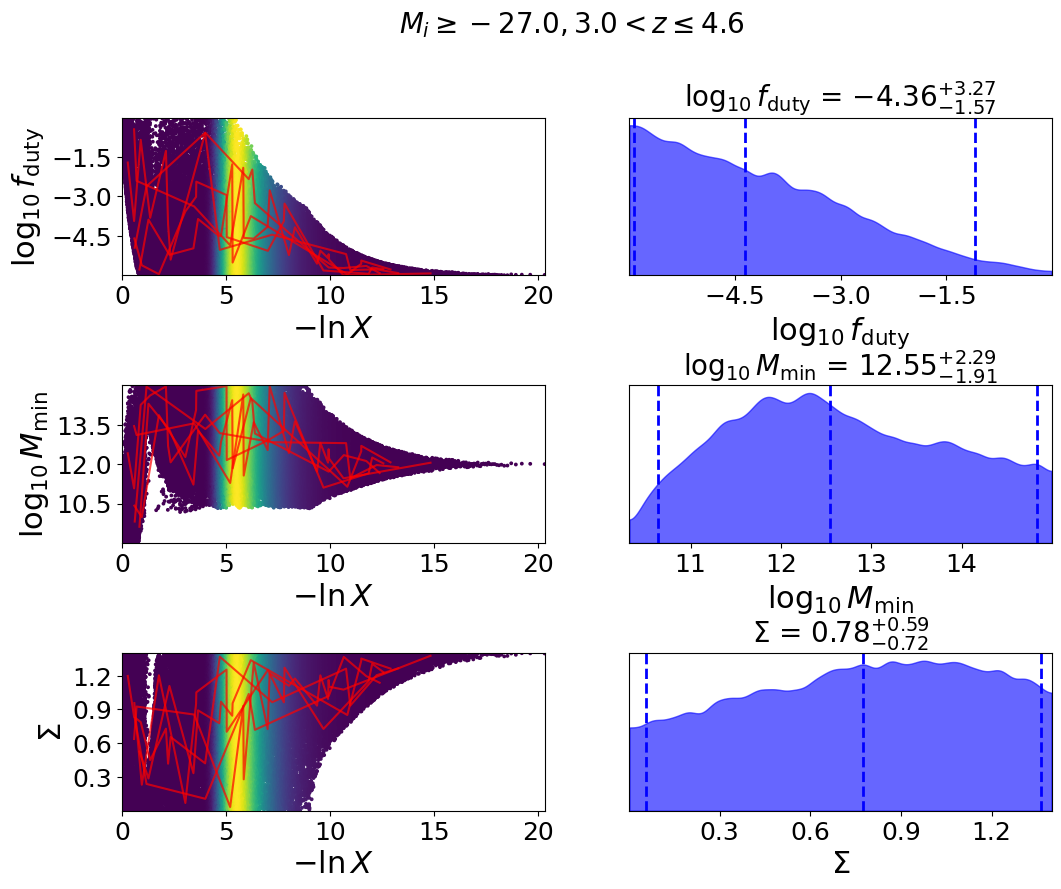

In [75]:
fig, axes = dyplot.traceplot(results, 
                             show_titles=True,
                             trace_cmap='viridis', connect=True,
                             connect_highlight=range(5), labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$', r'$\Sigma$'])
fig.subplots_adjust(hspace=0.7)
fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[j], z_bins[i], z_bins[i+1]), fontsize = 20, y = 1)

<>:7: SyntaxWarning: invalid escape sequence '\g'
<>:7: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_8535/3278304242.py:7: SyntaxWarning: invalid escape sequence '\g'
  fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[j], z_bins[i], z_bins[i+1]), fontsize = 20, y = 0.975, x = 0.575)


Text(0.575, 0.975, '$M_i\\geq-27.0, 3.0<z \\leq4.6$')

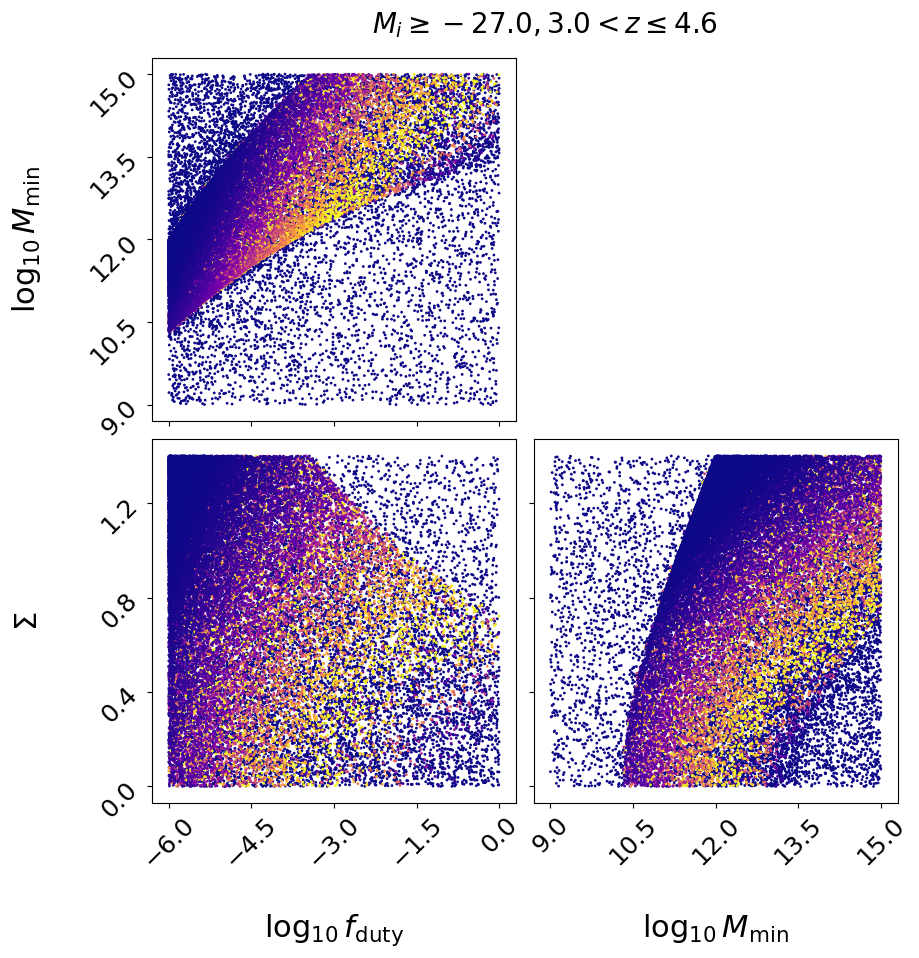

In [76]:
# initialize figure
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# plot initial run (res1; left)
fg, ax = dyplot.cornerpoints(results, cmap='plasma',
                             kde=False, labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$', r'$\Sigma$'], fig=(fig, axes))
fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[j], z_bins[i], z_bins[i+1]), fontsize = 20, y = 0.975, x = 0.575)

<>:8: SyntaxWarning: invalid escape sequence '\g'
<>:8: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_8535/2129952802.py:8: SyntaxWarning: invalid escape sequence '\g'
  fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[j], z_bins[i], z_bins[i+1]), fontsize = 20, y = 1, x = 0.375)


Text(0.375, 1, '$M_i\\geq-27.0, 3.0<z \\leq4.6$')

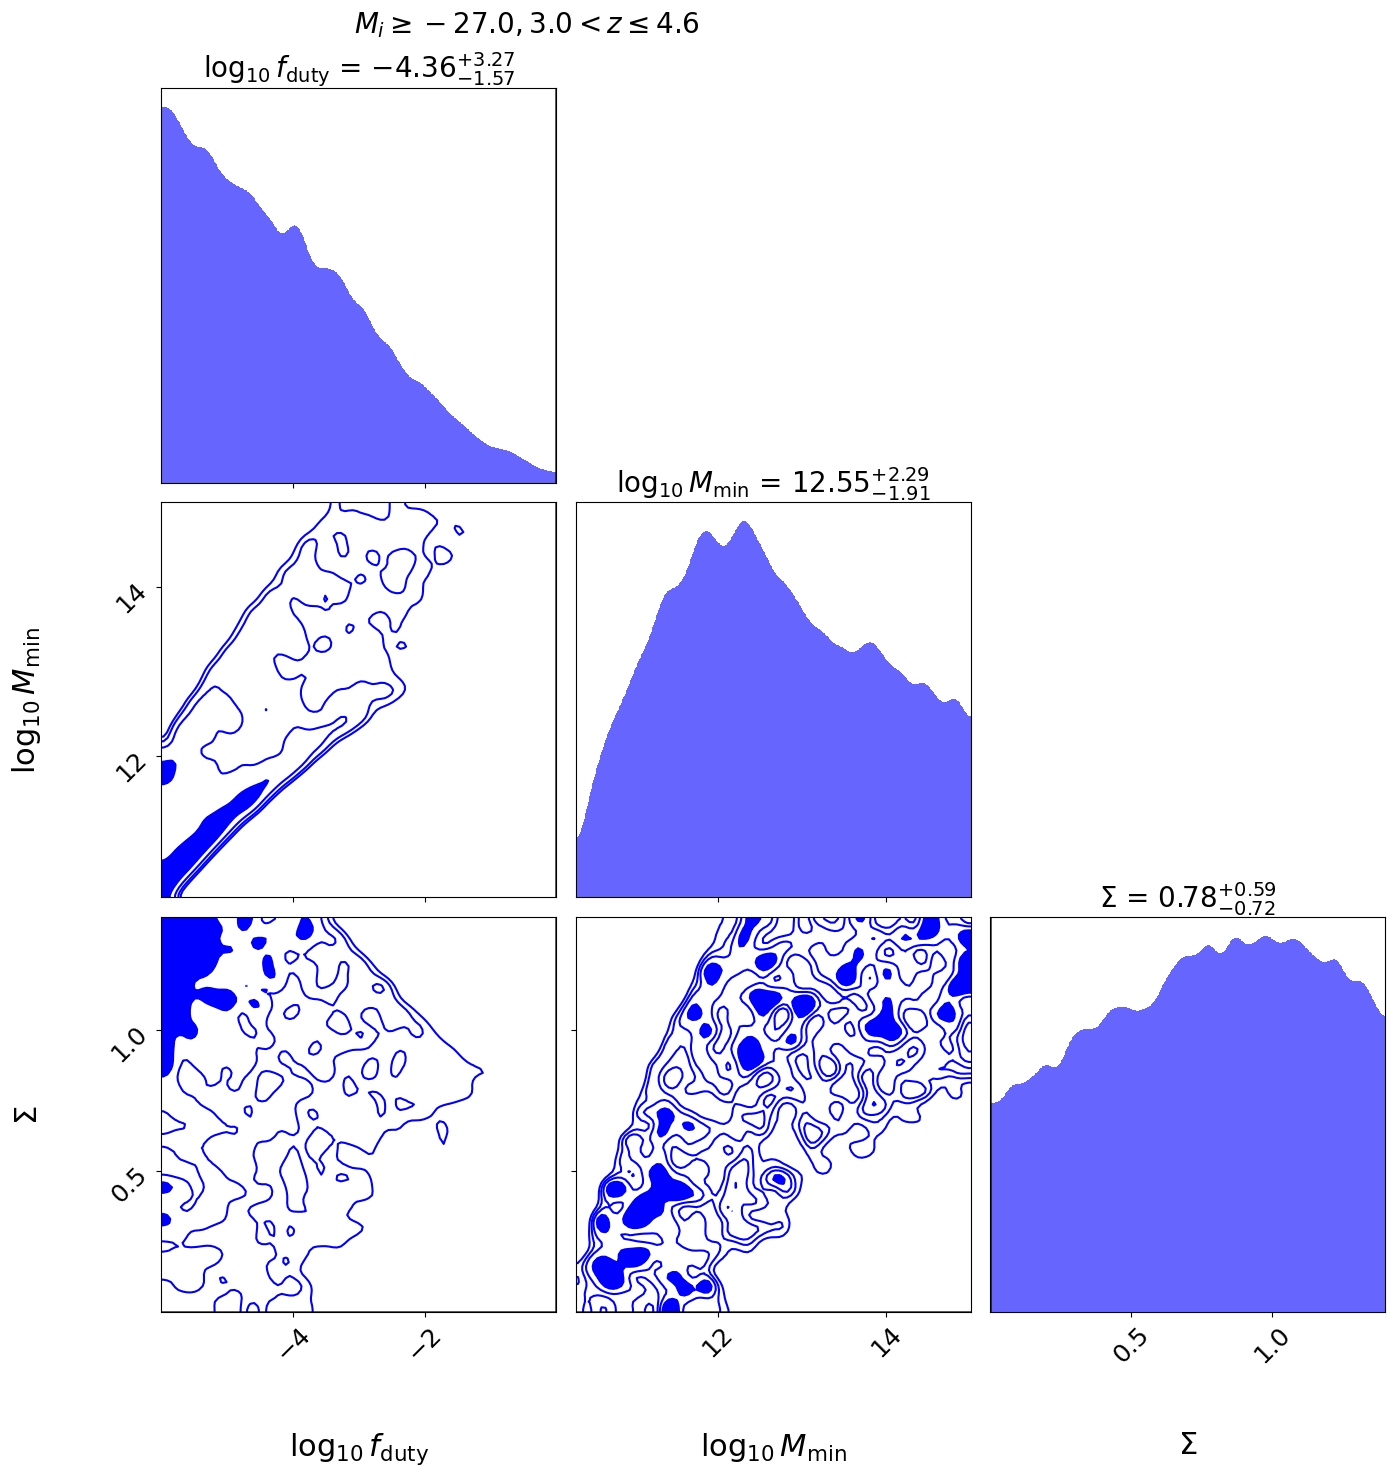

In [77]:
# # initialize figure
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# plot initial run (res1; left)
fg, ax = dyplot.cornerplot(results, color='blue', truths=np.zeros(ndim),
                           truth_color='black', show_titles=True,
                           max_n_ticks=3, quantiles=None, labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$', r'$\Sigma$'], fig=(fig, axes[:, :3]))
fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[j], z_bins[i], z_bins[i+1]), fontsize = 20, y = 1, x = 0.375)

In [78]:
samples, weights = results.samples, results.importance_weights()
mean, cov = dyfunc.mean_and_cov(samples, weights)
print(mean, cov)

[-4.13023467 12.65500012  0.75125894] [[ 1.80059506  1.24373363 -0.02539896]
 [ 1.24373363  1.419392    0.25474204]
 [-0.02539896  0.25474204  0.14742568]]


In [79]:
# Compute weighted quantiles
samples, weights = results.samples, results.importance_weights()

# Get median and 1-sigma (16th, 50th, 84th percentiles) for each parameter
quantiles = [dyfunc.quantile(samples[:, i], [0.025, 0.5, 0.975], weights=weights) 
             for i in range(samples.shape[1])]
labels = ['log10(f_duty)', 'log10(M_min)', 'sigma']

for i, (lo, mid, hi) in enumerate(quantiles):
    print(f"{labels[i]}: {mid:.2f} + {hi-mid:.2f}/-{mid-lo:.2f}")

log10(f_duty): -4.36 + 3.27/-1.57
log10(M_min): 12.55 + 2.29/-1.91
sigma: 0.78 + 0.59/-0.72


## Across all $z$

In [ ]:
f_duty, M_min, sigma = {L: [] for L in L_bins}, {L: [] for L in L_bins}, {L: [] for L in L_bins}
labels = ['log10(f_duty)', 'log10(M_min)', 'sigma']
err = {i: {L: [] for L in L_bins} for i in labels}
f_duty_samples, M_min_samples, sigma_samples = {L: [] for L in L_bins}, {L: [] for L in L_bins}, {L: [] for L in L_bins}
for i in range(len(L_bins)):
    
    for j in z_array:
        
        C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo))
        ix_grid = np.ix_(rpmask[L_bins[i]][j], rpmask[L_bins[i]][j])

        # check if cov is hermitian and positive definite
        if linalg.ishermitian(C) and np.all(np.linalg.eigvals(C) > 0):
            C_factor = linalg.cho_factor(C[ix_grid])
            log_det_C = 2 * np.sum(np.log(np.diag(C_factor[0])))
            solve = lambda rhs: linalg.cho_solve(C_factor, rhs)
        else:
            print('using LU decomposition')
            C_factor = linalg.lu_factor(C[ix_grid])
            log_det_C = np.sum(np.log(np.abs(np.diag(C_factor[0])))) # does abs value make sense
            solve = lambda rhs: linalg.lu_solve(C_factor, rhs)
        
        # initialize our nested sampler
        sampler = NestedSampler(loglike, ptform, ndim, logl_args=[a_zbin[L_bins[i]][j], wp_matter_chi2[L_bins[i]][j][rpmask[L_bins[i]][j]], log_det_C, wp_chi2[L_bins[i]][j][rpmask[L_bins[i]][j]], n_q[L_bins[i]][j], nbins, solve], nlive = nlive)
        
        # run the sampler with checkpointing
        sampler.run_nested(dlogz = dlogz)
        results = sampler.results
        
        # Print out a summary of the results.
        results.summary()
        
        fig, axes = dyplot.runplot(results)  # summary (run) plot
        fig.subplots_adjust(hspace=0.25)
        fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.9)
        
        fig, axes = dyplot.traceplot(results, 
                                     show_titles=True,
                                     trace_cmap='viridis', connect=True,
                                     connect_highlight=range(5), labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$', r'$\Sigma$'])
        fig.subplots_adjust(hspace=0.7)
        fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 1)
        
        # initialize figure
        fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    
        # plot initial run (res1; left)
        fg, ax = dyplot.cornerpoints(results, cmap='plasma',
                                     kde=False, labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$', r'$\Sigma$'], fig=(fig, axes))
        fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.975, x = 0.575)
        
        ## # initialize figure
        fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    
        # plot initial run (res1; left)
        fg, ax = dyplot.cornerplot(results, color='blue', truths=np.zeros(ndim),
                                   truth_color='black', show_titles=True,
                                   max_n_ticks=3, quantiles=None, labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$', r'$\Sigma$'], fig=(fig, axes[:, :3]))
        fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 1, x = 0.375)    
        
        samples, weights = results.samples, results.importance_weights()
    
        # Get median and 1-sigma (16th, 50th, 84th percentiles) for each parameter
        quantiles = [dyfunc.quantile(samples[:, i], [0.16, 0.5, 0.84], weights=weights) 
                     for i in range(samples.shape[1])]
    
        print('{}<z<={}'.format(j, j+1))
        for k, (lo, mid, hi) in enumerate(quantiles):
            print(f"{labels[k]}: {mid:.2f} + {hi-mid:.2f}/-{mid-lo:.2f}")
            err[labels[k]][L_bins[i]].append((lo, hi))
        print()
        
        equal_weight_samples = dyfunc.resample_equal(samples, weights)
        ind = np.random.choice(range(len(equal_weight_samples)), size = 1000, replace = False)
        f_duty_samples[L_bins[i]].append(equal_weight_samples[ind][:,0])
        M_min_samples[L_bins[i]].append(equal_weight_samples[ind][:,1])
        sigma_samples[L_bins[i]].append(equal_weight_samples[ind][:,2])
        
        f_duty[L_bins[i]].append(quantiles[0][1])
        M_min[L_bins[i]].append(quantiles[1][1]) 
        sigma[L_bins[i]].append(quantiles[2][1]) 

<>:35: SyntaxWarning: invalid escape sequence '\g'
<>:42: SyntaxWarning: invalid escape sequence '\g'
<>:50: SyntaxWarning: invalid escape sequence '\g'
<>:59: SyntaxWarning: invalid escape sequence '\g'
<>:35: SyntaxWarning: invalid escape sequence '\g'
<>:42: SyntaxWarning: invalid escape sequence '\g'
<>:50: SyntaxWarning: invalid escape sequence '\g'
<>:59: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_8535/25566774.py:35: SyntaxWarning: invalid escape sequence '\g'
  fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.9)
/tmp/ipykernel_8535/25566774.py:42: SyntaxWarning: invalid escape sequence '\g'
  fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 1)
/tmp/ipykernel_8535/25566774.py:50: SyntaxWarning: invalid escape sequence '\g'
  fig.suptitle('$M_i\geq{}, {:.1f}<z \leq{:.1f}$'.format(L_bins[i], z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.975, x

Summary
nlive: 3000
niter: 42988
ncall: 254889
eff(%): 18.042
logz: -13.754 +/-  0.046
0<z<=1
log10(f_duty): -2.00 + 0.58/-0.38
log10(M_min): 13.16 + 1.17/-0.68
sigma: 0.61 + 0.34/-0.41



42648it [03:11, 222.20it/s, +3000 | bound: 47 | nc: 1 | ncall: 249072 | eff(%): 18.551 | loglstar:   -inf < -1.327 <    inf | logz: -8.632 +/-  0.045 | dlogz:  0.000 >  0.001]   


Summary
nlive: 3000
niter: 42648
ncall: 246072
eff(%): 18.551
logz: -8.632 +/-  0.046
1<z<=2
log10(f_duty): -2.47 + 0.77/-0.49
log10(M_min): 12.85 + 1.42/-0.87
sigma: 0.67 + 0.35/-0.43



9691it [00:39, 70.56it/s, bound: 0 | nc: 16 | ncall: 75123 | eff(%): 12.900 | loglstar:   -inf < -39.717 <    inf | logz: -46.499 +/-  0.044 | dlogz: 29.922 >  0.001]            IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

42850it [03:35, 198.67it/s, +3000 | bound: 55 | nc: 1 | ncall: 274368 | eff(%): 16.896 | loglstar:   -inf < -13.358 <    inf | logz: -20.730 +/-  0.046 | dlogz:  0.000 >  0.001]


...

39734it [08:14, 80.35it/s, +3000 | bound: 60 | nc: 1 | ncall: 291836 | eff(%): 14.795 | loglstar:   -inf < -25.873 <    inf | logz: -32.208 +/-  0.040 | dlogz:  0.000 >  0.001] 


Summary
nlive: 3000
niter: 39734
ncall: 288836
eff(%): 14.795
logz: -32.208 +/-  0.040
1<z<=2
log10(f_duty): -2.54 + 1.02/-1.79
log10(M_min): 12.93 + 1.31/-1.43
sigma: 0.62 + 0.36/-0.40



41864it [06:42, 12.67it/s, bound: 46 | nc: 138 | ncall: 245436 | eff(%): 17.057 | loglstar:   -inf < -10.224 <    inf | logz: -18.362 +/-  0.049 | dlogz:  0.003 >  0.001]       /home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
42364it [07:23, 52.20it/s, bound: 51 | nc: 28 | ncall: 260512 | eff(%): 16.262 | loglstar:   -inf < -10.223 <    inf | logz: -18.361 +/-  0.049 | dlogz:  0.003 >  0.001] /home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined f

Summary
nlive: 3000
niter: 45147
ncall: 311539
eff(%): 15.455
logz: -18.359 +/-  0.049
2<z<=3
log10(f_duty): -1.43 + 0.91/-0.65
log10(M_min): 13.39 + 1.02/-0.74
sigma: 0.48 + 0.23/-0.31



34823it [09:45, 11.13it/s, bound: 70 | nc: 41 | ncall: 316179 | eff(%): 11.014 | loglstar:   -inf < -29.940 <    inf | logz: -35.357 +/-  0.040 | dlogz:  0.002 >  0.001]        

### Solve for $\chi_c^2=\Delta^T x$ where $Cx=\Delta$

In [ ]:
def f0_GLS_solve(x, a, wp_matter, C, wp, rpbins = rbins_chi2, pibins = pibins, cosmo = cosmo_planck18, rpmask = True, hartlap = hartlap, bins_m = bins):  #quaia):
    
    fduty, M_min, sigma = x
    n_m=HOD_scatter(10**fduty, M_min, bins_m, sigma)
        
    wp_2h_zbin, b_q = wp_2h(bins_m, n_m, a, cosmo, wp_matter, rpbins = rpbins, pibins = pibins, recenter = False)
    
    if isinstance(rpmask, bool):
        rpmask = [rpmask]*len(quaia.recenter(rpbins))
    delta = (wp-wp_2h_zbin)[rpmask]
        
    return delta.T @ (hartlap*np.linalg.solve(C, delta))

### Add a number density constraint

In [ ]:
def constraint(x, a, n_q, cosmo = cosmo_planck18, error = 0.05, M_max = M_max, bins_m = bins):
    
    fduty, M_min, sigma = x
    n_m=HOD_scatter(10**fduty, M_min, bins_m, sigma)
    
    n_q_theory = M(bins_m, n_m, a = a, cosmo = cosmo, recenter = False)[1]

    return error-np.abs(n_q_theory-n_q)/n_q

In [ ]:
for i in range(len(L_bins)):

    print('M_i<={}'.format(L_bins[i]))

    for j in z_array:
        
        print('{:.1f}<z<={:.1f}'.format(z_bins[j], z_bins[j+1]))
        x = f_duty[L_bins[i]][j], M_min[L_bins[i]][j], sigma[L_bins[i]][j]
        
        C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo))
        chi2 = f0_GLS_solve(x, a_zbin[L_bins[i]][j], wp_matter_chi2[L_bins[i]][j], C, wp_chi2[L_bins[i]][j])
        df = nbins-len(x)
    
        print('           chi^2: {:.2f}'.format(chi2))
        print('   reduced chi^2: {:.2f}'.format(chi2/df))
        print('         delta n: {:.2e}'.format(constraint(x, a_zbin[L_bins[i]][j], n_q[L_bins[i]][j])))
        print('condition number: {:.2f}'.format(np.linalg.cond(C)))
        print('             PTE: {:.2f}\n'.format(stats.chi2.sf(chi2, df)))

## Plot results

In [69]:
z_eff = [0.5, 1.5, 2.5, 3.5]

In [70]:
M_min_err_hi = [0.04, 0.02, 0.03, 0.1]
M_min_err_lo = [0.05, 0.02, 0.03, 0.12]

In [71]:
cmap_grey = plt.get_cmap('Greys')(np.linspace(0.333, 0.999, len(L_bins)))

In [72]:
M_min_array_old = [12.86, 12.74, 12.79, 12.82]

In [73]:
zmin, zmax = [], []
for i in range(len(L_bins)):
    
    zmin.append(np.min(1/np.array(a_zbin[L_bins[i]])-1))
    zmax.append(np.max(1/np.array(a_zbin[L_bins[i]])-1))

zmin = np.max(zmin)
zmax = np.min(zmax)
zmin, zmax

(0.8839342594146729, 3.2406768798828125)

In [74]:
cmap_green = plt.get_cmap('Greens')(np.linspace(0.333, 0.999, len(z_array)))

In [75]:
blue = np.mean(cmap_blue, axis = 0)
green = np.mean(cmap_green, axis = 0)

In [76]:
penalty = 'hard'

In [77]:
corrfunc = 'wp'

In [78]:
pi = 'pimax{}_'.format(pimax)

In [79]:
file = '_G{}_rmin{}_rmax{}_nbins{}_{}'.format(G_hi, rmin, rmax, nbins, pi)

In [ ]:
fig = plt.figure(figsize = (10, 8))

for i in range(len(L_bins)):
    
    # M_min_lo, M_min_hi = np.array(err['log10(M_min)'][L_bins[i]])[:,0], np.array(err['log10(M_min)'][L_bins[i]])[:,1]
    M_min_lo, M_min_hi = np.load('../results/log10(M_min)_{}{}Lmax{}_N{}_{}_MC_mask_sellentin_nlive{}_dlogz{}{}_ndim{}'.format(corrfunc, file, 
                                                                                                                               L_bins[i], N_jk, cosmo,
                                                                                                                               nlive, dlogz, penalty, 
                                                                                                                               ndim))
    zbin = 1/np.array(a_zbin[L_bins[i]])-1
    plt.plot(zbin, M_min[L_bins[i]], color = cmap_blue[::-1][i], linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
    plt.fill_between(zbin, M_min_lo, M_min_hi, alpha = 0.5, color = cmap_blue[::-1][i])
    
plt.title(r'$w_p(r_p), N_{{jk}}={}$, erfc, sellentin'.format(N))
plt.plot(z_eff, M_min_array, label = 'Giner Mascarell et al. 2025', color = green, linewidth = 2.5, linestyle = '--')
plt.fill_between(z_eff, M_min_array+np.array(M_min_array)/M_min_array_old*M_min_err_hi, M_min_array-np.array(M_min_array)/M_min_array_old*M_min_err_lo, alpha = 0.5, color = green)
plt.ylabel('$\log_{10}(M_{min}/M_\odot)$')
plt.xlabel('$z$')
plt.xlim(zmin, zmax)
plt.ylim(10.95,14.75)

custom_lines = [Line2D([0], [0], color = blue, linestyle = '-', linewidth = 2.5),
                Line2D([0], [0], color = green, linestyle = '--', linewidth = 2.5)]
second_legend = plt.legend(custom_lines, [r'Shiferaw et al. 2026 (this work)', 
                                          'Giner Mascarell et al. 2025'], loc = 'lower left')
fig.add_artist(second_legend)

custom_lines = [mpatches.Patch(color=cmap_grey[::-1][i], alpha = 0.5) for i in range(len(L_bins))]
first_legend = plt.legend(custom_lines, [r'$M_i\leq{}$'.format(L_bins[i]) for i in range(len(L_bins))])
fig.add_artist(first_legend)

# plt.savefig('../figures/log10(M_min)_zbin_wp_rmin{}_rmax{}_nbins{}_N{}_{}_MC_mask.pdf'.format(rmin, rmax, nbins, N, cosmo), bbox_inches  = 'tight')
plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 8))

for i in z_array:
    
    M_min_lo, M_min_hi = [np.array(err['log10(M_min)'][L])[:,0][i] for L in L_bins], [np.array(err['log10(M_min)'][L])[:,1][i] for L in L_bins]
    plt.plot(L_bins, [M_min[L][i] for L in L_bins], color = cmap_blue[i], linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
    plt.fill_between(L_bins, M_min_lo, M_min_hi, alpha = 0.5, color = cmap_blue[i])
    plt.axhline(M_min_array[i], label = 'Giner Mascarell et al. 2025', color = cmap_green[i], linewidth = 2.5, linestyle = '--')
    plt.fill_between(L_bins, [M_min_array[i]+(np.array(M_min_array)/M_min_array_old*M_min_err_hi)[i]]*len(L_bins), [M_min_array[i]-(np.array(M_min_array)/M_min_array_old*M_min_err_lo)[i]]*len(L_bins), alpha = 0.5, color = cmap_green[i])
    
plt.title(r'$w_p(r_p), N_{{jk}}={}$, erfc, sellentin'.format(N))
plt.ylabel('$\log_{10}(M_{min}/M_\odot)$')
plt.xlabel('$M_i$')
plt.xlim(L_bins[0], L_bins[-1])
plt.ylim(10.95,14.75)

custom_lines = [Line2D([0], [0], color = blue, linestyle = '-', linewidth = 2.5),
                Line2D([0], [0], color = green, linestyle = '--', linewidth = 2.5)]
second_legend = plt.legend(custom_lines, [r'Shiferaw et al. 2026 (this work)', 
                                          'Giner Mascarell et al. 2025'], loc = 'lower right')
fig.add_artist(second_legend)

custom_lines = [mpatches.Patch(color=cmap_grey[i], alpha = 0.5) for i in range(len(z_array))]
first_legend = plt.legend(custom_lines, ['${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]) for i in z_array])
fig.add_artist(first_legend)

plt.show()

In [ ]:
fduty_old = [0.018, 0.022, 0.056, 0.071]

In [ ]:
fig = plt.figure(figsize = (10, 8))

for i in range(len(L_bins)):
    
    f_duty_lo, f_duty_hi = np.array(err['log10(f_duty)'][L_bins[i]])[:,0], np.array(err['log10(f_duty)'][L_bins[i]])[:,1]
    zbin = 1/np.array(a_zbin[L_bins[i]])-1
    plt.plot(zbin, f_duty[L_bins[i]], color = cmap_blue[::-1][i], linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
    plt.fill_between(zbin, f_duty_lo, f_duty_hi, alpha = 0.5, color = cmap_blue[::-1][i])
    
plt.title(r'$w_p(r_p), N_{{jk}}={}$, erfc, sellentin'.format(N))
plt.plot(z_eff, np.log10(fduty), label = 'Giner Mascarell et al. 2025', color = green, linewidth = 2.5, linestyle = '--')
plt.fill_between(z_eff, np.log10(np.array(fduty)+np.array(fduty)/fduty_old*fduty_err_hi), np.log10(np.array(fduty)-np.array(fduty)/fduty_old*fduty_err_lo), alpha = 0.5, color = green)
plt.ylabel('$\log_{10}(f_{duty})$')
plt.xlabel('$z$')
plt.xlim(zmin, zmax)
plt.ylim(-4.75,0)

custom_lines = [Line2D([0], [0], color = blue, linestyle = '-', linewidth = 2.5),
                Line2D([0], [0], color = green, linestyle = '--', linewidth = 2.5)]
second_legend = plt.legend(custom_lines, [r'Shiferaw et al. 2026 (this work)', 
                                          'Giner Mascarell et al. 2025'], loc = 'lower left')
fig.add_artist(second_legend)

custom_lines = [mpatches.Patch(color=cmap_grey[::-1][i], alpha = 0.5) for i in range(len(L_bins))]
first_legend = plt.legend(custom_lines, [r'$M_i\leq{}$'.format(L_bins[i]) for i in range(len(L_bins))])
fig.add_artist(first_legend)

plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 8))

for i in z_array:
    
    f_duty_lo, f_duty_hi = [np.array(err['log10(f_duty)'][L])[:,0][i] for L in L_bins], [np.array(err['log10(f_duty)'][L])[:,1][i] for L in L_bins]
    plt.plot(L_bins, [f_duty[L][i] for L in L_bins], color = cmap_blue[i], linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
    plt.fill_between(L_bins, f_duty_lo, f_duty_hi, alpha = 0.5, color = cmap_blue[i])
    plt.axhline(np.log10(fduty)[i], label = 'Giner Mascarell et al. 2025', color = green, linewidth = 2.5, linestyle = '--')
    plt.fill_between(L_bins, [np.log10(np.array(fduty)+np.array(fduty)/fduty_old*fduty_err_hi)[i]]*len(L_bins), [np.log10(np.array(fduty)-np.array(fduty)/fduty_old*fduty_err_lo)[i]]*len(L_bins), alpha = 0.5, color = green)
    
plt.title(r'$w_p(r_p), N_{{jk}}={}$, erfc, sellentin'.format(N))
plt.ylabel('$\log_{10}(f_{duty})$')
plt.xlabel('$M_i$')
plt.xlim(L_bins[0], L_bins[-1])
plt.ylim(-4.75,0)

custom_lines = [Line2D([0], [0], color = blue, linestyle = '-', linewidth = 2.5),
                Line2D([0], [0], color = green, linestyle = '--', linewidth = 2.5)]
second_legend = plt.legend(custom_lines, [r'Shiferaw et al. 2026 (this work)', 
                                          'Giner Mascarell et al. 2025'])
fig.add_artist(second_legend)

custom_lines = [mpatches.Patch(color=cmap_grey[i], alpha = 0.5) for i in range(len(L_bins))]
first_legend = plt.legend(custom_lines, ['${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]) for i in z_array], loc = 'lower left')
fig.add_artist(first_legend)

plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 8))

for i in range(len(L_bins)):
    
    sigma_lo, sigma_hi = np.array(err['sigma'][L_bins[i]])[:,0], np.array(err['sigma'][L_bins[i]])[:,1]
    zbin = 1/np.array(a_zbin[L_bins[i]])-1
    plt.plot(zbin, sigma[L_bins[i]], color = cmap_blue[::-1][i], linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
    plt.fill_between(zbin, sigma_lo, sigma_hi, alpha = 0.5, color = cmap_blue[::-1][i])

plt.axhline(0, color = 'red', linestyle = '--', label = 'step-function HOD $(\Sigma=0)$')
plt.title(r'$w_p(r_p), N_{{jk}}={}$, erfc, sellentin'.format(N))
plt.ylabel('$\Sigma$')
plt.xlabel('$z$')
plt.xlim(zmin, zmax)
plt.ylim(-0.1,1.2)

custom_lines = [Line2D([0], [0], color = blue, linestyle = '-', linewidth = 2.5),
                Line2D([0], [0], color = 'red', linestyle = '--', linewidth = 2.5)]
second_legend = plt.legend(custom_lines, [r'erfc HOD $(0\leq\Sigma<1.4)$', 
                                          'step-function HOD $(\Sigma=0)$'], loc = 'lower left')
fig.add_artist(second_legend)

custom_lines = [mpatches.Patch(color=cmap_grey[::-1][i], alpha = 0.5) for i in range(len(L_bins))]
first_legend = plt.legend(custom_lines, [r'$M_i\leq{}$'.format(L_bins[i]) for i in range(len(L_bins))])
fig.add_artist(first_legend)

plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 8))

for i in z_array:
    
    sigma_lo, sigma_hi = [np.array(err['sigma'][L])[:,0][i] for L in L_bins], [np.array(err['sigma'][L])[:,1][i] for L in L_bins]
    plt.plot(L_bins, [sigma[L][i] for L in L_bins], color = cmap_blue[::-1][i], linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
    plt.fill_between(L_bins, sigma_lo, sigma_hi, alpha = 0.5, color = cmap_blue[::-1][i])

plt.axhline(0, color = 'red', linestyle = '--', label = 'step-function HOD $(\Sigma=0)$')
plt.title(r'$w_p(r_p), N_{{jk}}={}$, erfc, sellentin'.format(N))
plt.ylabel('$\Sigma$')
plt.xlabel('$M_i$')
plt.xlim(L_bins[0], L_bins[-1])
plt.ylim(-0.1, 1.2)

custom_lines = [Line2D([0], [0], color = blue, linestyle = '-', linewidth = 2.5),
                Line2D([0], [0], color = 'red', linestyle = '--', linewidth = 2.5)]
second_legend = plt.legend(custom_lines, [r'erfc HOD $(0\leq\Sigma<1.4)$', 
                                          'step-function HOD $(\Sigma=0)$'], loc = 'lower left')
fig.add_artist(second_legend)

custom_lines = [mpatches.Patch(color=cmap_grey[::-1][i], alpha = 0.5) for i in range(len(z_array))]
first_legend = plt.legend(custom_lines, ['${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]) for i in z_array])
fig.add_artist(first_legend)

plt.show()

In [ ]:
b_eff_wp20 = np.load('../results/b_eff_wp20_planck18.npy')

## Calculate 16th and 84th percentile of derived parameters

In [ ]:
cmap_purple = plt.get_cmap('Purples')(np.linspace(0.333, 0.999, len(L_bins)))

In [ ]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.15, 1, 0.5], hspace = 0, wspace = 0)
ylim = 2e-4, 4e2

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])

    for i in range(len(L_bins)):

        if ((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3):

            C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo))
            
            ax1.errorbar(np.array(rpavg_chi2[L_bins[i]][j])+offset*i, wp_chi2[L_bins[i]][j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = cmap_red[i],
                        yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = '-')
            ax1.plot(quaia.recenter(rbins_offset), b_eff_wp20[j]**2*wp_matter_chi2[L_bins[i]][j], linewidth = 2.5,
                     label = r'${b_{eff, 20}}^2\xi_m$', color = cmap_orange[i], linestyle = '--')
        
            # old fit
            wp_2h_zbin, b_q = wp_2h(bins_M_min[j], n_m_array[j], a_zbin[L_bins[i]][j], cosmo_planck18, wp_matter_chi2[L_bins[i]][j], recenter = False)
            ax1.plot(quaia.recenter(rbins_offset), wp_2h_zbin, linewidth = 2.5, 
                     label = r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(np.log10(fduty[j]), M_min_array[j]), color = cmap_green[i])
            ax2.axhline(b_q, linewidth = 2.5, color = cmap_green[i])
        
            # plot new fit
            n_m=HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j], bins, sigma[L_bins[i]][j])
            wp_2h_zbin, b_q = wp_2h(bins, n_m, a_zbin[L_bins[i]][j], cosmo_planck18, wp_matter_chi2[L_bins[i]][j],
                                    recenter = False)
            ax1.plot(quaia.recenter(rbins_offset), wp_2h_zbin, linewidth = 2.5,
                     label = r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot, \Sigma={:.2f}$ dex)$'.format(f_duty[L_bins[i]][j], M_min[L_bins[i]][j], sigma[L_bins[i]][j]), color = cmap_blue[::-1][i])
            
            wp_2h_samples, b_q_samples=[], []
            for l in range(len(ind)):
                n_m=HOD_scatter(10**f_duty_samples[L_bins[i]][j][l], M_min_samples[L_bins[i]][j][l], bins, sigma_samples[L_bins[i]][j][l])
                wp_2h_sample, b_q_sample = wp_2h(bins, n_m, a_zbin[L_bins[i]][j], cosmo_planck18, wp_matter_chi2[L_bins[i]][j],
                                        recenter = False)
                wp_2h_samples.append(wp_2h_sample)
                b_q_samples.append(b_q_sample)
            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)
            b_q_16, b_q_50, b_q_84 = np.percentile(b_q_samples, [16, 50, 84])
        
            ax1.fill_between(quaia.recenter(rbins_offset), wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5, color = cmap_blue[::-1][i])
            ax2.axhline(b_q, linewidth = 2.5, color = cmap_blue[::-1][i])
            ax2.fill_between(quaia.recenter(rbins_offset), [b_q_16]*nbins, [b_q_84]*nbins, linewidth = 2.5, color = cmap_blue[::-1][i], alpha = 0.5)
            
            ax2.errorbar(quaia.recenter(rbins_chi2)+offset*i, b_wp_chi2[L_bins[i]][j], linewidth = 2.5, linestyle = '--', markeredgewidth = 2.5, capsize = 2.5, color = cmap_purple[i], yerr = np.sqrt(np.diag(C)), label = '$b_{eff}(s)$')

    if quaia.recenter(rbins_chi2)[0] < 30:
            ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                              alpha = 0.5, label = 'scales excluded from fit')
            ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                              alpha = 0.5)
            ax2.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                              alpha = 0.5, label = 'scales excluded from fit')
            ax2.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                              alpha = 0.5)
    ax2.axhline(b_eff_wp20[j], linewidth = 2.5, color = cmap_orange[i], linestyle = '--')

    if (j + k) % 6 < 2:
        ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins_offset)[0], quaia.recenter(rbins_offset)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(ylim)

    ax2.axhline(1, linestyle = '-.', color = 'black', alpha = 0.5)
    ax2.set_xlim(quaia.recenter(rbins_offset)[0], quaia.recenter(rbins_offset)[-1])
    ax2.set_ylim(0, 10)
    
    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')
        ax2.set_ylabel(r'$b(r_p)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if k != 0:
        ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # 
            
    if j % 2 != 0:
        k+=4

custom_lines = [mpatches.Patch(color=cmap_grey[::-1][i], alpha = 0.5) for i in range(len(L_bins))]
first_legend = ax1.legend(custom_lines, [r'$M_i\leq{}$'.format(L_bins[i]) for i in range(len(L_bins))], loc = 'upper right')
fig.add_artist(first_legend)

custom_lines = [Line2D([0], [0], color = np.mean(cmap_red, axis = 0), linestyle = '-', marker = 'o', linewidth = 2.5, markeredgewidth = 2.5),
                Line2D([0], [0], color = np.mean(cmap_orange, axis = 0), linestyle = '--', linewidth = 2.5), Line2D([0], [0], color = green, linestyle = '-', linewidth = 2.5), Line2D([0], [0], color = blue, linestyle = '-', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'Quaia', r'${b_{eff, 20}}^2w_{p,m}$', 'Giner Mascarell et al. 2025', r'Shiferaw et al. 2026 (this work)'], loc = 'lower left')
fig.add_artist(second_legend)

custom_lines = [Line2D([0], [0], color = np.mean(cmap_purple, axis = 0), linestyle = '-',  linewidth = 2.5), Line2D([0], [0], color = 'black', linestyle = '-.',  alpha = 0.5, linewidth = 1)]
third_legend = ax2.legend(custom_lines, [ '$b_{eff}(r_p)$', '$b(r_p)=1$'])
fig.add_artist(third_legend)

plt.show()

In [ ]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.15, 1, 0.5], hspace = 0, wspace = 0)

k = 0
for i in range(len(L_bins)):

    ax1 = fig.add_subplot(gs[i+k])
    ax2 = fig.add_subplot(gs[i+k+2])

    for j in z_array:

        if ((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3):

            C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo))
            
            ax1.errorbar(np.array(rpavg_chi2[L_bins[i]][j])+offset*j, wp_chi2[L_bins[i]][j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = cmap_red[j],
                        yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = '-')
            ax1.plot(quaia.recenter(rbins_offset), b_eff_wp20[j]**2*wp_matter_chi2[L_bins[i]][j], linewidth = 2.5,
                     label = r'${b_{eff, 20}}^2\xi_m$', color = cmap_orange[j], linestyle = '--')
        
            # old fit
            wp_2h_zbin, b_q = wp_2h(bins_M_min[j], n_m_array[j], a_zbin[L_bins[i]][j], cosmo_planck18, wp_matter_chi2[L_bins[i]][j], recenter = False)
            ax1.plot(quaia.recenter(rbins_offset), wp_2h_zbin, linewidth = 2.5, 
                     label = r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(np.log10(fduty[j]), M_min_array[j]), color = cmap_green[j])
            ax2.axhline(b_q, linewidth = 2.5, color = cmap_green[j])
        
            # plot new fit
            n_m=HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j], bins, sigma[L_bins[i]][j])
            wp_2h_zbin, b_q = wp_2h(bins, n_m, a_zbin[L_bins[i]][j], cosmo_planck18, wp_matter_chi2[L_bins[i]][j], 
                                    recenter = False)
            ax1.plot(quaia.recenter(rbins_offset), wp_2h_zbin, linewidth = 2.5,
                     label = r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot, \Sigma={:.2f}$ dex)$'.format(f_duty[L_bins[i]][j], M_min[L_bins[i]][j], sigma[L_bins[i]][j]), color = cmap_blue[j])
            
            wp_2h_samples, b_q_samples=[], []
            for l in range(len(ind)):
                n_m=HOD_scatter(10**f_duty_samples[L_bins[i]][j][l], M_min_samples[L_bins[i]][j][l], bins, sigma_samples[L_bins[i]][j][l])
                wp_2h_sample, b_q_sample = wp_2h(bins, n_m, a_zbin[L_bins[i]][j], cosmo_planck18, wp_matter_chi2[L_bins[i]][j], 
                                        recenter = False)
                wp_2h_samples.append(wp_2h_sample)
                b_q_samples.append(b_q_sample)
            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)
            b_q_16, b_q_50, b_q_84 = np.percentile(b_q_samples, [16, 50, 84])
        
            ax1.fill_between(quaia.recenter(rbins_offset), wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5, color = cmap_blue[j])
            ax2.axhline(b_q, linewidth = 2.5, color = cmap_blue[j])
            ax2.fill_between(quaia.recenter(rbins_offset), [b_q_16]*nbins, [b_q_84]*nbins, linewidth = 2.5, color = cmap_blue[j], alpha = 0.5)
            
            ax2.errorbar(quaia.recenter(rbins_chi2)+offset*i, b_wp_chi2[L_bins[i]][j], linewidth = 2.5, linestyle = '--', markeredgewidth = 2.5, capsize = 2.5, color = cmap_purple[j], yerr = np.sqrt(np.diag(C)), label = '$b_{eff}(s)$')

    if quaia.recenter(rbins_chi2)[0] < 30:
            ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                              alpha = 0.5, label = 'scales excluded from fit')
            ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                              alpha = 0.5)
            ax2.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                              alpha = 0.5, label = 'scales excluded from fit')
            ax2.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                              alpha = 0.5)
    ax2.axhline(b_eff_wp20[j], linewidth = 2.5, color = cmap_orange[j], linestyle = '--')

    if (i + k) % 6 < 2:
        ax1.set_title(r'$M_i\leq{}$'.format(L_bins[i]))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins_offset)[0], quaia.recenter(rbins_offset)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(ylim)

    ax2.axhline(1, linestyle = '-.', color = 'black', alpha = 0.5)
    ax2.set_xlim(quaia.recenter(rbins_offset)[0], quaia.recenter(rbins_offset)[-1])
    ax2.set_ylim(0, 10)
    
    if (i+k) % 2 == 0:
        ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')
        ax2.set_ylabel(r'$b(r_p)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if k != 0:
        ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # 

    if i == 0:
        custom_lines = [mpatches.Patch(color=cmap_grey[l], alpha = 0.5) for l in range(len(L_bins))]
        first_legend = ax1.legend(custom_lines, ['${:.1f}<z \leq{:.1f}$'.format(z_bins[l], z_bins[l+1]) for l in range(len(z_bins)-1)])
        fig.add_artist(first_legend)

    if i % 2 != 0:
        k+=4

custom_lines = [Line2D([0], [0], color = np.mean(cmap_red, axis = 0), linestyle = '-', marker = 'o', linewidth = 2.5, markeredgewidth = 2.5),
                Line2D([0], [0], color = np.mean(cmap_orange, axis = 0), linestyle = '--', linewidth = 2.5), Line2D([0], [0], color = green, linestyle = '-', linewidth = 2.5), Line2D([0], [0], color = blue, linestyle = '-', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'Quaia', r'${b_{eff, 20}}^2r_{p,m}$', 'Giner Mascarell et al. 2025', r'Shiferaw et al. 2026 (this work)'], loc = 'lower left')
fig.add_artist(second_legend)

custom_lines = [Line2D([0], [0], color = np.mean(cmap_purple, axis = 0), linestyle = '-',  linewidth = 2.5), Line2D([0], [0], color = 'black', linestyle = '-.',  alpha = 0.5, linewidth = 1)]
third_legend = ax2.legend(custom_lines, [ '$b_{eff}(r_p)$', '$b(r_p)=1$'])
fig.add_artist(third_legend)

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (40, 51.45))
gs = gridspec.GridSpec(11, 4, wspace = 0, hspace = 0, height_ratios = [1, 0.5, 0.1, 1, 0.5, 0.1, 1, 0.5, 0.1, 1, 0.5])            
k = 0
plot = True
for j in z_array:

    for i in range(len(L_bins)):

        if ((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3):

            ax1 = fig.add_subplot(gs[j*4+i+k])
            ax2 = fig.add_subplot(gs[j*4+i+k+4])
        
            C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo))
            
            ax1.errorbar(np.array(rpavg_chi2[L_bins[i]][j])+offset*i, wp_chi2[L_bins[i]][j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = cmap_red[i],
                        yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = '-')
            ax1.plot(quaia.recenter(rbins_offset), b_eff_wp20[j]**2*wp_matter_chi2[L_bins[i]][j], linewidth = 2.5,
                     label = r'${b_{eff, 20}}^2w_{p,m}$', color = cmap_orange[i], linestyle = '--')
        
            # old fit
            wp_2h_zbin, b_q = wp_2h(bins_M_min[j], n_m_array[j], a_zbin[L_bins[i]][j], cosmo_planck18, wp_matter_chi2[L_bins[i]][j], recenter = False)
            ax1.plot(quaia.recenter(rbins_offset), wp_2h_zbin, linewidth = 2.5, 
                     label = r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(np.log10(fduty[j]), M_min_array[j]), color = cmap_green[i])
            ax2.axhline(b_q, linewidth = 2.5, color = cmap_green[i])
        
            # plot new fit
            n_m=HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j], bins, sigma[L_bins[i]][j])
            wp_2h_zbin, b_q = wp_2h(bins, n_m, a_zbin[L_bins[i]][j], cosmo_planck18, wp_matter_chi2[L_bins[i]][j], 
                                    recenter = False)
            ax1.plot(quaia.recenter(rbins_offset), wp_2h_zbin, linewidth = 2.5,
                     label = r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot, \Sigma={:.2f}$ dex)$'.format(f_duty[L_bins[i]][j], M_min[L_bins[i]][j], sigma[L_bins[i]][j]), color = cmap_blue[::-1][i])
            
            wp_2h_samples, b_q_samples=[], []
            for l in range(len(ind)):
                n_m=HOD_scatter(10**f_duty_samples[L_bins[i]][j][l], M_min_samples[L_bins[i]][j][l], bins, sigma_samples[L_bins[i]][j][l])
                wp_2h_sample, b_q_sample = wp_2h(bins, n_m, a_zbin[L_bins[i]][j], cosmo_planck18, wp_matter_chi2[L_bins[i]][j], 
                                        recenter = False)
                wp_2h_samples.append(wp_2h_sample)
                b_q_samples.append(b_q_sample)
            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)
            b_q_16, b_q_50, b_q_84 = np.percentile(b_q_samples, [16, 50, 84])
        
            ax1.fill_between(quaia.recenter(rbins_offset), wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5, color = cmap_blue[::-1][i])
            ax2.axhline(b_q, linewidth = 2.5, color = cmap_blue[::-1][i])
            ax2.fill_between(quaia.recenter(rbins_offset), [b_q_16]*nbins, [b_q_84]*nbins, linewidth = 2.5, color = cmap_blue[::-1][i], alpha = 0.5)
            
            ax2.errorbar(quaia.recenter(rbins_chi2)+offset*i, b_wp_chi2[L_bins[i]][j], linewidth = 2.5, linestyle = '--', markeredgewidth = 2.5, capsize = 2.5, color = cmap_purple[i], yerr = np.sqrt(np.diag(C)), label = '$b_{eff}(s)$')

            if quaia.recenter(rbins_chi2)[0] < 30:
                    ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                                      alpha = 0.5, label = 'scales excluded from fit')
                    ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                                      alpha = 0.5)
                    ax2.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                                      alpha = 0.5, label = 'scales excluded from fit')
                    ax2.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                                      alpha = 0.5)
            ax2.axhline(b_eff_wp20[j], linewidth = 2.5, color = cmap_orange[i], linestyle = '--')
        
            if j==0:
                ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
            ax1.set_yscale('log')
            ax1.set_xlim(quaia.recenter(rbins_offset)[0], quaia.recenter(rbins_offset)[-1])
            ax1.set_xticklabels([])
            ax1.set_ylim(ylim)
        
            ax2.axhline(1, linestyle = '-.', color = 'black', alpha = 0.5)
            ax2.set_xlim(quaia.recenter(rbins_offset)[0], quaia.recenter(rbins_offset)[-1])
            ax2.set_ylim(0, 10)
            
            if i == 0 or plot == False:
                ax1.set_ylabel(r'$w_p(r_p)$')
                ax2.set_ylabel(r'$b(r_p)$')
            else:
                ax1.set_yticklabels([])
                ax2.set_yticklabels([])
            plot = True
        
            if j == 3:
                ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # 
                
            if i == 3:
                k+=8
            
        else:
            plot = False

custom_lines = [mpatches.Patch(color=cmap_grey[i], alpha = 0.5) for i in range(len(L_bins))]
first_legend = ax1.legend(custom_lines, ['${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]) for j in z_array], loc = 'lower left')
fig.add_artist(first_legend)

custom_lines = [Line2D([0], [0], color = np.mean(cmap_red, axis = 0), linestyle = '-', marker = 'o', linewidth = 2.5, markeredgewidth = 2.5),
                Line2D([0], [0], color = np.mean(cmap_orange, axis = 0), linestyle = '--', linewidth = 2.5), Line2D([0], [0], color = green, linestyle = '-', linewidth = 2.5), Line2D([0], [0], color = blue, linestyle = '-', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'Quaia', r'${b_{eff, 20}}^2w_{p,m}$', 'Giner Mascarell et al. 2025', r'Shiferaw et al. 2026 (this work)'], loc = 'upper right')
fig.add_artist(second_legend)

custom_lines = [Line2D([0], [0], color = np.mean(cmap_purple, axis = 0), linestyle = '-',  linewidth = 2.5), Line2D([0], [0], color = 'black', linestyle = '-.',  alpha = 0.5, linewidth = 1)]
third_legend = ax2.legend(custom_lines, [ '$b_{eff}(r_p)$', '$b(r_p)=1$'])
fig.add_artist(third_legend)

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (40, 51.45))
gs = gridspec.GridSpec(11, 4, wspace = 0, hspace = 0, height_ratios = [1, 0.5, 0.1, 1, 0.5, 0.1, 1, 0.5, 0.1, 1, 0.5])            
k = 0

for i in range(len(L_bins)):

    for j in z_array:

        if ((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3):

            ax1 = fig.add_subplot(gs[i*4+j+k])
            ax2 = fig.add_subplot(gs[i*4+j+k+4])
        
            C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo))
            
            ax1.errorbar(np.array(rpavg_chi2[L_bins[i]][j])+offset*i, wp_chi2[L_bins[i]][j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = cmap_red[j],
                        yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = '-')
            ax1.plot(quaia.recenter(rbins_offset), b_eff_wp20[j]**2*wp_matter_chi2[L_bins[i]][j], linewidth = 2.5,
                     label = r'${b_{eff, 20}}^2\xi_m$', color = cmap_orange[j], linestyle = '--')
        
            # old fit
            wp_2h_zbin, b_q = wp_2h(bins_M_min[j], n_m_array[j], a_zbin[L_bins[i]][j], cosmo_planck18, wp_matter_chi2[L_bins[i]][j], recenter = False)
            ax1.plot(quaia.recenter(rbins_offset), wp_2h_zbin, linewidth = 2.5, 
                     label = r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(np.log10(fduty[j]), M_min_array[j]), color = cmap_green[i])
            ax2.axhline(b_q, linewidth = 2.5, color = cmap_green[j])
        
            # plot new fit
            n_m=HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j], bins, sigma[L_bins[i]][j])
            wp_2h_zbin, b_q = wp_2h(bins, n_m, a_zbin[L_bins[i]][j], cosmo_planck18, wp_matter_chi2[L_bins[i]][j], 
                                    recenter = False)
            ax1.plot(quaia.recenter(rbins_offset), wp_2h_zbin, linewidth = 2.5,
                     label = r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot, \Sigma={:.2f}$ dex)$'.format(f_duty[L_bins[i]][j], M_min[L_bins[i]][j], sigma[L_bins[i]][j]), color = cmap_blue[j])
            
            wp_2h_samples, b_q_samples=[], []
            for l in range(len(ind)):
                n_m=HOD_scatter(10**f_duty_samples[L_bins[i]][j][l], M_min_samples[L_bins[i]][j][l], bins, sigma_samples[L_bins[i]][j][l])
                wp_2h_sample, b_q_sample = wp_2h(bins, n_m, a_zbin[L_bins[i]][j], cosmo_planck18, wp_matter_chi2[L_bins[i]][j], 
                                        recenter = False)
                wp_2h_samples.append(wp_2h_sample)
                b_q_samples.append(b_q_sample)
            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)
            b_q_16, b_q_50, b_q_84 = np.percentile(b_q_samples, [16, 50, 84])
        
            ax1.fill_between(quaia.recenter(rbins_offset), wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5, color = cmap_blue[j])
            ax2.axhline(b_q, linewidth = 2.5, color = cmap_blue[j])
            ax2.fill_between(quaia.recenter(rbins_offset), [b_q_16]*nbins, [b_q_84]*nbins, linewidth = 2.5, color = cmap_blue[j], alpha = 0.5)
            
            ax2.errorbar(quaia.recenter(rbins_chi2)+offset*i, b_wp_chi2[L_bins[i]][j], linewidth = 2.5, linestyle = '--', markeredgewidth = 2.5, capsize = 2.5, color = cmap_purple[j], yerr = np.sqrt(np.diag(C)), label = '$b_{eff}(s)$')

            if quaia.recenter(rbins_chi2)[0] < 30:
                    ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                                      alpha = 0.5, label = 'scales excluded from fit')
                    ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                                      alpha = 0.5)
                    ax2.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                                      alpha = 0.5, label = 'scales excluded from fit')
                    ax2.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                                      alpha = 0.5)
            ax2.axhline(b_eff_wp20[j], linewidth = 2.5, color = cmap_orange[j], linestyle = '--')
        
            if i ==0 or ((i<3) and (j>1) and (i!=j)):
                ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))
            ax1.set_yscale('log')
            ax1.set_xlim(quaia.recenter(rbins_offset)[0], quaia.recenter(rbins_offset)[-1])
            ax1.set_xticklabels([])
            ax1.set_ylim(ylim)
        
            ax2.axhline(1, linestyle = '-.', color = 'black', alpha = 0.5)
            ax2.set_xlim(quaia.recenter(rbins_offset)[0], quaia.recenter(rbins_offset)[-1])
            ax2.set_ylim(0, 10)
            
            if j == 0:
                ax1.set_ylabel(r'$w_p(r_p)$')
                ax2.set_ylabel(r'$b(r_p)$')
            else:
                ax1.set_yticklabels([])
                ax2.set_yticklabels([])
        
            if i == 3:
                ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # 
                
        if j == 3:
            k+=8

custom_lines = [mpatches.Patch(color=cmap_grey[::-1][i], alpha = 0.5) for i in range(len(L_bins))]
first_legend = ax1.legend(custom_lines, [r'$M_i\leq{}$'.format(L_bins[i]) for i in range(len(L_bins))], loc = 'lower left')
fig.add_artist(first_legend)

custom_lines = [Line2D([0], [0], color = np.mean(cmap_red, axis = 0), linestyle = '-', marker = 'o', linewidth = 2.5, markeredgewidth = 2.5),
                Line2D([0], [0], color = np.mean(cmap_orange, axis = 0), linestyle = '--', linewidth = 2.5), Line2D([0], [0], color = green, linestyle = '-', linewidth = 2.5), Line2D([0], [0], color = blue, linestyle = '-', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'Quaia', r'${b_{eff, 20}}^2w_{p,m}$', 'Giner Mascarell et al. 2025', r'Shiferaw et al. 2026 (this work)'], loc = 'upper right')
fig.add_artist(second_legend)

custom_lines = [Line2D([0], [0], color = np.mean(cmap_purple, axis = 0), linestyle = '-',  linewidth = 2.5), Line2D([0], [0], color = 'black', linestyle = '-.',  alpha = 0.5, linewidth = 1)]
third_legend = ax2.legend(custom_lines, [ '$b_{eff}(r_p)$', '$b(r_p)=1$'])
fig.add_artist(third_legend)

plt.show()

In [ ]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.15)

for j in z_array:
    
    ax1 = fig.add_subplot(gs[j])

    for i in range(len(L_bins)):

        if ((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3):

            C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo))
            
            ax1.errorbar(np.array(rpavg_chi2[L_bins[i]][j])+offset*i, wp_chi2[L_bins[i]][j], linewidth = 2.5, marker = 'o', label = r'Quaia', 
                         color = cmap_red[i], yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = '-')
        
            # plot new fit
            n_m=HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j], bins, sigma[L_bins[i]][j])
            wp_2h_zbin, b_q = wp_2h(bins, n_m, a_zbin[L_bins[i]][j], cosmo_planck18, wp_matter_chi2[L_bins[i]][j], 
                                    recenter = False)
            ax1.plot(quaia.recenter(rbins_offset), wp_2h_zbin, linewidth = 2.5, color = cmap_blue[::-1][i])
            
            wp_2h_samples, b_q_samples=[], []
            for l in range(len(ind)):
                n_m=HOD_scatter(10**f_duty_samples[L_bins[i]][j][l], M_min_samples[L_bins[i]][j][l], bins, sigma_samples[L_bins[i]][j][l])
                wp_2h_sample, b_q_sample = wp_2h(bins, n_m, a_zbin[L_bins[i]][j], cosmo_planck18, wp_matter_chi2[L_bins[i]][j], 
                                        recenter = False)
                wp_2h_samples.append(wp_2h_sample)
                b_q_samples.append(b_q_sample)
            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)
            b_q_16, b_q_50, b_q_84 = np.percentile(b_q_samples, [16, 50, 84])
        
            ax1.fill_between(quaia.recenter(rbins_offset), wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5, color = cmap_blue[::-1][i])
            
    if quaia.recenter(rbins_chi2)[0] < 30:
        ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                          alpha = 0.5, label = 'scales excluded from fit')
        ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                          alpha = 0.5)

    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins_offset)[0], quaia.recenter(rbins_offset)[-1])
    ax1.set_ylim(ylim)
    
    if j%2==0:
        ax1.set_ylabel(r'$w_p(r_p)$')
    else:
        ax1.set_yticklabels([])

    if j>1:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected

custom_lines = [mpatches.Patch(color=cmap_grey[::-1][l], alpha = 0.5) for l in range(len(L_bins))]
first_legend = ax1.legend(custom_lines, [r'$M_i\leq{}$'.format(L_bins[i]) for i in range(len(L_bins))], loc = 'lower right')
fig.add_artist(first_legend)

custom_lines = [Line2D([0], [0], color = np.mean(cmap_red, axis = 0), linestyle = '-', marker = 'o', linewidth = 2.5, markeredgewidth = 2.5),
                Line2D([0], [0], color = blue, linestyle = '-', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'Quaia', r'Shiferaw et al. 2026 (this work)'], loc = 'upper left')
fig.add_artist(second_legend)

plt.show()

In [ ]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.15)

for i in range(len(L_bins)):

    ax1 = fig.add_subplot(gs[i])

    for j in z_array:

        if ((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3):

            C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo))
            
            ax1.errorbar(np.array(rpavg_chi2[L_bins[i]][j])+offset*j, wp_chi2[L_bins[i]][j], linewidth = 2.5, marker = 'o', label = r'Quaia', 
                         color = cmap_red[j], yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = '-')
        
            # plot new fit
            n_m=HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j], bins, sigma[L_bins[i]][j])
            wp_2h_zbin, b_q = wp_2h(bins, n_m, a_zbin[L_bins[i]][j], cosmo_planck18, wp_matter_chi2[L_bins[i]][j], 
                                    recenter = False)
            ax1.plot(quaia.recenter(rbins_offset), wp_2h_zbin, linewidth = 2.5, color = cmap_blue[j])
            
            wp_2h_samples, b_q_samples=[], []
            for l in range(len(ind)):
                n_m=HOD_scatter(10**f_duty_samples[L_bins[i]][j][l], M_min_samples[L_bins[i]][j][l], bins, sigma_samples[L_bins[i]][j][l])
                wp_2h_sample, b_q_sample = wp_2h(bins, n_m, a_zbin[L_bins[i]][j], cosmo_planck18, wp_matter_chi2[L_bins[i]][j], 
                                        recenter = False)
                wp_2h_samples.append(wp_2h_sample)
                b_q_samples.append(b_q_sample)
            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)
            b_q_16, b_q_50, b_q_84 = np.percentile(b_q_samples, [16, 50, 84])
        
            ax1.fill_between(quaia.recenter(rbins_offset), wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5, color = cmap_blue[j])
            
    if quaia.recenter(rbins_chi2)[0] < 30:
        ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                          alpha = 0.5, label = 'scales excluded from fit')
        ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                          alpha = 0.5)

    ax1.set_title(r'$M_i\leq{}$'.format(L_bins[i]))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins_offset)[0], quaia.recenter(rbins_offset)[-1])
    ax1.set_ylim(ylim)
    
    if i%2==0:
        ax1.set_ylabel(r'$w_p(r_p)$')
    else:
        ax1.set_yticklabels([])

    if i>1:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected

    if i ==0:
        custom_lines = [mpatches.Patch(color=cmap_grey[l], alpha = 0.5) for l in range(len(L_bins))]
        first_legend = ax1.legend(custom_lines, ['${:.1f}<z \leq{:.1f}$'.format(z_bins[l], z_bins[l+1]) for l in z_array])
        fig.add_artist(first_legend)

custom_lines = [Line2D([0], [0], color = np.mean(cmap_red, axis = 0), linestyle = '-', marker = 'o', linewidth = 2.5, markeredgewidth = 2.5),
                Line2D([0], [0], color = blue, linestyle = '-', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'Quaia', r'Shiferaw et al. 2026 (this work)'])
fig.add_artist(second_legend)

plt.show()

In [ ]:
# remove bottom panel and just print bq somewhere
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0.1)

for j in range(len(z_array)):
    
    for i in range(len(L_bins)):

        if ((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3):

            ax1 = fig.add_subplot(gs[j*4+i])

            C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo))
                   
            ax1.errorbar(rpavg_chi2[L_bins[i]][j], wp_chi2[L_bins[i]][j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = cmap_red[i],
                        yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none', zorder = 3)
            if quaia.recenter(rbins_chi2)[0] < 30:
                ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                                  alpha = 0.5, label = 'scales excluded from fit')
                ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                                  alpha = 0.5)
        
            # plot new fit
            n_m=HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j], bins, sigma[L_bins[i]][j])
            wp_2h_zbin, b_q = wp_2h(bins, n_m, a_zbin[L_bins[i]][j], cosmo_planck18, wp_matter_chi2[L_bins[i]][j], 
                                    recenter = False)
            ax1.plot(quaia.recenter(rbins_offset), wp_2h_zbin, linewidth = 2.5,
                     label = r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot, \Sigma={:.2f}$ dex)$'.format(f_duty[L_bins[i]][j], M_min[L_bins[i]][j], sigma[L_bins[i]][j]), color = cmap_blue[::-1][i])
            
            wp_2h_samples=[]
            for l in range(len(ind)):
                n_m=HOD_scatter(10**f_duty_samples[L_bins[i]][j][l], M_min_samples[L_bins[i]][j][l], bins, sigma_samples[L_bins[i]][j][l])
                wp_2h_sample, _ = wp_2h(bins, n_m, a_zbin[L_bins[i]][j], cosmo_planck18, wp_matter_chi2[L_bins[i]][j], 
                                        recenter = False)
                wp_2h_samples.append(wp_2h_sample)
            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)
            ax1.fill_between(quaia.recenter(rbins_chi2), wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5,
                     color = cmap_blue[::-1][i])    
        
            if j==0:
                ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
            ax1.set_yscale('log')
            ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
            ax1.set_ylim(ylim)
            ax1.legend()
            
            if i==0 or ((j>1) and (i<3) and (i!=j)):
                ax1.set_ylabel(r"$w_{{p,{:.1f}<z \leq{:.1f}}}(s)$".format(z_bins[j], z_bins[j+1]))
            else:
                ax1.set_yticklabels([])
        
            if j > 2 or ((j>0) and (i<2) and (i!=j)):
                ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') 

plt.show()

In [ ]:
# remove bottom panel and just print bq somewhere
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0.1)
    
for i in range(len(L_bins)):

    for j in range(len(z_array)):

        if ((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3):

            ax1 = fig.add_subplot(gs[i*4+j])

            C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo))
                   
            ax1.errorbar(rpavg_chi2[L_bins[i]][j], wp_chi2[L_bins[i]][j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = cmap_red[j],
                        yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none', zorder = 3)
            if quaia.recenter(rbins_chi2)[0] < 30:
                ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                                  alpha = 0.5, label = 'scales excluded from fit')
                ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                                  alpha = 0.5)
        
            # plot new fit
            n_m=HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j], bins, sigma[L_bins[i]][j])
            wp_2h_zbin, b_q = wp_2h(bins, n_m, a_zbin[L_bins[i]][j], cosmo_planck18, wp_matter_chi2[L_bins[i]][j], 
                                    recenter = False)
            ax1.plot(quaia.recenter(rbins_offset), wp_2h_zbin, linewidth = 2.5,
                     label = r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot, \Sigma={:.2f}$ dex)$'.format(f_duty[L_bins[i]][j], M_min[L_bins[i]][j], sigma[L_bins[i]][j]), color = cmap_blue[j])
            
            wp_2h_samples=[]
            for l in range(len(ind)):
                n_m=HOD_scatter(10**f_duty_samples[L_bins[i]][j][l], M_min_samples[L_bins[i]][j][l], bins, sigma_samples[L_bins[i]][j][l])
                wp_2h_samples.append(wp_2h_sample)
            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)
            ax1.fill_between(quaia.recenter(rbins_chi2), wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5,
                     color = cmap_blue[j])    
        
            if i ==0 or ((i<3) and (j>1) and (i!=j)):
                ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))
            ax1.set_yscale('log')
            ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
            ax1.set_ylim(ylim)
            ax1.legend()
            
            if j==0:
                ax1.set_ylabel(r"$w_{{p,M_i\leq{}}}(s)$".format(L_bins[i]))
            else:
                ax1.set_yticklabels([])
        
            if i > 2:
                ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') 

plt.show()

In [ ]:
cmap_M_min = sns.color_palette("vlag", n_colors = len(bins))
palette_M_min = matplotlib.colors.ListedColormap(cmap_M_min)
palette_M_min

In [ ]:
# remove bottom panel and just print bq somewhere
# plot!
fig = plt.figure(figsize = (41, 32))
gs = gridspec.GridSpec(4, 6, wspace = 0, hspace = 0.1, width_ratios = [1,1,1,1,0.05,0.05])

l = 0
for j in range(len(z_array)):
    
    for i in range(len(L_bins)):

        if ((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3):

            ax1 = fig.add_subplot(gs[j*4+i+l])
            
            C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], 
                                                                                                                    z_bins[j+1], L_bins[i], N, cosmo))

            if quaia.recenter(rbins_chi2)[0] < 30:
                ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                                  alpha = 0.5, label = 'scales excluded from fit')
                ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                                  alpha = 0.5)
        
            # plot new fit
            n_m=HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j], bins, sigma[L_bins[i]][j])
            wp_2h_zbin, b_q = wp_2h(bins, n_m, a_zbin[L_bins[i]][j], cosmo_planck18, wp_matter_chi2[L_bins[i]][j], 
                                    recenter = False)
            ax1.plot(quaia.recenter(rbins_offset), wp_2h_zbin, linewidth = 2.5,
                     label = r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot, \Sigma={:.2f}$ dex)$'.format(f_duty[L_bins[i]][j], M_min[L_bins[i]][j], sigma[L_bins[i]][j]), 
                     color = cmap_blue[::-1][i])
        
            for k in range(len(bins)):
                n_m=HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j]-1+k/int(len(bins)/2), bins, sigma[L_bins[i]][j])
                wp_2h_sample, _ = wp_2h(bins, n_m, a_zbin[L_bins[i]][j], 
                         cosmo_planck18, wp_matter_chi2[L_bins[i]][j], recenter = False)
                ax1.plot(quaia.recenter(rbins_chi2), wp_2h_sample, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))
                
            wp_2h_samples = []
            for k in range(len(ind)):
                n_m=HOD_scatter(10**f_duty_samples[L_bins[i]][j][k], M_min_samples[L_bins[i]][j][k], bins, sigma_samples[L_bins[i]][j][k])
                wp_2h_sample, _ = wp_2h(np.logspace(bins, n_m, a_zbin[L_bins[i]][j], cosmo_planck18, 
                                        wp_matter_chi2[L_bins[i]][j], recenter = False)
                wp_2h_samples.append(wp_2h_sample)
            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)
            ax1.fill_between(quaia.recenter(rbins_chi2), wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5,
                     color = cmap_blue[::-1][i])    
            
            if j==0:
                ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
            ax1.set_yscale('log')
            ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
            ax1.set_ylim(ylim)
            ax1.legend()
            
            if i==0 or ((j>1) and (i<3) and (i!=j)):
                ax1.set_ylabel(r"$w_{{p,{:.1f}<z \leq{:.1f}}}(s)$".format(z_bins[j], z_bins[j+1]))
            else:
                ax1.set_yticklabels([])
        
            if j > 2 or ((j>0) and (i<2) and (i!=j)):
                ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') 

            if i == 3:
                l+=2

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [ ]:
# remove bottom panel and just print bq somewhere
# plot!
fig = plt.figure(figsize = (41, 32))
gs = gridspec.GridSpec(4, 6, wspace = 0, hspace = 0.1, width_ratios = [1,1,1,1,0.05,0.05])

l = 0
for i in range(len(L_bins)):

    for j in range(len(z_array)):

        if ((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3):

            ax1 = fig.add_subplot(gs[i*4+j+l])
            
            C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], 
                                                                                                                    z_bins[j+1], L_bins[i], N, cosmo))

            if quaia.recenter(rbins_chi2)[0] < 30:
                ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                                  alpha = 0.5, label = 'scales excluded from fit')
                ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                                  alpha = 0.5)
        
            # plot new fit
            n_m=HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j], bins, sigma[L_bins[i]][j])
            wp_2h_zbin, b_q = wp_2h(bins, n_m, a_zbin[L_bins[i]][j], cosmo_planck18, wp_matter_chi2[L_bins[i]][j], 
                                    recenter = False)
            ax1.plot(quaia.recenter(rbins_offset), wp_2h_zbin, linewidth = 2.5,
                     label = r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot, \Sigma={:.2f}$ dex)$'.format(f_duty[L_bins[i]][j], M_min[L_bins[i]][j], sigma[L_bins[i]][j]), 
                     color = cmap_blue[j])
        
            for k in range(len(bins)):
                n_m=HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j]-1+k/int(len(bins)/2), bins, sigma[L_bins[i]][j])
                wp_2h_sample, _ = wp_2h(bins, M_max, 79), n_m, a_zbin[L_bins[i]][j], 
                         cosmo_planck18, wp_matter_chi2[L_bins[i]][j], recenter = False)
                ax1.plot(quaia.recenter(rbins_chi2), wp_2h_sample, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))
                
            wp_2h_samples = []
            for k in range(len(ind)):
                n_m=HOD_scatter(10**f_duty_samples[L_bins[i]][j][k], M_min_samples[L_bins[i]][j][k], bins, sigma_samples[L_bins[i]][j][k])
                wp_2h_sample, _ = wp_2h(bins, n_m, a_zbin[L_bins[i]][j], cosmo_planck18, 
                                        wp_matter_chi2[L_bins[i]][j], recenter = False)
                wp_2h_samples.append(wp_2h_sample)
            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)
            ax1.fill_between(quaia.recenter(rbins_chi2), wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5,
                     color = cmap_blue[j])    
            
            if i ==0 or ((i<3) and (j>1) and (i!=j)):
                ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))
            ax1.set_yscale('log')
            ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
            ax1.set_ylim(ylim)
            ax1.legend()
            
            if j==0:
                ax1.set_ylabel(r"$w_{{p,M_i\leq{}}}(s)$".format(L_bins[i]))
            else:
                ax1.set_yticklabels([])
        
            if i > 2:
                ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') 

        if j == 3:
            l+=2

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [ ]:
sigma_k_array = np.linspace(0,1.4, 51) #-4

In [ ]:
cmap_sigma = sns.color_palette("vlag", n_colors = len(sigma_k_array))
palette_sigma = matplotlib.colors.ListedColormap(cmap_sigma)
palette_sigma

In [ ]:
delta = 0.3 #0.1

In [ ]:
# remove bottom panel and just print bq somewhere
# plot!
fig = plt.figure(figsize = (41, 32))
gs = gridspec.GridSpec(4, 6, wspace = 0, hspace = 0.1, width_ratios = [1,1,1,1,0.05,0.05])

l = 0
for j in range(len(z_array)):
    
    for i in range(len(L_bins)):

        if ((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3):

            ax1 = fig.add_subplot(gs[j*4+i+l])
            
            C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], 
                                                                                                                    z_bins[j+1], L_bins[i], N, cosmo))

            if quaia.recenter(rbins_chi2)[0] < 30:
                ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                                  alpha = 0.5, label = 'scales excluded from fit')
                ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                                  alpha = 0.5)
        
            # plot new fit
            n_m=HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j], bins, sigma[L_bins[i]][j])
            wp_2h_zbin, b_q = wp_2h(bins, n_m, a_zbin[L_bins[i]][j], cosmo_planck18, wp_matter_chi2[L_bins[i]][j], 
                                    recenter = False)
            ax1.plot(quaia.recenter(rbins_offset), cf_2h_zbin, linewidth = 2.5,
                     label = r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot, \Sigma={:.2f}$ dex))'.format(f_duty[L_bins[i]][j], 
                                                                                                                M_min[L_bins[i]][j], sigma[L_bins[i]][j]), 
                     color = cmap_blue[::-1][i])
        
            for k in range(len(sigma_k_array)):
                n_m=HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j], bins, sigma[L_bins[i]][j]+delta*(-1+k/int(len(sigma_k_array)/2)))
                wp_2h_sample, _ = wp_2h(bins, n_m, a_zbin[L_bins[i]][j], 
                         cosmo_planck18, wp_matter_chi2[L_bins[i]][j], recenter = False)
                ax1.plot(quaia.recenter(rbins_chi2), wp_2h_sample, linewidth = 2.5, color = cmap_sigma[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))
                
            wp_2h_samples = []
            for k in range(len(ind)):
                n_m=HOD_scatter(10**f_duty_samples[L_bins[i]][j][k], M_min_samples[L_bins[i]][j][k], bins, sigma_samples[L_bins[i]][j][k])
                wp_2h_sample, _ = wp_2h(bins, n_m, a_zbin[L_bins[i]][j], cosmo_planck18, wp_matter_chi2[L_bins[i]][j], 
                                        recenter = False)
                wp_2h_samples.append(wp_2h_sample)
            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)
            ax1.fill_between(quaia.recenter(rbins_chi2), wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5,
                     color = cmap_blue[::-1][i])    
            
            if j==0:
                ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
            ax1.set_yscale('log')
            ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
            ax1.set_ylim(ylim)
            ax1.legend()
            
            if i==0 or ((j>1) and (i<3) and (i!=j)):
                ax1.set_ylabel(r"$w_{p,{{:.1f}<z \leq{:.1f}}}(r_p)$".format(z_bins[j], z_bins[j+1]))
            else:
                ax1.set_yticklabels([])
        
            if j > 2 or ((j>0) and (i<2) and (i!=j)):
                ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') 

            if i == 3:
                l+=2

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_sigma, norm = matplotlib.colors.Normalize(vmin=-delta, vmax = delta)), cax = fig.add_subplot(gs[:,-1]), 
                label = '$\Delta \Sigma$ dex')
plt.show()

In [ ]:
# remove bottom panel and just print bq somewhere
# plot!
fig = plt.figure(figsize = (41, 32))
gs = gridspec.GridSpec(4, 6, wspace = 0, hspace = 0.1, width_ratios = [1,1,1,1,0.05,0.05])

l = 0
for i in range(len(L_bins)):

    for j in range(len(z_array)):

        if ((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i==3):

            ax1 = fig.add_subplot(gs[i*4+j+l])
            
            C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], 
                                                                                                                    z_bins[j+1], L_bins[i], N, cosmo))

            if quaia.recenter(rbins_chi2)[0] < 30:
                ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = 30, color = 'grey', 
                                  alpha = 0.5, label = 'scales excluded from fit')
                ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = 80, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                                  alpha = 0.5)
        
            # plot new fit
            n_m=HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j], bins, sigma[L_bins[i]][j])
            wp_2h_zbin, b_q = wp_2h(bins, n_m, a_zbin[L_bins[i]][j], cosmo_planck18, wp_matter_chi2[L_bins[i]][j], 
                                    recenter = False)
            ax1.plot(quaia.recenter(rbins_offset), wp_2h_zbin, linewidth = 2.5,
                     label = r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot, \Sigma={:.2f}$ dex))'.format(f_duty[L_bins[i]][j], 
                                                                                                                M_min[L_bins[i]][j], sigma[L_bins[i]][j]), 
                     color = cmap_blue[j])
        
            for k in range(len(sigma_k_array)):
                n_m=HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j], bins, sigma[L_bins[i]][j]+delta*(-1+k/int(len(sigma_k_array)/2)))
                wp_2h_sample, _ = wp_2h(bins, n_m, a_zbin[L_bins[i]][j], 
                         cosmo_planck18, wp_matter_chi2[L_bins[i]][j], recenter = False)
                ax1.plot(quaia.recenter(rbins_chi2), wp_2h_sample, linewidth = 2.5, color = cmap_sigma[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))
                
            wp_2h_samples = []
            for k in range(len(ind)):
                n_m=HOD_scatter(10**f_duty_samples[L_bins[i]][j][k], M_min_samples[L_bins[i]][j][k], bins, sigma_samples[L_bins[i]][j][k])
                wp_2h_sample, _ = wp_2h(bins, n_m, a_zbin[L_bins[i]][j], cosmo_planck18, cf_matter_chi2[L_bins[i]][j], 
                                        recenter = False)
                wp_2h_samples.append(cf_2h_sample)
            wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)
            ax1.fill_between(quaia.recenter(rbins_chi2), wp_2h_16, cf_2h_84, linewidth = 2.5, alpha = 0.5,
                     color = cmap_blue[j])    
            
            if i ==0 or ((i<3) and (j>1) and (i!=j)):
                ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))
            ax1.set_yscale('log')
            ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
            ax1.set_ylim(ylim)
            ax1.legend()
            
            if j==0:
                ax1.set_ylabel(r"$w_{{p,M_i\leq{}}}(r_p)$".format(L_bins[i]))
            else:
                ax1.set_yticklabels([])
        
            if i > 2:
                ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') 

        if j == 3:
            l+=2

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_sigma, norm = matplotlib.colors.Normalize(vmin=-delta, vmax = delta)), cax = fig.add_subplot(gs[:,-1]), 
                label = '$\Delta \Sigma$ dex')
plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 1, wspace = 0)
ax1 = fig.add_subplot(gs[0])

for i in range(len(L_bins)):
    zbin = 1/np.array(a_zbin[L_bins[i]])-1
    b_q = [wp_2h(bins, HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j], bins, sigma[L_bins[i]][j]), a_zbin[L_bins[i]][j], cosmo_planck18, 
                 wp_matter_chi2[L_bins[i]][j], recenter = False)[1] for j in z_array]
    ax1.plot(zbin, b_q, linewidth = 2.5, color = cmap_blue[::-1][i], linestyle = ':', label = '$M_i\leq{}$'.format(L_bins[i])) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    b_q_percentile = []
    for j in z_array:
        b_q_samples=[]
        for k in range(len(ind)):
            n_m=HOD_scatter(10**f_duty_samples[L_bins[i]][j][k], M_min_samples[L_bins[i]][j][k], bins, sigma_samples[L_bins[i]][j][k])
            b_q_samples.append(wp_2h(bins, n_m, a_zbin[L_bins[i]][j], cosmo_planck18, 
                                     wp_matter_chi2[L_bins[i]][j], recenter = False)[1])
        b_q_percentile.append(np.percentile(b_q_samples, [16, 84]))
    b_q_lo, b_q_hi = np.array(b_q_percentile).T
    ax1.fill_between(zbin, b_q_lo, b_q_hi, alpha = 0.5, color = cmap_blue[::-1][i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.set_title('$G<{}$'.format(G_hi))

ax1.set_xlabel('$z$')
ax1.set_ylim(0, 10)
ax1.set_xlim(zmin, zmax)
ax1.set_ylabel(r'$b_q$')

ax1.legend()

plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 1, wspace = 0)
ax1 = fig.add_subplot(gs[0])

for i in z_array:
    b_q = [wp_2h(bins, HOD_scatter(10**f_duty[L][i], M_min[L][i], bins, sigma[L][i]), a_zbin[L][i] , cosmo_planck18, 
                 wp_matter_chi2[L][i], recenter = False)[1] for L in L_bins]
    ax1.plot(L_bins, b_q, linewidth = 2.5, color = cmap_blue[i], linestyle = ':', label = '${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1])) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    b_q_percentile = []
    for j in range(len(L_bins)):
        b_q_samples=[]
        for k in range(len(ind)):
            n_m=HOD_scatter(10**f_duty_samples[L_bins[j]][i][k], M_min_samples[L_bins[j]][i][k], bins, sigma_samples[L_bins[j]][i][k])
            b_q_samples.append(wp_2h(np.logspace(M_min_samples[L_bins[j]][i][k],M_max,79), n_m, a_zbin[L_bins[j]][i], cosmo_planck18, 
                                     wp_matter_chi2[L_bins[j]][i], recenter = False)[1])
        b_q_percentile.append(np.percentile(b_q_samples, [16, 84]))
    b_q_lo, b_q_hi = np.array(b_q_percentile).T
    ax1.fill_between(L_bins, b_q_lo, b_q_hi, alpha = 0.5, color = cmap_blue[i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.set_title('$G<{}$'.format(G_hi))

ax1.set_xlabel('$M_i$')
ax1.set_ylim(0, 10)
ax1.set_xlim(L_bins[0], L_bins[-1])
ax1.set_ylabel(r'$b_q$')

ax1.legend()

plt.show()

In [ ]:
fig = plt.figure(figsize = (21, 16))
gs = gridspec.GridSpec(2, 4, wspace = 0, hspace = 0.15, width_ratios = [1, 1, 0.05, 0.05])

l = 0
for i in range(len(L_bins)):

    ax1 = fig.add_subplot(gs[i+l])

    zbin = 1/np.array(a_zbin[L_bins[i]])-1

    b_q = [wp_2h(bins_M_min[j], n_m_array[j], a_zbin[L_bins[i]][j], cosmo_planck18, wp_matter_chi2[L_bins[i]][j], 
                 recenter = False)[1] for j in z_array]
    ax1.plot(zbin, b_q, linewidth = 2.5, color = cmap_green[i], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
    b_q = [wp_2h(bins, HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j], bins, sigma[L_bins[i]][j]), a_zbin[L_bins[i]][j], cosmo_planck18, 
                 wp_matter_chi2[L_bins[i]][j], recenter = False)[1] for j in z_array]
    ax1.plot(zbin, b_q, linewidth = 2.5, color = cmap_blue[::-1][i], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    b_q_percentile = []
    for j in z_array:
        b_q_samples=[]
        for k in range(len(ind)):
            n_m=HOD_scatter(10**f_duty_samples[L_bins[i]][j][k], M_min_samples[L_bins[i]][j][k], bins, sigma_samples[L_bins[i]][j][k])
            b_q_samples.append(wp_2h(np.logspace(M_min_samples[L_bins[i]][j][k],M_max,79), n_m, a_zbin[L_bins[i]][j], cosmo_planck18, 
                                     wp_matter_chi2[L_bins[i]][j], recenter = False)[1])
        b_q_percentile.append(np.percentile(b_q_samples, [16, 84]))
    b_q_lo, b_q_hi = np.array(b_q_percentile).T
    ax1.fill_between(zbin, b_q_lo, b_q_hi, alpha = 0.5, color = cmap_blue[::-1][i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
    for k in range(len(bins)):
        b_q = [wp_2h(bins, HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j]-1+k/int(len(bins)/2), bins, sigma[L_bins[i]][j]), a_zbin[L_bins[i]][j], 
                     cosmo_planck18, wp_matter_chi2[L_bins[i]][j], recenter = False)[1] for j in z_array]
        ax1.plot(zbin, b_q, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
    ax1.plot(zbin, b_quaia(1.26, a_zbin[L_bins[i]]), linestyle = '-.', linewidth = 2.5, 
             label = 'Piccirilli et al. 2024 (GMV)', color = 'green') # eq 3.6 in https://arxiv.org/abs/2402.05761
    ax1.plot(zbin, b_quaia(1.15, a_zbin[L_bins[i]]), linestyle = '-.', linewidth = 2.5, 
             label = 'Piccirilli et al. 2024 (No-TT)', color = 'purple') # eq 3.6 in https://arxiv.org/abs/2402.05761
    ax1.plot(zbin, b_eboss(zbin), linestyle = '--', linewidth = 2.5, label = 'Laurent et al. 2017', 
             color = 'black') # eq 3.6 in https://arxiv.org/abs/2402.05761
    
    ax1.plot(zbin, b_cf20, linestyle = ':', linewidth = 2.5, label = r'$b_{\xi, 20}$', color = 'orange') 
    ax1.plot(zbin, b_wp20, linestyle = ':', linewidth = 2.5, label = '$b_{w_p, 20}$', color = 'red') 

    ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))

    if i > 1:
        ax1.set_xlabel('$z$')
    ax1.set_ylim(0, 10)
    ax1.set_xlim(zmin, zmax)
    if i %2==0:
        ax1.set_ylabel(r'$b_q$')
    else:
        ax1.set_yticklabels([])

    if i == 1:
        l+=2

custom_lines = [Line2D([0], [0], color = green, linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = blue, linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'green', linestyle = '-.', linewidth = 2.5), 
                Line2D([0], [0], color = 'purple', linestyle = '-.', linewidth = 2.5),
                Line2D([0], [0], color = 'black', linestyle = '--', linewidth = 2.5), 
                Line2D([0], [0], color = 'orange', linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(12.8), 
                                          'dynesty', 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)', 
                                          'Laurent et al. 2017', r'$b_{\xi, 20}$', '$b_{w_p, 20}$'], ncol = 4, bbox_to_anchor = (0, -0.1), 
                           loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [ ]:
fig = plt.figure(figsize = (20.5, 16))
gs = gridspec.GridSpec(2, 3, wspace = 0.1, hspace = 0.15, width_ratios = [1, 1, 0.05])

l = 0
for i in z_array:

    ax1 = fig.add_subplot(gs[i+l])

    zbin = [1/np.array(a_zbin[L][i])-1 for L in L_bins]

    b_q = [wp_2h(bins_M_min[i], n_m_array[i], a_zbin[L][i], cosmo_planck18, wp_matter_chi2[L][i], 
                 recenter = False)[1] for L in L_bins]
    ax1.plot(L_bins, b_q, linewidth = 2.5, color = cmap_green[i], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
    b_q = [wp_2h(bins, HOD_scatter(10**f_duty[L][i], M_min[L][i], bins, sigma[L][i]), a_zbin[L][i], cosmo_planck18, 
                 wp_matter_chi2[L][i], recenter = False)[1] for L in L_bins]
    ax1.plot(L_bins, b_q, linewidth = 2.5, color = cmap_blue[i], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    b_q_percentile = []
    for j in range(len(L_bins)):
        b_q_samples=[]
        for k in range(len(ind)):
            n_m=HOD_scatter(10**f_duty_samples[L_bins[j]][i][k], M_min_samples[L_bins[j]][i][k], bins, sigma_samples[L_bins[j]][i][k])
            b_q_samples.append(wp_2h(bins, n_m, a_zbin[L_bins[j]][i], cosmo_planck18, 
                                     wp_matter_chi2[L_bins[j]][i], recenter = False)[1])
        b_q_percentile.append(np.percentile(b_q_samples, [16, 84]))
    b_q_lo, b_q_hi = np.array(b_q_percentile).T
    ax1.fill_between(L_bins, b_q_lo, b_q_hi, alpha = 0.5, color = cmap_blue[i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
    for k in range(len(bins)):
        b_q = [wp_2h(bins, HOD_scatter(10**f_duty[L][i], M_min[L][i]-1+k/int(len(bins)/2), bins, sigma[L][i]), a_zbin[L][i], 
                     cosmo_planck18, wp_matter_chi2[L][i], recenter = False)[1] for L in L_bins]
        ax1.plot(L_bins, b_q, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
    ax1.plot(L_bins, b_quaia(1.26, [a_zbin[L][i] for L in L_bins]), linestyle = '-.', linewidth = 2.5, 
             label = 'Piccirilli et al. 2024 (GMV)', color = 'green') # eq 3.6 in https://arxiv.org/abs/2402.05761
    ax1.plot(L_bins, b_quaia(1.15, [a_zbin[L][i] for L in L_bins]), linestyle = '-.', linewidth = 2.5, 
             label = 'Piccirilli et al. 2024 (No-TT)', color = 'purple') # eq 3.6 in https://arxiv.org/abs/2402.05761
    ax1.plot(L_bins, b_eboss(np.array(zbin)), linestyle = '--', linewidth = 2.5, label = 'Laurent et al. 2017', 
             color = 'black') # eq 3.6 in https://arxiv.org/abs/2402.05761
    
    ax1.axhline(b_cf20[i], linestyle = ':', linewidth = 2.5, label = r'$b_{\xi, 20}$', color = 'orange') 
    ax1.axhline(b_wp20[i], linestyle = ':', linewidth = 2.5, label = '$b_{w_p, 20}$', color = 'red') 

    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]))

    if i > 1:
        ax1.set_xlabel('$M_i$')
    ax1.set_ylim(0, 10)
    ax1.set_xlim(L_bins[0], L_bins[-1])
    if i %2==0:
        ax1.set_ylabel(r'$b_q$')
    else:
        ax1.set_yticklabels([])

    if i == 1:
        l+=1

custom_lines = [Line2D([0], [0], color = green, linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = blue, linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'green', linestyle = '-.', linewidth = 2.5), 
                Line2D([0], [0], color = 'purple', linestyle = '-.', linewidth = 2.5),
                Line2D([0], [0], color = 'black', linestyle = '--', linewidth = 2.5), 
                Line2D([0], [0], color = 'orange', linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(12.8), 
                                          'dynesty', 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)', 
                                          'Laurent et al. 2017', r'$b_{\xi, 20}$', '$b_{w_p, 20}$'], ncol = 4, bbox_to_anchor = (0, -0.1), 
                           loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [ ]:
fig = plt.figure(figsize = (21, 16))
gs = gridspec.GridSpec(2, 4, wspace = 0, hspace = 0.15, width_ratios = [1, 1, 0.05, 0.05])

l = 0
for i in range(len(L_bins)):

    ax1 = fig.add_subplot(gs[i+l])

    zbin = 1/np.array(a_zbin[L_bins[i]])-1

    b_q = [wp_2h(bins_M_min[j], n_m_array[j], a_zbin[L_bins[i]][j], cosmo_planck18, wp_matter_chi2[L_bins[i]][j], 
                 recenter = False)[1] for j in z_array]
    ax1.plot(zbin, b_q, linewidth = 2.5, color = cmap_green[i], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

    b_q = [wp_2h(bins, HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j], bins, sigma[L_bins[i]][j]), a_zbin[L_bins[i]][j], cosmo_planck18, 
                 wp_matter_chi2[L_bins[i]][j], recenter = False)[1] for j in z_array]
    ax1.plot(zbin, b_q, linewidth = 2.5, color = cmap_blue[::-1][i], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    b_q_percentile = []
    for j in z_array:
        b_q_samples=[]
        for k in range(len(ind)):
            n_m=HOD_scatter(10**f_duty_samples[L_bins[i]][j][k], M_min_samples[L_bins[i]][j][k], bins, sigma_samples[L_bins[i]][j][k])
            b_q_samples.append(wp_2h(bins, n_m, a_zbin[L_bins[i]][j], cosmo_planck18, 
                                     wp_matter_chi2[L_bins[i]][j], recenter = False)[1])
        b_q_percentile.append(np.percentile(b_q_samples, [16, 84]))
    b_q_lo, b_q_hi = np.array(b_q_percentile).T
    ax1.fill_between(zbin, b_q_lo, b_q_hi, alpha = 0.5, color = cmap_blue[::-1][i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
    for k in range(len(sigma_k_array)):
        b_q = [wp_2h(bins, HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j], bins, sigma[L_bins[i]][j]+delta*(-1+k/int(len(sigma_k_array)/2))), a_zbin[L_bins[i]][j], 
                     cosmo_planck18, wp_matter_chi2[L_bins[i]][j], recenter = False)[1] for j in z_array]
        ax1.plot(zbin, b_q, linewidth = 2.5, color = cmap_sigma[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
    ax1.plot(zbin, b_quaia(1.26, a_zbin[L_bins[i]]), linestyle = '-.', linewidth = 2.5, 
             label = 'Piccirilli et al. 2024 (GMV)', color = 'green') # eq 3.6 in https://arxiv.org/abs/2402.05761
    ax1.plot(zbin, b_quaia(1.15, a_zbin[L_bins[i]]), linestyle = '-.', linewidth = 2.5, 
             label = 'Piccirilli et al. 2024 (No-TT)', color = 'purple') # eq 3.6 in https://arxiv.org/abs/2402.05761
    ax1.plot(zbin, b_eboss(zbin), linestyle = '--', linewidth = 2.5, label = 'Laurent et al. 2017', 
             color = 'black') # eq 3.6 in https://arxiv.org/abs/2402.05761
    
    ax1.plot(zbin, b_cf20, linestyle = ':', linewidth = 2.5, label = r'$b_{\xi, 20}$', color = 'orange') 
    ax1.plot(zbin, b_wp20, linestyle = ':', linewidth = 2.5, label = '$b_{w_p, 20}$', color = 'red') 

    ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))

    if i > 1:
        ax1.set_xlabel('$z$')
    ax1.set_ylim(0, 10)
    ax1.set_xlim(zmin, zmax)
    if i %2==0:
        ax1.set_ylabel(r'$b_q$')
    else:
        ax1.set_yticklabels([])

    if i == 1:
        l+=2

custom_lines = [Line2D([0], [0], color = green, linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = blue, linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'green', linestyle = '-.', linewidth = 2.5), 
                Line2D([0], [0], color = 'purple', linestyle = '-.', linewidth = 2.5),
                Line2D([0], [0], color = 'black', linestyle = '--', linewidth = 2.5), 
                Line2D([0], [0], color = 'orange', linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(12.8), 
                                          'dynesty', 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)', 
                                          'Laurent et al. 2017', r'$b_{\xi, 20}$', '$b_{w_p, 20}$'], ncol = 4, bbox_to_anchor = (0, -0.1), 
                           loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_sigma, norm = matplotlib.colors.Normalize(vmin=-delta, vmax = delta)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \Sigma$ dex')
plt.show()

In [ ]:
fig = plt.figure(figsize = (20.5, 16))
gs = gridspec.GridSpec(2, 3, wspace = 0.1, hspace = 0.15, width_ratios = [1, 1, 0.05])

l = 0
for i in z_array:

    ax1 = fig.add_subplot(gs[i+l])

    zbin = [1/np.array(a_zbin[L][i])-1 for L in L_bins]

    b_q = [wp_2h(bins_M_min[i], n_m_array[i], a_zbin[L][i], cosmo_planck18, wp_matter_chi2[L][i], 
                 recenter = False)[1] for L in L_bins]
    ax1.plot(L_bins, b_q, linewidth = 2.5, color = cmap_green[i], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
    b_q = [wp_2h(bins, HOD_scatter(10**f_duty[L][i], M_min[L][i], bins, sigma[L][i]), a_zbin[L][i], cosmo_planck18, 
                 wp_matter_chi2[L][i], recenter = False)[1] for L in L_bins]
    ax1.plot(L_bins, b_q, linewidth = 2.5, color = cmap_blue[i], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    b_q_percentile = []
    for j in range(len(L_bins)):
        b_q_samples=[]
        for k in range(len(ind)):
            n_m=HOD_scatter(10**f_duty_samples[L_bins[j]][i][k], M_min_samples[L_bins[j]][i][k], bins, sigma_samples[L_bins[j]][i][k])
            b_q_samples.append(wp_2h(bins, n_m, a_zbin[L_bins[j]][i], cosmo_planck18, 
                                     wp_matter_chi2[L_bins[j]][i], recenter = False)[1])
        b_q_percentile.append(np.percentile(b_q_samples, [16, 84]))
    b_q_lo, b_q_hi = np.array(b_q_percentile).T
    ax1.fill_between(L_bins, b_q_lo, b_q_hi, alpha = 0.5, color = cmap_blue[i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
    for k in range(len(sigma_k_array)):
        b_q = [wp_2h(bins, HOD_scatter(10**f_duty[L][i], M_min[L][i], bins, sigma[L][i]+delta*(-1+k/int(len(sigma_k_array)/2))), a_zbin[L][i], 
                     cosmo_planck18, wp_matter_chi2[L][i], recenter = False)[1] for L in L_bins]
        ax1.plot(L_bins, b_q, linewidth = 2.5, color = cmap_sigma[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
    ax1.plot(L_bins, b_quaia(1.26, [a_zbin[L][i] for L in L_bins]), linestyle = '-.', linewidth = 2.5, 
             label = 'Piccirilli et al. 2024 (GMV)', color = 'green') # eq 3.6 in https://arxiv.org/abs/2402.05761
    ax1.plot(L_bins, b_quaia(1.15, [a_zbin[L][i] for L in L_bins]), linestyle = '-.', linewidth = 2.5, 
             label = 'Piccirilli et al. 2024 (No-TT)', color = 'purple') # eq 3.6 in https://arxiv.org/abs/2402.05761
    ax1.plot(L_bins, b_eboss(np.array(zbin)), linestyle = '--', linewidth = 2.5, label = 'Laurent et al. 2017', 
             color = 'black') # eq 3.6 in https://arxiv.org/abs/2402.05761
    
    ax1.axhline(b_cf20[i], linestyle = ':', linewidth = 2.5, label = r'$b_{\xi, 20}$', color = 'orange') 
    ax1.axhline(b_wp20[i], linestyle = ':', linewidth = 2.5, label = '$b_{w_p, 20}$', color = 'red') 

    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]))

    if i > 1:
        ax1.set_xlabel('$M_i$')
    ax1.set_ylim(0, 10)
    ax1.set_xlim(L_bins[0], L_bins[-1])
    if i %2==0:
        ax1.set_ylabel(r'$b_q$')
    else:
        ax1.set_yticklabels([])

    if i == 1:
        l+=1

custom_lines = [Line2D([0], [0], color = green, linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = blue, linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'green', linestyle = '-.', linewidth = 2.5), 
                Line2D([0], [0], color = 'purple', linestyle = '-.', linewidth = 2.5),
                Line2D([0], [0], color = 'black', linestyle = '--', linewidth = 2.5), 
                Line2D([0], [0], color = 'orange', linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(12.8), 
                                          'dynesty', 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)', 
                                          'Laurent et al. 2017', r'$b_{\xi, 20}$', '$b_{w_p, 20}$'], ncol = 4, bbox_to_anchor = (0, -0.1), 
                           loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_sigma, norm = matplotlib.colors.Normalize(vmin=-delta, vmax = delta)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \Sigma$ dex')
plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 1, wspace = 0)
ax1 = fig.add_subplot(gs[0])

for i in range(len(L_bins)):

    zbin = 1/np.array(a_zbin[L_bins[i]])-1

    M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
    ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = cmap_green[i], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
M_h = [M(bins, HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j], bins, sigma[L_bins[i]][j]), a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, 
             recenter = False)[0] for j in z_array]
    ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = cmap_blue[::-1][i], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    M_h_percentile = []
    for j in z_array:
        M_h_samples=[]
        for k in range(len(ind)):
            n_m=HOD_scatter(10**f_duty_samples[L_bins[i]][j][k], M_min_samples[L_bins[i]][j][k], bins, sigma_samples[L_bins[i]][j][k])
            M_h_samples.append(M(bins, n_m, a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, 
             recenter = False)[0])
        M_h_percentile.append(np.percentile(M_h_samples, [16, 84]))
    M_h_lo, M_h_hi = np.array(M_h_percentile).T
    ax1.fill_between(zbin, np.log10(M_h_lo), np.log10(M_h_hi), alpha = 0.5, color = cmap_blue[::-1][i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))

z = np.linspace(0.8, 2.25)
ax1.fill_between(z, [np.log10(1e12/Planck18.h)]*len(z), [np.log10(3e12/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Chehade et al. 2016', color = 'red')
ax1.set_title('$G<{}$'.format(G_hi))
ax1.fill_between(np.linspace(0, 2.5), [np.log10(1.6e12/Planck18.h)]*len(z), [np.log10(4e12/Planck18.h)]*len(z), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
ax1.fill_between(np.linspace(0.7, 1), [13.47]*len(z), [13.49]*len(z), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
ax1.fill_between(np.linspace(0, 3.5), [np.log10(10**12.53/Planck18.h)]*len(z), [np.log10(10**12.62/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = green, linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = blue, linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(12.8), 
                                          'dynesty', 'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')
fig.add_artist(second_legend)

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
ax1.set_xlim(0, zmax)
ax1.set_ylim(11.8, 14.9)

custom_lines = [mpatches.Patch(color=cmap_grey[l], alpha = 0.5) for l in range(len(L_bins))]
first_legend = ax1.legend(custom_lines, [r'$M_i\leq{}$'.format(L_bins[i]) for i in range(len(L_bins))])
fig.add_artist(first_legend)

plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 1, wspace = 0)
ax1 = fig.add_subplot(gs[0])

for i in z_array:

    M_h = [M(bins_M_min[i], n_m_array[i], a = a_zbin[L][i], cosmo = cosmo_planck18, recenter = False)[0] for L in L_bins]
    ax1.plot(L_bins, np.log10(M_h), linewidth = 2.5, color = cmap_green[i], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
    M_h = [M(bins, HOD_scatter(10**f_duty[L][i], M_min[L][i], bins, sigma[L][i]), a = a_zbin[L][i], cosmo = cosmo_planck18, 
             recenter = False)[0] for L in L_bins]
    ax1.plot(L_bins, np.log10(M_h), linewidth = 2.5, color = cmap_blue[i], linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    M_h_percentile = []
    for j in range(len(L_bins)):
        M_h_samples=[]
        for k in range(len(ind)):
            n_m=HOD_scatter(10**f_duty_samples[L_bins[j]][i][k], M_min_samples[L_bins[j]][i][k], bins, sigma_samples[L_bins[j]][i][k])
            M_h_samples.append(M(bins, n_m, a = a_zbin[L_bins[j]][i], cosmo = cosmo_planck18, 
             recenter = False)[0])
        M_h_percentile.append(np.percentile(M_h_samples, [16, 84]))
    M_h_lo, M_h_hi = np.array(M_h_percentile).T
    ax1.fill_between(L_bins, np.log10(M_h_lo), np.log10(M_h_hi), alpha = 0.5, color = cmap_blue[i]) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.fill_between(L_bins, [np.log10(1e12/Planck18.h)]*len(L_bins), [np.log10(3e12/Planck18.h)]*len(L_bins), alpha = 0.5, 
                 label = 'Chehade et al. 2016', color = 'red')
ax1.set_title('$G<{}$'.format(G_hi))
ax1.fill_between(L_bins, [np.log10(1.6e12/Planck18.h)]*len(L_bins), [np.log10(4e12/Planck18.h)]*len(L_bins), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
ax1.fill_between(L_bins, [13.47]*len(L_bins), [13.49]*len(L_bins), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
ax1.fill_between(L_bins, [np.log10(10**12.53/Planck18.h)]*len(L_bins), [np.log10(10**12.62/Planck18.h)]*len(L_bins), 
                 alpha = 0.5, label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = green, linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = blue, linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(12.8), 
                                          'dynesty', 'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')
fig.add_artist(second_legend)

ax1.set_xlabel('$M_i$')
ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
ax1.set_xlim(L_bins[0], L_bins[-1])
ax1.set_ylim(11.8, 14.9)

custom_lines = [mpatches.Patch(color=cmap_grey[l], alpha = 0.5) for l in range(len(L_bins))]
first_legend = ax1.legend(custom_lines, ['${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]) for i in z_array])
fig.add_artist(first_legend)

plt.show()

In [ ]:
fig = plt.figure(figsize = (21, 16))
gs = gridspec.GridSpec(2, 4, wspace = 0, hspace = 0.15, width_ratios = [1, 1, 0.05, 0.05])

l = 0
for i in range(len(L_bins)):

    ax1 = fig.add_subplot(gs[i+l])

    zbin = 1/np.array(a_zbin[L_bins[i]])-1

    for k in range(len(bins)):

        M_h = [M(bins, HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j]-1+k/int(len(bins)/2), bins, sigma[L_bins[i]][j]), 
                 a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
        ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, 
                 label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[k])),
                 color = cmap_M_min[k], zorder = 0) #, alpha = (1+k)/len(bins))

    M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
    ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

    M_h = [M(bins, HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j], bins, sigma[L_bins[i]][j]), a = a_zbin[L_bins[i]][j],
             cosmo = cosmo_planck18, recenter = False)[0] for j in range(len(z_array))]
    ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(zbin, np.log10(M_h_lo), np.log10(M_h_hi), alpha = 0.5, color = 'darkblue') # color = cmaps[i][j], alpha = (l+1)/len(bins))

    z = np.linspace(0.8, 2.25)
    ax1.fill_between(z, [np.log10(1e12/Planck18.h)]*len(z), [np.log10(3e12/Planck18.h)]*len(z), alpha = 0.5, 
                     label = 'Chehade et al. 2016', color = 'red')
    ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
    ax1.fill_between(np.linspace(0, 2.5), [np.log10(1.6e12/Planck18.h)]*len(z), [np.log10(4e12/Planck18.h)]*len(z), linewidth = 2.5, 
                     label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
    ax1.fill_between(np.linspace(0.7, 1), [13.47]*len(z), [13.49]*len(z), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

    # check redshift range and check cordova type i was right to include because conflicts with this
    ax1.fill_between(np.linspace(0, 3.5), [np.log10(10**12.53/Planck18.h)]*len(z), [np.log10(10**12.62/Planck18.h)]*len(z), alpha = 0.5, 
                     label = 'Petter et al. 2023 (unobscured)', color = 'blue')

    if i > 1:
        ax1.set_xlabel('$z$')
    if i%2==0:
        ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
    else:
        ax1.set_yticklabels([])
    ax1.set_xlim(0, zmax)
    ax1.set_ylim(11.8, 13.5)
    
    if i == 1:
        l+=2
        
custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5), Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0]), 'dynesty',
                            'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 3, bbox_to_anchor = (0, -0.15), loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                        label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [ ]:
fig = plt.figure(figsize = (20.5, 16))
gs = gridspec.GridSpec(2, 3, wspace = 0.1, hspace = 0.15, width_ratios = [1, 1, 0.05])

l = 0
for i in z_array:

    ax1 = fig.add_subplot(gs[i+l])

    for k in range(len(bins)):

        M_h = [M(bins, HOD_scatter(10**f_duty[L][i], M_min[L][i]-1+k/int(len(bins)/2), bins, sigma[L][i]), 
                 a = a_zbin[L][i], cosmo = cosmo_planck18, recenter = False)[0] for L in L_bins]
        ax1.plot(L_bins, np.log10(M_h), linewidth = 2.5, 
                 label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[k])),
                 color = cmap_M_min[k], zorder = 0) #, alpha = (1+k)/len(bins))

    M_h = [M(bins_M_min[i], n_m_array[i], a = a_zbin[L][i], cosmo = cosmo_planck18, recenter = False)[0] for L in L_bins]
    ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

    M_h = [M(bins, HOD_scatter(10**f_duty[L][i], M_min[L][i], bins, sigma[L][i]), a = a_zbin[L][i],
             cosmo = cosmo_planck18, recenter = False)[0] for L in L_bins]
    ax1.plot(L_bins, np.log10(M_h), linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(L_bins, np.log10(M_h_lo), np.log10(M_h_hi), alpha = 0.5, color = 'darkblue') # color = cmaps[i][j], alpha = (l+1)/len(bins))

    ax1.fill_between(L_bins, [np.log10(1e12/Planck18.h)]*len(L_bins), [np.log10(3e12/Planck18.h)]*len(L_bins), alpha = 0.5, 
                     label = 'Chehade et al. 2016', color = 'red')
    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]))
    ax1.fill_between(L_bins, [np.log10(1.6e12/Planck18.h)]*len(L_bins), [np.log10(4e12/Planck18.h)]*len(L_bins), linewidth = 2.5, 
                     label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
    ax1.fill_between(L_bins, [13.47]*len(L_bins), [13.49]*len(L_bins), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

    # check redshift range and check cordova type i was right to include because conflicts with this
    ax1.fill_between(L_bins, [np.log10(10**12.53/Planck18.h)]*len(L_bins), [np.log10(10**12.62/Planck18.h)]*len(L_bins), alpha = 0.5, 
                     label = 'Petter et al. 2023 (unobscured)', color = 'blue')

    if i > 1:
        ax1.set_xlabel('$M_i$')
    if i%2==0:
        ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
    else:
        ax1.set_yticklabels([])
    ax1.set_xlim(L_bins[0], L_bins[-1])
    ax1.set_ylim(11.7, 13.5)
    
    if i == 1:
        l+=1
        
custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5), Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0]), 'dynesty',
                            'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 3, bbox_to_anchor = (0, -0.15), loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                        label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [ ]:
fig = plt.figure(figsize = (21, 16))
gs = gridspec.GridSpec(2, 4, wspace = 0, hspace = 0.15, width_ratios = [1, 1, 0.05, 0.05])

l = 0
for i in range(len(L_bins)):

    ax1 = fig.add_subplot(gs[i+l])

    zbin = 1/np.array(a_zbin[L_bins[i]])-1

    for k in range(len(sigma_k_array)):

        M_h = [M(bins, HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j], bins, sigma[L_bins[i]][j]+delta*(-1+k/int(len(sigma_k_array)/2))), 
                 a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
        ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, 
                 label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[k])),
                 color = cmap_sigma[k], zorder = 0) #, alpha = (1+k)/len(bins))

    M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
    ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

    M_h = [M(bins, HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j], bins, sigma[L_bins[i]][j]), a = a_zbin[L_bins[i]][j],
             cosmo = cosmo_planck18, recenter = False)[0] for j in range(len(z_array))]
    ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(zbin, np.log10(M_h_lo), np.log10(M_h_hi), alpha = 0.5, color = 'darkblue') # color = cmaps[i][j], alpha = (l+1)/len(bins))

    z = np.linspace(0.8, 2.25)
    ax1.fill_between(z, [np.log10(1e12/Planck18.h)]*len(z), [np.log10(3e12/Planck18.h)]*len(z), alpha = 0.5, 
                     label = 'Chehade et al. 2016', color = 'red')
    ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
    ax1.fill_between(np.linspace(0, 2.5), [np.log10(1.6e12/Planck18.h)]*len(z), [np.log10(4e12/Planck18.h)]*len(z), linewidth = 2.5, 
                     label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
    ax1.fill_between(np.linspace(0.7, 1), [13.47]*len(z), [13.49]*len(z), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

    # check redshift range and check cordova type i was right to include because conflicts with this
    ax1.fill_between(np.linspace(0, 3.5), [np.log10(10**12.53/Planck18.h)]*len(z), [np.log10(10**12.62/Planck18.h)]*len(z), alpha = 0.5, 
                     label = 'Petter et al. 2023 (unobscured)', color = 'blue')

    if i > 1:
        ax1.set_xlabel('$z$')
    if i%2==0:
        ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
    else:
        ax1.set_yticklabels([])
    ax1.set_xlim(0, zmax)
    ax1.set_ylim(11.8, 13.5)
    
    if i == 1:
        l+=2
        
custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5), Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0]), 'dynesty',
                            'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 3, bbox_to_anchor = (0, -0.15), loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_sigma, norm = matplotlib.colors.Normalize(vmin=-delta, vmax = delta)), cax = fig.add_subplot(gs[:,-1]), 
                        label = '$\Delta \Sigma$ dex')
plt.show()

In [ ]:
fig = plt.figure(figsize = (20.5, 16))
gs = gridspec.GridSpec(2, 3, wspace = 0.1, hspace = 0.15, width_ratios = [1, 1, 0.05])

l = 0
for i in z_array:

    ax1 = fig.add_subplot(gs[i+l])

    for k in range(len(sigma_k_array)):

        M_h = [M(bins, HOD_scatter(10**f_duty[L][i], M_min[L][i], bins, sigma[L][i]+delta*(-1+k/int(len(sigma_k_array)/2))), 
                 a = a_zbin[L][i], cosmo = cosmo_planck18, recenter = False)[0] for L in L_bins]
        ax1.plot(L_bins, np.log10(M_h), linewidth = 2.5, 
                 label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[k])),
                 color = cmap_sigma[k], zorder = 0) #, alpha = (1+k)/len(bins))

    M_h = [M(bins_M_min[i], n_m_array[i], a = a_zbin[L][i], cosmo = cosmo_planck18, recenter = False)[0] for L in L_bins]
    ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

    M_h = [M(bins, HOD_scatter(10**f_duty[L][i], M_min[L][i], bins, sigma[L][i]), a = a_zbin[L][i],
             cosmo = cosmo_planck18, recenter = False)[0] for L in L_bins]
    ax1.plot(L_bins, np.log10(M_h), linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(L_bins, np.log10(M_h_lo), np.log10(M_h_hi), alpha = 0.5, color = 'darkblue') # color = cmaps[i][j], alpha = (l+1)/len(bins))

    ax1.fill_between(L_bins, [np.log10(1e12/Planck18.h)]*len(L_bins), [np.log10(3e12/Planck18.h)]*len(L_bins), alpha = 0.5, 
                     label = 'Chehade et al. 2016', color = 'red')
    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]))
    ax1.fill_between(L_bins, [np.log10(1.6e12/Planck18.h)]*len(L_bins), [np.log10(4e12/Planck18.h)]*len(L_bins), linewidth = 2.5, 
                     label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
    ax1.fill_between(L_bins, [13.47]*len(L_bins), [13.49]*len(L_bins), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

    # check redshift range and check cordova type i was right to include because conflicts with this
    ax1.fill_between(L_bins, [np.log10(10**12.53/Planck18.h)]*len(L_bins), [np.log10(10**12.62/Planck18.h)]*len(L_bins), alpha = 0.5, 
                     label = 'Petter et al. 2023 (unobscured)', color = 'blue')

    if i > 1:
        ax1.set_xlabel('$M_i$')
    if i%2==0:
        ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
    else:
        ax1.set_yticklabels([])
    ax1.set_xlim(L_bins[0], L_bins[-1])
    ax1.set_ylim(11.8, 13.5)
    
    if i == 1:
        l+=1
        
custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5), Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0]), 'dynesty',
                            'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 3, bbox_to_anchor = (0, -0.15), loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_sigma, norm = matplotlib.colors.Normalize(vmin=-delta, vmax = delta)), cax = fig.add_subplot(gs[:,-1]), 
                        label = '$\Delta \Sigma$ dex')
plt.show()

In [ ]:
fduty_array = np.logspace(-5,0, 51) #-4

In [ ]:
cmap_fduty_k = sns.color_palette("vlag", n_colors = len(fduty_array))

In [ ]:
fig = plt.figure(figsize = (41, 24))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(3, 6, width_ratios = [1, 1, 1, 1, 0.05, 0.05], wspace = 0, hspace = 0.1)
ylim = -7.1, -4.75

l = 0
for i in range(len(L_bins)):

    zbin = 1/np.array(a_zbin[L_bins[i]])-1

    ax1 = fig.add_subplot(gs[i+l])
    
    for k in range(len(bins)):
        
        n_q_theory = [M(bins, HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j]-1+k/int(len(bins)/2), bins, sigma[L_bins[i]][j]), a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[1] for j in z_array]
        ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = cmap_M_min[k])
        
    n_q_theory, n_q_theory_fit = [], [] #, n_q_theory_fit_lo, n_q_theory_fit_hi = [], [], [], []
    n_q_percentile = []
    for j in z_array:
        
        n_q_theory.append(M(bins_M_min[j], n_m_array[j], a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[1])

        n_m=HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j], bins, sigma[L_bins[i]][j])
        n_q_theory_fit.append(M(bins, n_m, a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[1])
        n_q_samples=[]
        for k in range(len(ind)):
            n_m=HOD_scatter(10**f_duty_samples[L_bins[i]][j][k], M_min_samples[L_bins[i]][j][k], bins, sigma_samples[L_bins[i]][j][k])
            n_q_samples.append(M(bins, n_m, a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, 
             recenter = False)[1])
        n_q_percentile.append(np.percentile(n_q_samples, [16, 84]))
    n_q_theory_fit_lo, n_q_theory_fit_hi = np.array(n_q_percentile).T
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.plot(zbin, np.log10(n_q_theory_fit), linewidth = 2.5, color = 'darkblue', linestyle = ':', label = r'$\chi^2$ minimization') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(zbin, np.log10(n_q_theory_fit_lo), np.log10(n_q_theory_fit_hi), color = 'darkblue', alpha = 0.5, label = r'$\chi^2$ minimization', zorder = 3) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.errorbar(zbin, np.log10(n_q[L_bins[i]]), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
                 yerr = [np.log10(n_q[L_bins[i]])-np.log10(np.subtract(n_q[L_bins[i]], n_q_err[L_bins[i]])), np.log10(np.add(n_q[L_bins[i]], n_q_err[L_bins[i]]))-np.log10(n_q[L_bins[i]])], linestyle = 'None')
    
    ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
    ax1.set_xlim(zmin, zmax)
    
    if i==0:
        ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
    else:
        ax1.set_yticklabels([])
    ax1.set_ylim(ylim)
    
    ax1 = fig.add_subplot(gs[i+l+6])
    
    for k in range(len(fduty_array)):
    
        n_q_theory=[]
        for j in z_array:

            n_m = HOD_scatter(10**(f_duty[L_bins[i]][j]-1+k/int(len(fduty_array)/2)), M_min[L_bins[i]][j], bins, sigma[L_bins[i]][j])
            n_q_theory.append(M(bins, n_m, a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[1])
            
        ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
                 color = cmap_fduty_k[k])
        
    n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[1] for j in z_array]
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = 'lightgreen', linestyle = ':', 
             label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])) # color = cmaps[i][j], alpha = (l+1)/len(bins)) np.log10(bins[l])
    
    ax1.plot(zbin, np.log10(n_q_theory_fit), linewidth = 2.5, color = 'darkblue', linestyle = ':', label = r'dynesty') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(zbin, np.log10(n_q_theory_fit_lo), np.log10(n_q_theory_fit_hi), color = 'darkblue', alpha = 0.5, zorder = 3) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
    ax1.errorbar(zbin, np.log10(n_q[L_bins[i]]), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
                 yerr = [np.log10(n_q[L_bins[i]])-np.log10(np.subtract(n_q[L_bins[i]], n_q_err[L_bins[i]])), np.log10(np.add(n_q[L_bins[i]], n_q_err[L_bins[i]]))-np.log10(n_q[L_bins[i]])], linestyle = 'None')
    
    
    ax1.set_xlabel('$z$')
    if i==0:
        ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
    else:
        ax1.set_yticklabels([])
    ax1.set_ylim(ylim)
    ax1.set_xlim(zmin, zmax)

    ax1 = fig.add_subplot(gs[i+l+12])

    for k in range(len(sigma_k_array)):
    
        n_q_theory=[]
        for j in z_array:

            n_m = HOD_scatter(10**f_duty[L_bins[i]][j], M_min[L_bins[i]][j], bins, sigma[L_bins[i]][j]+delta*(-1+k/int(len(sigma_k_array)/2)))
            n_q_theory.append(M(bins, n_m, a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[1])
            
        ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
                 color = cmap_sigma[k])
        
    n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_zbin[L_bins[i]][j], cosmo = cosmo_planck18, recenter = False)[1] for j in z_array]
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = 'lightgreen', linestyle = ':', 
             label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])) # color = cmaps[i][j], alpha = (l+1)/len(bins)) np.log10(bins[l])
    
    ax1.plot(zbin, np.log10(n_q_theory_fit), linewidth = 2.5, color = 'darkblue', linestyle = ':', label = r'dynesty') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(zbin, np.log10(n_q_theory_fit_lo), np.log10(n_q_theory_fit_hi), color = 'darkblue', alpha = 0.5, zorder = 3) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
    ax1.errorbar(zbin, np.log10(n_q[L_bins[i]]), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
                 yerr = [np.log10(n_q[L_bins[i]])-np.log10(np.subtract(n_q[L_bins[i]], n_q_err[L_bins[i]])), np.log10(np.add(n_q[L_bins[i]], n_q_err[L_bins[i]]))-np.log10(n_q[L_bins[i]])], linestyle = 'None')
    
    
    ax1.set_xlabel('$z$')
    if i==0:
        ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
    else:
        ax1.set_yticklabels([])
    ax1.set_ylim(ylim)
    ax1.set_xlim(zmin, zmax)

    if i ==3:
        l+=2

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5, 
                       label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])),
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5, 
                       label = 'dynesty'), 
                Line2D([0], [0], color = 'red', marker = 'o', linestyle = 'None', linewidth = 2.5, label = 'Quaia')]
second_legend = ax1.legend(handles = custom_lines)
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[0,-1]), 
                        label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_fduty, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[1,-1]), 
                    label = '$\Delta \log_{10}(f_{duty})$')
cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_sigma, norm = matplotlib.colors.Normalize(vmin=-delta, vmax = delta)), cax = fig.add_subplot(gs[2,-1]), 
                    label = '$\Delta \Sigma$ dex')
plt.show()

In [ ]:
fig = plt.figure(figsize = (40.5, 24))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(3, 5, width_ratios = [1, 1, 1, 1, 0.05], wspace = 0.1, hspace = 0.1)
ylim = -7.1, -4.75

l = 0
for i in z_array:
    
    ax1 = fig.add_subplot(gs[i+l])
    
    for k in range(len(bins)):

        n_q_theory = [M(bins, HOD_scatter(10**f_duty[L][i], M_min[L][i]-1+k/int(len(bins)/2), bins, sigma[L][i]), a = a_zbin[L][i], cosmo = cosmo_planck18, recenter = False)[1] for L in L_bins]
        ax1.plot(L_bins, np.log10(n_q_theory), linewidth = 2.5, color = cmap_M_min[k])
        
    n_q_theory, n_q_theory_fit = [], [] #, n_q_theory_fit_lo, n_q_theory_fit_hi = [], [], [], []
    n_q_percentile = []
    for j in range(len(L_bins)):
        
        n_q_theory.append(M(bins_M_min[i], n_m_array[i], a = a_zbin[L_bins[j]][i], cosmo = cosmo_planck18, recenter = False)[1])

        n_m=HOD_scatter(10**f_duty[L_bins[j]][i], M_min[L_bins[j]][i], bins, sigma[L_bins[j]][i])
        n_q_theory_fit.append(M(bins, n_m, a = a_zbin[L_bins[j]][i], cosmo = cosmo_planck18, recenter = False)[1])
        n_q_samples=[]
        for k in range(len(ind)):
            n_m=HOD_scatter(10**f_duty_samples[L_bins[j]][i][k], M_min_samples[L_bins[j]][i][k], bins, sigma_samples[L_bins[j]][i][k])
            n_q_samples.append(M(bins, n_m, a = a_zbin[L_bins[j]][i], cosmo = cosmo_planck18, 
             recenter = False)[1])
        n_q_percentile.append(np.percentile(n_q_samples, [16, 84]))
    n_q_theory_fit_lo, n_q_theory_fit_hi = np.array(n_q_percentile).T
    ax1.plot(L_bins, np.log10(n_q_theory), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.plot(L_bins, np.log10(n_q_theory_fit), linewidth = 2.5, color = 'darkblue', linestyle = ':', label = r'$\chi^2$ minimization') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(L_bins, np.log10(n_q_theory_fit_lo), np.log10(n_q_theory_fit_hi), color = 'darkblue', alpha = 0.5, label = r'$\chi^2$ minimization', zorder = 3) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.errorbar(L_bins, [np.log10(n_q[L][i]) for L in L_bins], linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
                 yerr = [[np.log10(n_q[L][i])-np.log10(np.subtract(n_q[L][i], n_q_err[L][i])) for L in L_bins], [np.log10(np.add(n_q[L][i], n_q_err[L][i]))-np.log10(n_q[L][i]) for L in L_bins]], linestyle = 'None')
    
    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]))
    ax1.set_xlim(L_bins[0], L_bins[-1])
    
    if i==0:
        ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
    else:
        ax1.set_yticklabels([])
    ax1.set_ylim(ylim)
    
    ax1 = fig.add_subplot(gs[i+l+5])
    
    for k in range(len(fduty_array)):
    
        n_q_theory=[]
        for j in z_array:

            n_m = HOD_scatter(10**(f_duty[L_bins[j]][i]-1+k/int(len(fduty_array)/2)), M_min[L_bins[j]][i], bins, sigma[L_bins[j]][i])
            n_q_theory.append(M(bins, n_m, a = a_zbin[L_bins[j]][i], cosmo = cosmo_planck18, recenter = False)[1])
            
        ax1.plot(L_bins, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
                 color = cmap_fduty_k[k])
        
    n_q_theory = [M(bins_M_min[i], n_m_array[i], a = a_zbin[L][i], cosmo = cosmo_planck18, recenter = False)[1] for L in L_bins]
    ax1.plot(L_bins, np.log10(n_q_theory), linewidth = 2.5, color = 'lightgreen', linestyle = ':', 
             label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])) # color = cmaps[i][j], alpha = (l+1)/len(bins)) np.log10(bins[l])
    
    ax1.plot(L_bins, np.log10(n_q_theory_fit), linewidth = 2.5, color = 'darkblue', linestyle = ':', label = r'dynesty') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(L_bins, np.log10(n_q_theory_fit_lo), np.log10(n_q_theory_fit_hi), color = 'darkblue', alpha = 0.5, zorder = 3) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
    ax1.errorbar(L_bins, [np.log10(n_q[L][i]) for L in L_bins], linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
                 yerr = [[np.log10(n_q[L][i])-np.log10(np.subtract(n_q[L][i], n_q_err[L][i])) for L in L_bins], [np.log10(np.add(n_q[L][i], n_q_err[L][i]))-np.log10(n_q[L][i]) for L in L_bins]], linestyle = 'None')
    
    
    ax1.set_xlabel('$M_i$')
    if i==0:
        ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
    else:
        ax1.set_yticklabels([])
    ax1.set_ylim(ylim)
    ax1.set_xlim(L_bins[0], L_bins[-1])

    ax1 = fig.add_subplot(gs[i+l+10])

    for k in range(len(sigma_k_array)):
    
        n_q_theory=[]
        for j in z_array:
            
            n_m = HOD_scatter(10**f_duty[L_bins[j]][i], M_min[L_bins[j]][i], bins, sigma[L_bins[j]][i]+delta*(-1+k/int(len(sigma_k_array)/2)))
            n_q_theory.append(M(bins, n_m, a = a_zbin[L_bins[j]][i], cosmo = cosmo_planck18, recenter = False)[1])
            
        ax1.plot(L_bins, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
                 color = cmap_sigma[k])
        
    n_q_theory = [M(bins_M_min[i], n_m_array[i], a = a_zbin[L][i], cosmo = cosmo_planck18, recenter = False)[1] for L in L_bins]
    ax1.plot(L_bins, np.log10(n_q_theory), linewidth = 2.5, color = 'lightgreen', linestyle = ':', 
             label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])) # color = cmaps[i][j], alpha = (l+1)/len(bins)) np.log10(bins[l])
    
    ax1.plot(L_bins, np.log10(n_q_theory_fit), linewidth = 2.5, color = 'darkblue', linestyle = ':', label = r'dynesty') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    ax1.fill_between(L_bins, np.log10(n_q_theory_fit_lo), np.log10(n_q_theory_fit_hi), color = 'darkblue', alpha = 0.5, zorder = 3) # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
    ax1.errorbar(L_bins, [np.log10(n_q[L][i]) for L in L_bins], linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
                 yerr = [[np.log10(n_q[L][i])-np.log10(np.subtract(n_q[L][i], n_q_err[L][i])) for L in L_bins], [np.log10(np.add(n_q[L][i], n_q_err[L][i]))-np.log10(n_q[L][i]) for L in L_bins]], linestyle = 'None')
    
    
    ax1.set_xlabel('$M_i$')
    if i==0:
        ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
    else:
        ax1.set_yticklabels([])
    ax1.set_ylim(ylim)
    ax1.set_xlim(L_bins[0], L_bins[-1])

    # l+=1
    if i ==3:
        l+=1

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5, 
                       label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])),
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5, 
                       label = 'dynesty'), 
                Line2D([0], [0], color = 'red', marker = 'o', linestyle = 'None', linewidth = 2.5, label = 'Quaia')]
second_legend = ax1.legend(handles = custom_lines)
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[0,-1]), 
                        label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_fduty, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[1,-1]), 
                    label = '$\Delta \log_{10}(f_{duty})$')
cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_sigma, norm = matplotlib.colors.Normalize(vmin=-delta, vmax = delta)), cax = fig.add_subplot(gs[2,-1]), 
                    label = '$\Delta \Sigma$ dex')
plt.show()

# Debug covariance
## Plot the amplitude of the diagonal of the covariance

In [ ]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, hspace = 0.15, wspace = 0)
linestyles = ['-', '--', '-.', ':']
for j in z_array:

    ax1 = fig.add_subplot(gs[j])

    for i in range(len(L_bins)):

        if ((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i ==3):

            var = np.diag(np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo)))
            ax1.plot(quaia.recenter(rbins_chi2), np.sqrt(var), linewidth = 2.5, label = '$M_i\leq{}$'.format(L_bins[i]), color = cmap_blue[::-1][i])

    ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax1.set_yscale('log')

    if j > 1:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') #
            
    if j %2 ==0:
        ax1.set_ylabel('$\sigma$')
    else:
        ax1.set_yticks([])

    ax1.set_ylim(1e-1, 2e2)
    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))

    ax1.legend()
        
plt.show()

In [ ]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, hspace = 0.15, wspace = 0)
linestyles = ['-', '--', '-.', ':']
for i in range(len(L_bins)):

    ax1 = fig.add_subplot(gs[i])

    for j in z_array:

        if ((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i ==3):

            var = np.diag(np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo)))
            ax1.plot(quaia.recenter(rbins_chi2), np.sqrt(var), linewidth = 2.5, label = '${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), color = cmap_blue[j])

    ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax1.set_yscale('log')

    if i > 1:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') #
            
    if i %2 ==0:
        ax1.set_ylabel('$\sigma$')
    else:
        ax1.set_yticks([])

    ax1.set_ylim(1e-1, 2e2)
    ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))

    ax1.legend()
        
plt.show()

In [ ]:
N_jk = [15, 20, 30, 40, 50, 65]
cmap_red = plt.get_cmap('Reds')(np.linspace(0.333, 0.999, len(N_jk)))

In [ ]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0.1, hspace = 0.1)
ymax = [0.8, 0.1, 0.1, 0.2]
for i in range(len(z_array)):
    
    for j in range(len(L_bins)):
    
        if ((j<3) and (N_q[L_bins[j]][i]>N_q[L_bins[j+1]][i])) or (j==3):

            ax1 = fig.add_subplot(gs[i*4+j])

            for k in range(len(N_jk)):

                try:
                    var = np.diag(np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, 
                                                                                                                                      nbins, pimax, z_bins[i], 
                                                                                                                                      z_bins[i+1],
                                                                                                                                      L_bins[j], N_jk[k], 
                                                                                                                                      cosmo)))
                    ax1.plot(quaia.recenter(rbins_chi2), np.sqrt(var), linewidth = 2.5, label = N_jk[k], color = cmap_red[k])

                except:
                    print(N_jk[k],'hasn\'t been run yet')
    
                if i ==0:
                    ax1.set_title('$M_i\leq{}$'.format(L_bins[j]))
                if scale == 'log':
                    ax1.set_xscale('log')
                # ax1.set_yscale('log')
                ax1.set_xlim(r[0], r[-1])
                # ax1.set_ylim(1e-1, 2e2)
                if i > 2 or ((i>0) and (j <2) and (i!=j)):
                    ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
                if j==0 or ((i>1) and (j <3) and (i!=j)):
                    ax1.set_ylabel(r"$\sigma_{{{:.1f}<z \leq{:.1f}}}$".format(z_bins[i], z_bins[i+1]))
                # else:
                #     ax1.set_yticklabels([])

ax1.legend(title = '$N_{jk},w_p(r_p)$', title_fontsize = 18)
# plt.suptitle(r'$w_p(r_p)$', fontsize = 20, y = 0.9)
plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0.1, hspace = 0.1)

for j in range(len(L_bins)):

    for i in range(len(z_array)):

        if ((j<3) and (N_q[L_bins[j]][i]>N_q[L_bins[j+1]][i])) or (j==3):

            ax1 = fig.add_subplot(gs[j*4+i])

            for k in range(len(N_jk)):

                try:
                    var = np.diag(np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, 
                                                                                                                                  nbins, pimax, z_bins[i],
                                                                                                                                  z_bins[i+1], 
                                                                                                                                  L_bins[j], N_jk[k],
                                                                                                                                  cosmo)))
                    ax1.plot(quaia.recenter(rbins_chi2), np.sqrt(var), linewidth = 2.5, label = N_jk[k], color = cmap_red[k])

                except:
                    print(N_jk[k],'hasn\'t been run yet')
        
                if j ==0 or ((j<3) and (i>1) and (i!=j)):
                    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[i], z_bins[i+1]))
                if scale == 'log':
                    ax1.set_xscale('log')
                # ax1.set_yscale('log')
                ax1.set_xlim(r[0], r[-1])
                # ax1.set_ylim(1e-1, 2e2)
                if j > 2:
                    ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
                if i==0:
                    ax1.set_ylabel(r"$\sigma_{{M_i\leq{}}}$".format(L_bins[j]))
                # else:
                #     ax1.set_yticklabels([])

ax1.legend(title = '$N_{jk},w_p(r_p)$', title_fontsize = 18)
plt.show()

In [ ]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, hspace = 0.15, wspace = 0)
linestyles = ['-', '--', '-.', ':']
for j in z_array:

    ax1 = fig.add_subplot(gs[j])

    for i in range(len(L_bins)):

        if ((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i ==3):

            var = np.diag(np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo)))
            ax1.plot(quaia.recenter(rbins_chi2), np.sqrt(var), linewidth = 2.5, label = '$M_i\leq{}$'.format(L_bins[i]), color = cmap_blue[::-1][i])

            var = np.diag(np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo)))
            ax1.plot(quaia.recenter(rbins_chi2), np.sqrt(var), linewidth = 2.5, label = '$M_i\leq{}$'.format(L_bins[i]), color = cmap_orange[::-1][i])
            
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
    ax1.plot(quaia.recenter(rbins_chi2), np.sqrt(np.diag(C)), linewidth = 2.5, color = 'red', linestyle = ':')#, label = r'$\xi(s)$')

    C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{:.1f}zmax{}_N{}_Planck_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], N)) 
    ax1.plot(quaia.recenter(rbins_chi2), np.sqrt(np.diag(C)), linewidth = 2.5, color = 'orange', linestyle = ':')
    
    ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax1.set_yscale('log')
    if j > 1:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') #
            
    if j %2 ==0:
        ax1.set_ylabel('$\sigma$')
    else:
        ax1.set_yticks([])

    ax1.set_ylim(1e-3, 2e2)
    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))

    if j ==0:
    #     ax1.legend(title = r'$\xi(s)$', title_fontsize = 18)

        custom_lines = [Line2D([0], [0], color = cmap_grey[::-1][i], linestyle = '-', linewidth = 2.5) for i in range(len(linestyles))]
        second_legend = ax1.legend(custom_lines, ['$M_i\leq{}$'.format(L) for L in L_bins], title_fontsize = 18)
        fig.add_artist(second_legend)

        custom_lines = [mpatches.Patch(color=blue), mpatches.Patch(color=np.mean(cmap_orange, axis = 0))]
        second_legend = ax1.legend(custom_lines, [r'$\xi(s)$', r'$w_p(r_p))$',], title_fontsize = 18, loc = 'lower left')
        fig.add_artist(second_legend)

custom_lines = [Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5), Line2D([0], [0], color = 'orange', linestyle = ':', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\xi(s)$', r'$w_p(r_p))$',], title = 'entire $z$-bin', title_fontsize = 18)
fig.add_artist(second_legend)

plt.show()

In [ ]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, hspace = 0.15, wspace = 0)
linestyles = ['-', '--', '-.', ':']
for i in range(len(L_bins)):

    ax1 = fig.add_subplot(gs[i])

    for j in z_array:

        if ((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i ==3):

            var = np.diag(np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo)))
            ax1.plot(quaia.recenter(rbins_chi2), np.sqrt(var), linewidth = 2.5, label = '$M_i\leq{}$'.format(L_bins[i]), color = cmap_blue[j])

            var = np.diag(np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo)))
            ax1.plot(quaia.recenter(rbins_chi2), np.sqrt(var), linewidth = 2.5, label = '$M_i\leq{}$'.format(L_bins[i]), color = cmap_orange[j])

            if i ==0:
                
                C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
                ax1.plot(quaia.recenter(rbins_chi2), np.sqrt(np.diag(C)), linewidth = 2.5, color = 'red', linestyle = ':')#, label = r'$\xi(s)$')
            
                C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{:.1f}zmax{}_N{}_Planck_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], N)) 
                ax1.plot(quaia.recenter(rbins_chi2), np.sqrt(np.diag(C)), linewidth = 2.5, color = 'orange', linestyle = ':')
    
    ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax1.set_yscale('log')

    if i > 1:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') #
            
    if i %2 ==0:
        ax1.set_ylabel('$\sigma$')
    else:
        ax1.set_yticks([])

    ax1.set_ylim(1e-3, 2e2)
    ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))

    if i ==2:
        # ax1.legend(title = r'$\xi(s)$', title_fontsize = 18)
        
        custom_lines = [Line2D([0], [0], color = cmap_grey[i], linestyle = '-', linewidth = 2.5) for i in range(len(linestyles))]
        second_legend = ax1.legend(custom_lines, ['${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]) for j in range(len(z_array))], title_fontsize = 18)
        fig.add_artist(second_legend)

        custom_lines = [mpatches.Patch(color=blue), mpatches.Patch(color=np.mean(cmap_orange, axis = 0))]
        second_legend = ax1.legend(custom_lines, [r'$\xi(s)$', r'$w_p(r_p))$',], title_fontsize = 18, loc = 'lower left')
        fig.add_artist(second_legend)

custom_lines = [Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5), Line2D([0], [0], color = 'orange', linestyle = ':', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\xi(s)$', r'$w_p(r_p)$',], title = 'entire $z$-bin', title_fontsize = 18)
fig.add_artist(second_legend)

plt.show()

## Plot the condition number

In [ ]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, hspace = 0.15, wspace = 0)
linestyles = ['-', '--', '-.', ':']
for j in z_array:

    ax1 = fig.add_subplot(gs[j])

    for i in range(len(L_bins)):

        if ((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i ==3):

            cond = []
            for k in range(len(N_jk)):
                
                try:
                    
                    C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax,
                                                                                                                            z_bins[j], z_bins[j+1], 
                                                                                                                            L_bins[i], N_jk[k], cosmo))
                    cond.append(np.linalg.cond(C))
                    
                except:
                    cond.append(np.nan)
                    print(N_jk[k], 'hasn\'t run yet')
                    
            ax1.plot(N_jk, cond, linewidth = 2.5, label = '$M_i\leq{}$'.format(L_bins[i]), color = cmap_blue[::-1][i])

    ax1.set_xlim(N_jk[0], N_jk[-1])
    ax1.set_yscale('log')

    if j > 1:
        ax1.set_xlabel(r'$N_{jk}$') #
            
    if j %2 ==0:
        ax1.set_ylabel('condition number')
    else:
        ax1.set_yticks([])

    ax1.set_ylim(3, 9e2)
    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))

    ax1.legend()

plt.suptitle(r'$w_p(r_p)$', fontsize = 20, y = 0.925)
plt.show()

In [ ]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, hspace = 0.15, wspace = 0)
linestyles = ['-', '--', '-.', ':']
for i in range(len(L_bins)):

    ax1 = fig.add_subplot(gs[i])

    for j in z_array:

        if ((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i ==3):

            cond = []
            for k in range(len(N_jk)):

                try:

                    C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], L_bins[i], N_jk[k], cosmo))
                    cond.append(np.linalg.cond(C))

                except:
                    cond.append(np.nan)
                    print(N_jk[k], 'hasn\'t run yet')

            ax1.plot(N_jk, cond, linewidth = 2.5, label = '${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), color = cmap_blue[j])

    ax1.set_xlim(N_jk[0], N_jk[-1])
    ax1.set_yscale('log')

    if i > 1:
        ax1.set_xlabel(r'$N_{jk}$') #
            
    if i %2 ==0:
        ax1.set_ylabel('condition number')
    else:
        ax1.set_yticks([])

    ax1.set_ylim(3, 9e2)
    ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))

    ax1.legend()

plt.suptitle(r'$w_p(r_p)$', fontsize = 20, y = 0.925)
plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0.1)
ymax = [0.8, 0.1, 0.1, 0.2]
for i in range(len(z_array)):
    
    for j in range(len(L_bins)):
    
        if ((j<3) and (N_q[L_bins[j]][i]>N_q[L_bins[j+1]][i])) or (j==3):

            ax1 = fig.add_subplot(gs[i*4+j])

            cond = []
            for k in range(len(N_jk)):

                try:
                    C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, 
                                                                                                                                      nbins, pimax, z_bins[i], 
                                                                                                                                      z_bins[i+1],
                                                                                                                                      L_bins[j], N_jk[k], 
                                                                                                                                      cosmo))
                    cond.append(np.linalg.cond(C))
                    
                except:
                    
                    cond.append(np.nan)
                    print(N_jk[k], 'hasn\'t run yet')
                    
            ax1.plot(N_jk, cond, linewidth = 2.5, color = cmap_blue[::-1][j])

            if i ==0:
                ax1.set_title('$M_i\leq{}$'.format(L_bins[j]))
            if scale == 'log':
                ax1.set_xscale('log')
            ax1.set_yscale('log')
            ax1.set_xlim(N_jk[0], N_jk[-1])
            ax1.set_ylim(3, 9e2)
            if i > 2 or ((i>0) and (j <2) and (i!=j)):
                ax1.set_xlabel(r'$N_{jk}$') # projected
            if j==0 or ((i>1) and (j <3) and (i!=j)):
                ax1.set_ylabel(r"${:.1f}<z \leq{:.1f}$".format(z_bins[i], z_bins[i+1]))
            else:
                ax1.set_yticklabels([])

# ax1.legend(title = 'jackknife regions', title_fontsize = 18)
plt.suptitle(r'condition number, $w_p(r_p)$', fontsize = 20, y = 0.9)
plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0.1)

for j in range(len(L_bins)):

    for i in range(len(z_array)):

        if ((j<3) and (N_q[L_bins[j]][i]>N_q[L_bins[j+1]][i])) or (j==3):

            ax1 = fig.add_subplot(gs[j*4+i])

            cond = []
            for k in range(len(N_jk)):

                try:
                    C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, 
                                                                                                                                      nbins, pimax, z_bins[i],
                                                                                                                                      z_bins[i+1], 
                                                                                                                                      L_bins[j], N_jk[k],
                                                                                                                                      cosmo))
                    cond.append(np.linalg.cond(C))

                except:
                    cond.append(np.nan)
                    print(N_jk[k], 'hasn\'t run yet')
                
            ax1.plot(N_jk, cond, linewidth = 2.5, color = cmap_blue[i])
    
            if j ==0 or ((j<3) and (i>1) and (i!=j)):
                ax1.set_title(r"${:.1f}<z \leq{:.1f}$".format(z_bins[i], z_bins[i+1]))
            if scale == 'log':
                ax1.set_xscale('log')
            ax1.set_yscale('log')
            ax1.set_xlim(N_jk[0], N_jk[-1])
            ax1.set_ylim(5, 9e2)
            if j > 2:
                ax1.set_xlabel(r'$N_{jk}$') # projected
            if i==0:
                ax1.set_ylabel(r"$M_i\leq{}$".format(L_bins[j]))
            else:
                ax1.set_yticklabels([])

plt.suptitle(r'condition number, $w_p(r_p)$', fontsize = 20, y = 0.9)
plt.show()